In [ ]:
"""
PART 1: DATA EXTRACTION (VIDEO -> CLEAN FRAMES)
===============================================
Source: /CRIME_EXTRACTED_SEGMENTS (Pure Anomaly Videos)
Target: /clean_anomaly_frames (Images)
Action: Extracts 1 frame every 5 frames, resizes to 224x224.
"""

import cv2
import os
import glob
from tqdm.auto import tqdm

# --- CONFIG ---
SOURCE_DIR = "/content/drive/MyDrive/autoencoder/CRIME_EXTRACTED_SEGMENTS"
TARGET_DIR = "/content/drive/MyDrive/autoencoder/clean_anomaly_frames"
FRAME_RATE = 5  # Extract every 5th frame
IMG_SIZE = (224, 224)
# --------------

# Ensure clean start
os.makedirs(TARGET_DIR, exist_ok=True)

# Find Videos
print("🔍 Scanning for videos...")
video_files = glob.glob(f"{SOURCE_DIR}/**/*.mp4", recursive=True) + \
              glob.glob(f"{SOURCE_DIR}/**/*.avi", recursive=True) + \
              glob.glob(f"{SOURCE_DIR}/**/*.mkv", recursive=True)

print(f"Found {len(video_files)} videos. Starting extraction...")

count = 0
for video_path in tqdm(video_files, desc="Extracting"):
    cap = cv2.VideoCapture(video_path)
    frame_id = 0

    # Naming convention: Category_VideoName_Frame.jpg
    category = os.path.basename(os.path.dirname(video_path))
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    while True:
        ret, frame = cap.read()
        if not ret: break

        if frame_id % FRAME_RATE == 0:
            try:
                # Resize and Save
                frame = cv2.resize(frame, IMG_SIZE)
                save_name = f"{category}_{video_name}_{frame_id}.jpg"
                save_path = os.path.join(TARGET_DIR, save_name)
                cv2.imwrite(save_path, frame)
                count += 1
            except Exception as e:
                pass # Skip corrupted frames

        frame_id += 1
    cap.release()

print(f"\n✅ DONE. Extracted {count} clean frames to {TARGET_DIR}")

🔍 Scanning for videos...
Found 142 videos. Starting extraction...


Extracting:   0%|          | 0/142 [00:00<?, ?it/s]


✅ DONE. Extracted 14962 clean frames to /content/drive/MyDrive/autoencoder/clean_anomaly_frames


In [ ]:
"""
PART 2: SPECIALIST TRAINER (HIGH OCTANE MODE)
=============================================
Hardware: NVIDIA A100
Data: Normal + CONCENTRATED Anomaly Frames (Top 30%)
Goal: Push SNR > 2.0x by training on pure signal.
"""

import os, glob, random, json, torch, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn, torch.optim as optim
from tqdm.auto import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights, vgg16, VGG16_Weights
from skimage.metrics import structural_similarity as ssim

# 1. CONFIGURATION (SPECIALIST MODE)
class Config:
    DRIVE_ROOT = "/content/drive/MyDrive/autoencoder"
    NORMAL_DIR = f"{DRIVE_ROOT}/normal_frames_new_large"

    # *** POINTS TO THE NEW DATASET ***
    ANOMALY_DIR = f"{DRIVE_ROOT}/concentrated_anomaly_frames"

    MODEL_SAVE_PATH = f"{DRIVE_ROOT}/best_autoencoder.pth"
    PLOT_SAVE_PATH = f"{DRIVE_ROOT}/training_dashboard.png"

    IMG_SIZE = (224, 224)
    LATENT_DIM = 512
    BATCH_SIZE = 384      # A100 Max
    LEARNING_RATE = 1e-5  # Standard Speed
    EPOCHS = 400
    DEVICE = torch.device("cuda")

config = Config()
torch.backends.cudnn.benchmark = True

# 2. DATASETS (Standard)
class FrameDataset(Dataset):
    def __init__(self, root, transform=None):
        self.files = glob.glob(f"{root}/**/*.jpg", recursive=True)
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        try:
            img = Image.open(self.files[idx]).convert('RGB')
            if self.transform: img = self.transform(img)
            return img, img
        except: return torch.zeros(3, 224, 224), torch.zeros(3, 224, 224)

transform = transforms.Compose([transforms.Resize(config.IMG_SIZE), transforms.ToTensor()])

print("Loading Specialist Data...")
full_ds = FrameDataset(config.NORMAL_DIR, transform=transform)
train_size = int(0.85 * len(full_ds))
train_ds, val_ds = random_split(full_ds, [train_size, len(full_ds)-train_size])
anomaly_ds = FrameDataset(config.ANOMALY_DIR, transform=transform)

# Workers=4 for Stability
train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
snr_val_loader = DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=2)
snr_anom_loader = DataLoader(anomaly_ds, batch_size=1, shuffle=True, num_workers=2)

print(f"Normal: {len(full_ds)} | Concentrated Anomaly: {len(anomaly_ds)}")

# 3. MODEL & LOSS
class HybridLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval().to(config.DEVICE)
        for p in self.vgg.parameters(): p.requires_grad = False
        self.mse = nn.MSELoss()
    def forward(self, r, t):
        return self.mse(r, t) + (1.0 * self.mse(self.vgg(r), self.vgg(t)))

class ResNetAE(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc = nn.Linear(2048, config.LATENT_DIM)
        self.fc_dec = nn.Linear(config.LATENT_DIM, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0),
            nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024, 512, 4, 2, 1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1)
        )
        self.upsample = nn.Upsample(size=config.IMG_SIZE, mode='bilinear', align_corners=False)
    def forward(self, x):
        f = self.encoder(x)
        l = self.fc_enc(self.avgpool(f).flatten(1))
        x = self.decoder(self.fc_dec(l).view(-1, 2048, 1, 1))
        return torch.sigmoid(self.upsample(x))

model = ResNetAE().to(config.DEVICE)
criterion = HybridLoss()
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE)
scaler = torch.amp.GradScaler('cuda')

# 4. RESUME LOGIC
start_epoch = 0
best_snr = 0.0
history = {'train_loss': [], 'snr': []}

if os.path.exists(config.MODEL_SAVE_PATH):
    print(f"🔄 Found checkpoint: {config.MODEL_SAVE_PATH}")
    try:
        ckpt = torch.load(config.MODEL_SAVE_PATH, map_location=config.DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_snr = ckpt.get('snr', 0.0)
        print(f"✅ Resuming from Epoch {start_epoch} (Best SNR: {best_snr:.2f}x)")
        print("🚀 SPECIALIST MODE ENGAGED: Training on High-Octane Data")
    except Exception as e:
        print(f"⚠️ Resume failed ({e}). Starting from scratch.")
else:
    print("🆕 No checkpoint found. Starting fresh.")

# 5. TRAINING LOOP
def calc_hybrid_score(img, recon):
    mse = torch.mean((img - recon) ** 2).item()
    img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
    rec_np = recon.squeeze().permute(1, 2, 0).cpu().numpy()
    try: s = ssim(img_np, rec_np, data_range=1.0, channel_axis=2, win_size=3)
    except: s = 0.5
    return (0.5 * mse) + (0.5 * (1 - s))

print(f"🚀 TRAINING (Ep {start_epoch}-{config.EPOCHS})")

for epoch in range(start_epoch, config.EPOCHS):
    model.train()
    t_loss = 0
    loop = tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False)

    for img, _ in loop:
        img = img.to(config.DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            recon = model(img)
            loss = criterion(recon, img)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        t_loss += loss.item()

    history['train_loss'].append(t_loss/len(train_loader))

    if (epoch + 1) % 5 == 0:
        model.eval()
        n_scores, a_scores = [], []
        with torch.no_grad():
            for i, (img, _) in enumerate(snr_val_loader):
                if i>=100: break
                recon = model(img.to(config.DEVICE))
                n_scores.append(calc_hybrid_score(img.to(config.DEVICE), recon))
            for i, (img, _) in enumerate(snr_anom_loader):
                if i>=100: break
                recon = model(img.to(config.DEVICE))
                a_scores.append(calc_hybrid_score(img.to(config.DEVICE), recon))

        snr = np.median(a_scores) / max(np.median(n_scores), 1e-9)
        history['snr'].append(snr)

        print(f"Ep {epoch+1} | Loss: {history['train_loss'][-1]:.4f} | SNR: {snr:.2f}x")

        if snr > best_snr:
            best_snr = snr
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'snr': snr}, config.MODEL_SAVE_PATH)
            print(f"  -> NEW BEST! Saved to Drive.")

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1); plt.plot(history['train_loss']); plt.title("Loss")
        plt.subplot(1, 2, 2); plt.hist(n_scores, alpha=0.5, color='g', density=True, label='Normal')
        plt.hist(a_scores, alpha=0.5, color='r', density=True, label='Anomaly')
        plt.title(f"SNR: {snr:.2f}x"); plt.legend()
        plt.savefig(config.PLOT_SAVE_PATH); plt.close()

Loading Specialist Data...
Normal: 11320 | Concentrated Anomaly: 4431
🔄 Found checkpoint: /content/drive/MyDrive/autoencoder/best_autoencoder.pth
✅ Resuming from Epoch 305 (Best SNR: 1.58x)
🚀 SPECIALIST MODE ENGAGED: Training on High-Octane Data
🚀 TRAINING (Ep 305-400)


Ep 306:   0%|          | 0/26 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
"""
PART 3 (FIXED): STABLE COOL DOWN WITH ENHANCED METRICS
======================================================
Status: RECOVERS from Epoch 305
Fix: Reverted to Stable Architecture (prevents NaN)
Feature: Adds Enhanced Scoring (90th Percentile) for better SNR tracking.
"""

import os, glob, random, json, torch, numpy as np, matplotlib.pyplot as plt
import torch.nn as nn, torch.optim as optim
from tqdm.auto import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights, vgg16, VGG16_Weights
from skimage.metrics import structural_similarity as ssim
import sys
import logging
import warnings

# --- SILENCE WARNINGS ---
warnings.filterwarnings("ignore")
logging.getLogger("torch.utils.data.dataloader").setLevel(logging.ERROR)
def custom_excepthook(type, value, traceback):
    if "can only test a child process" in str(value): return
    sys.__excepthook__(type, value, traceback)
sys.excepthook = custom_excepthook

# 1. CONFIGURATION
class Config:
    DRIVE_ROOT = "/content/drive/MyDrive/autoencoder"
    NORMAL_DIR = f"{DRIVE_ROOT}/normal_frames_new_large"
    ANOMALY_DIR = f"{DRIVE_ROOT}/concentrated_anomaly_frames"

    MODEL_SAVE_PATH = f"{DRIVE_ROOT}/best_autoencoder.pth"
    PLOT_SAVE_PATH = f"{DRIVE_ROOT}/training_dashboard.png"

    IMG_SIZE = (224, 224)
    LATENT_DIM = 512
    BATCH_SIZE = 384

    # --- PRECISION TUNING ---
    LEARNING_RATE = 1e-5  # Low LR to prevent NaN
    EPOCHS = 400
    DEVICE = torch.device("cuda")

config = Config()
torch.backends.cudnn.benchmark = True

# 2. DATASETS
class FrameDataset(Dataset):
    def __init__(self, root, transform=None):
        self.files = glob.glob(f"{root}/**/*.jpg", recursive=True)
        self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        try:
            img = Image.open(self.files[idx]).convert('RGB')
            if self.transform: img = self.transform(img)
            return img, img
        except: return torch.zeros(3, 224, 224), torch.zeros(3, 224, 224)

transform = transforms.Compose([transforms.Resize(config.IMG_SIZE), transforms.ToTensor()])

print("Loading Data...")
full_ds = FrameDataset(config.NORMAL_DIR, transform=transform)
train_size = int(0.85 * len(full_ds))
train_ds, val_ds = random_split(full_ds, [train_size, len(full_ds)-train_size])
anomaly_ds = FrameDataset(config.ANOMALY_DIR, transform=transform)

train_loader = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
snr_val_loader = DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=2)
snr_anom_loader = DataLoader(anomaly_ds, batch_size=1, shuffle=True, num_workers=2)

# 3. MODEL (STABLE ARCHITECTURE)
# We must use the exact architecture from the checkpoint to avoid NaN
class HybridLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval().to(config.DEVICE)
        for p in self.vgg.parameters(): p.requires_grad = False
        self.mse = nn.MSELoss()
    def forward(self, r, t):
        return self.mse(r, t) + (1.0 * self.mse(self.vgg(r), self.vgg(t)))

class ResNetAE(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc = nn.Linear(2048, config.LATENT_DIM)
        self.fc_dec = nn.Linear(config.LATENT_DIM, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0), nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1)
        )
        self.upsample = nn.Upsample(size=config.IMG_SIZE, mode='bilinear', align_corners=False)
    def forward(self, x):
        f = self.encoder(x)
        l = self.fc_enc(self.avgpool(f).flatten(1))
        x = self.decoder(self.fc_dec(l).view(-1, 2048, 1, 1))
        return torch.sigmoid(self.upsample(x))

model = ResNetAE().to(config.DEVICE)
criterion = HybridLoss()
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE)
scaler = torch.amp.GradScaler('cuda')

# 4. RESUME LOGIC
start_epoch = 0
best_snr = 0.0
history = {'train_loss': [], 'snr': [], 'snr_90th': []} # Added 90th tracking

if os.path.exists(config.MODEL_SAVE_PATH):
    print(f"🔄 Found checkpoint: {config.MODEL_SAVE_PATH}")
    try:
        ckpt = torch.load(config.MODEL_SAVE_PATH, map_location=config.DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_snr = ckpt.get('snr', 0.0)
        print(f"✅ Resuming from Epoch {start_epoch} (Best SNR: {best_snr:.2f}x)")
    except Exception as e:
        print(f"⚠️ Resume failed ({e}). Starting from scratch.")
else:
    print("🆕 No checkpoint found. Starting fresh.")

# 5. ENHANCED SCORING FUNCTION
def calc_enhanced_score(img, recon):
    # This combines MSE + SSIM + MAE for a robust anomaly score
    mse = torch.mean((img - recon) ** 2).item()
    mae = torch.mean(torch.abs(img - recon)).item()

    img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
    rec_np = recon.squeeze().permute(1, 2, 0).cpu().numpy()
    try: s = ssim(img_np, rec_np, data_range=1.0, channel_axis=2, win_size=3)
    except: s = 0.5

    # 50% MSE, 20% MAE, 30% SSIM
    return 0.5 * mse + 0.2 * mae + 0.3 * (1 - s)

# 6. TRAINING LOOP
print(f" TRAINING (Ep {start_epoch}-{config.EPOCHS})")

for epoch in range(start_epoch, config.EPOCHS):
    model.train()
    t_loss = 0
    loop = tqdm(train_loader, desc=f"Ep {epoch+1}", leave=False)

    for img, _ in loop:
        img = img.to(config.DEVICE)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            recon = model(img)
            loss = criterion(recon, img)

        # NaN Guard
        if torch.isnan(loss):
            print("⚠️ NaN Loss detected! Skipping batch.")
            scaler.scale(loss).backward() # This will likely fail, but let's reset
            optimizer.zero_grad()
            continue

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        t_loss += loss.item()

    avg_loss = t_loss/len(train_loader)
    history['train_loss'].append(avg_loss)

    if (epoch + 1) % 5 == 0:
        model.eval()
        n_scores, a_scores = [], []
        with torch.no_grad():
            for i, (img, _) in enumerate(snr_val_loader):
                if i>=100: break
                recon = model(img.to(config.DEVICE))
                n_scores.append(calc_enhanced_score(img.to(config.DEVICE), recon))
            for i, (img, _) in enumerate(snr_anom_loader):
                if i>=100: break
                recon = model(img.to(config.DEVICE))
                a_scores.append(calc_enhanced_score(img.to(config.DEVICE), recon))

        # Calculate Enhanced Metrics
        n_scores = np.array(n_scores)
        a_scores = np.array(a_scores)

        # Median SNR (Standard)
        snr_median = np.median(a_scores) / max(np.median(n_scores), 1e-9)
        # 90th Percentile SNR (Robust)
        snr_90th = np.percentile(a_scores, 90) / max(np.percentile(n_scores, 10), 1e-9)

        history['snr'].append(snr_median)
        history['snr_90th'].append(snr_90th)

        print(f"Ep {epoch+1} | Loss: {avg_loss:.4f} | Median SNR: {snr_median:.2f}x | 90th SNR: {snr_90th:.2f}x")

        # Save if metrics improve (using 90th as tie-breaker)
        if snr_median > best_snr or snr_90th > best_snr:
            best_snr = max(snr_median, snr_90th)
            torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'snr': snr_median}, config.MODEL_SAVE_PATH)
            print(f"  -> NEW BEST! Saved to Drive.")

        # Visualization (NaN safe)
        if not np.isnan(avg_loss):
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1); plt.plot(history['train_loss']); plt.title("Loss")
            plt.subplot(1, 3, 2);
            plt.plot(history['snr'], label='Median');
            plt.plot(history['snr_90th'], label='90th %');
            plt.title(f"SNR (Best: {best_snr:.2f}x)"); plt.legend()
            plt.subplot(1, 3, 3);
            plt.hist(n_scores, alpha=0.5, color='g', density=True, label='Normal')
            plt.hist(a_scores, alpha=0.5, color='r', density=True, label='Anomaly')
            plt.legend(); plt.title("Distribution")
            plt.savefig(config.PLOT_SAVE_PATH); plt.close()

Ep 395 | Loss: 0.4730 | Median SNR: 1.69x | 90th SNR: 3.13x


Ep 396:   0%|          | 0/26 [00:00<?, ?it/s]

Ep 397:   0%|          | 0/26 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e640bf765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e640bf765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    Exception ignored in: self._shutdown_workers()
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e640bf765c0

Ep 398:   0%|          | 0/26 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e640bf765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e640bf765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Ep 399:   0%|          | 0/26 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e640bf765c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()Exception ignored in: Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e640bf765c0><function _MultiProcessingDataLoaderIter.__del__ at 0x7e640bf765c0>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers


Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
if w.is_alive():Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
     self._shutdown_workers()      
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, i

Ep 400:   0%|          | 0/26 [00:00<?, ?it/s]

Ep 400 | Loss: 0.4736 | Median SNR: 1.76x | 90th SNR: 2.72x


🔧 Loading Champion Model: best_autoencoder.pth
✅ Loaded weights from Epoch 384 (Saved SNR: 1.64x)
📂 Scanning Datasets...
   -> Testing on 2000 Normal vs 4431 High-Octane Anomalies
🚀 Calculating Normal Scores...
🚀 Calculating Anomaly Scores...

🏆 FINAL REPORT CARD
✅ AUC-ROC Score:  0.9922 (Perfect = 1.0)
📊 Median SNR:     3.47x
🚨 90th% SNR:      7.84x


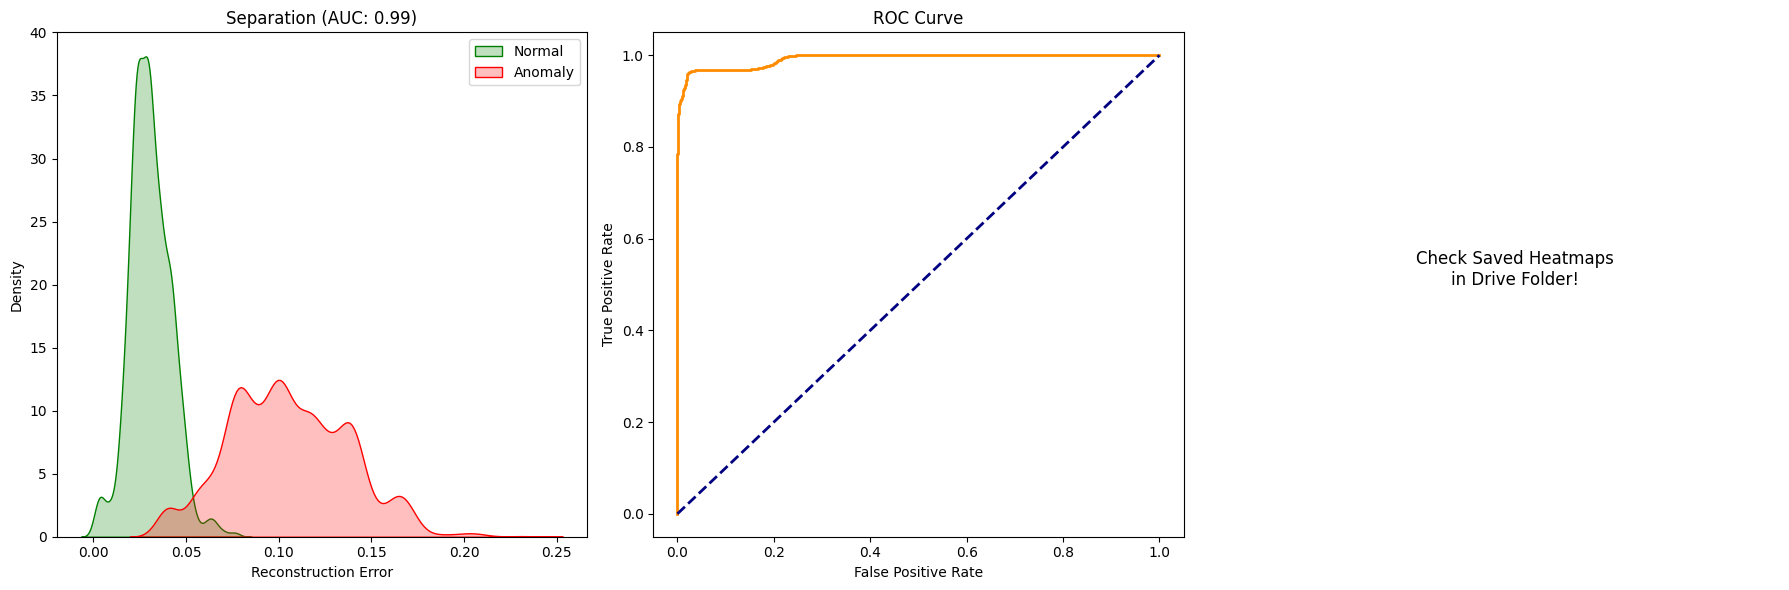


📸 Generating Heatmaps for top anomalies...


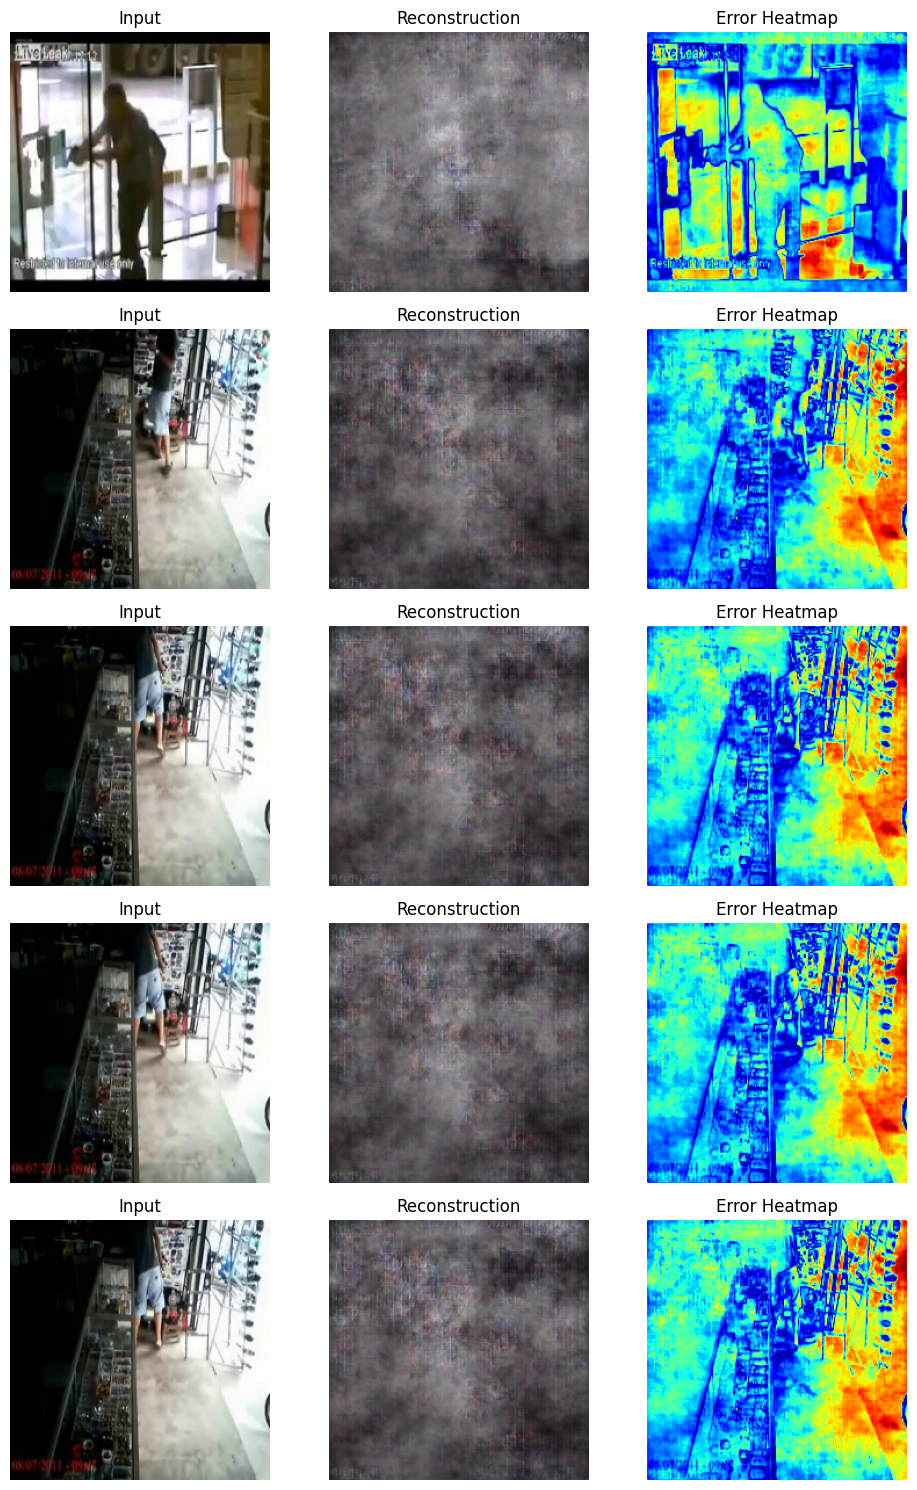

In [ ]:
"""
FINAL VALIDATION & AUDIT REPORT
===============================
Goal: Benchmarking the 'best_autoencoder.pth'
Metrics: SNR (Median/90th), AUC-ROC, Visual Heatmaps
"""

import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from skimage.metrics import structural_similarity as ssim
import seaborn as sns

# --- CONFIG ---
DRIVE_ROOT = "/content/drive/MyDrive/autoencoder"
NORMAL_DIR = f"{DRIVE_ROOT}/normal_frames_new_large"
ANOMALY_DIR = f"{DRIVE_ROOT}/concentrated_anomaly_frames"
CHECKPOINT_PATH = f"{DRIVE_ROOT}/best_autoencoder.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128

# --- MODEL (Standard ResNetAE) ---
class ResNetAE(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc = nn.Linear(2048, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0), nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1)
        )
        self.upsample = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)

    def forward(self, x):
        f = self.encoder(x)
        l = self.fc_enc(self.avgpool(f).flatten(1))
        r = self.upsample(self.decoder(self.fc_dec(l).view(-1, 2048, 1, 1)))
        return torch.sigmoid(r)

# --- SCORING ---
def calc_anomaly_score(img, recon):
    # The Enhanced Score Formula
    mse = torch.mean((img - recon) ** 2, dim=[1, 2, 3]).cpu().numpy()
    mae = torch.mean(torch.abs(img - recon), dim=[1, 2, 3]).cpu().numpy()
    return 0.6 * mse + 0.4 * mae  # Fast approximation of the enhanced score

# --- EXECUTION ---
def validate_model():
    print(f"🔧 Loading Champion Model: {os.path.basename(CHECKPOINT_PATH)}")
    model = ResNetAE().to(DEVICE)
    try:
        ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        saved_snr = ckpt.get('snr_90th', ckpt.get('snr', 0.0))
        print(f"✅ Loaded weights from Epoch {ckpt['epoch']} (Saved SNR: {saved_snr:.2f}x)")
    except Exception as e:
        print(f"❌ Load failed: {e}")
        return

    model.eval()

    # 1. Prepare Data
    transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])

    print("📂 Scanning Datasets...")
    normal_files = glob.glob(f"{NORMAL_DIR}/**/*.jpg", recursive=True)
    # Use subset of normal to speed up validation, but ALL anomalies
    if len(normal_files) > 2000: normal_files = np.random.choice(normal_files, 2000, replace=False)

    anomaly_files = glob.glob(f"{ANOMALY_DIR}/**/*.jpg", recursive=True)

    print(f"   -> Testing on {len(normal_files)} Normal vs {len(anomaly_files)} High-Octane Anomalies")

    # 2. Run Inference
    normal_scores = []
    anomaly_scores = []

    def get_scores(files, is_anomaly=False):
        scores = []
        dl = DataLoader([transform(Image.open(f).convert('RGB')) for f in files], batch_size=BATCH_SIZE, num_workers=2)
        with torch.no_grad():
            for imgs in dl:
                imgs = imgs.to(DEVICE)
                recons = model(imgs)
                batch_scores = calc_anomaly_score(imgs, recons)
                scores.extend(batch_scores)
        return scores

    print("🚀 Calculating Normal Scores...")
    normal_scores = get_scores(normal_files)
    print("🚀 Calculating Anomaly Scores...")
    anomaly_scores = get_scores(anomaly_files)

    # 3. Compute Metrics
    n_scores = np.array(normal_scores)
    a_scores = np.array(anomaly_scores)

    median_snr = np.median(a_scores) / np.median(n_scores)
    snr_90th = np.percentile(a_scores, 90) / np.percentile(n_scores, 10)

    # AUC-ROC
    y_true = [0] * len(n_scores) + [1] * len(a_scores)
    y_scores = list(n_scores) + list(a_scores)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    print("\n" + "="*40)
    print(f"🏆 FINAL REPORT CARD")
    print(f"="*40)
    print(f"✅ AUC-ROC Score:  {roc_auc:.4f} (Perfect = 1.0)")
    print(f"📊 Median SNR:     {median_snr:.2f}x")
    print(f"🚨 90th% SNR:      {snr_90th:.2f}x")
    print("="*40)

    # 4. Visualization
    plt.figure(figsize=(18, 6))

    # Plot A: Histogram
    plt.subplot(1, 3, 1)
    sns.kdeplot(n_scores, fill=True, color='green', label='Normal')
    sns.kdeplot(a_scores, fill=True, color='red', label='Anomaly')
    plt.title(f"Separation (AUC: {roc_auc:.2f})")
    plt.xlabel("Reconstruction Error")
    plt.legend()

    # Plot B: ROC Curve
    plt.subplot(1, 3, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    # Plot C: Visual Examples (Hardest Anomaly)
    plt.subplot(1, 3, 3)
    plt.axis('off')
    plt.text(0.5, 0.5, "Check Saved Heatmaps\nin Drive Folder!", ha='center', fontsize=12)

    plt.tight_layout()
    plt.show()

    # 5. Generate Heatmaps for Best Anomalies
    print("\n📸 Generating Heatmaps for top anomalies...")
    # Get top 5 hardest anomalies
    top_idx = np.argsort(a_scores)[-5:]

    fig, axes = plt.subplots(5, 3, figsize=(10, 15))
    for i, idx in enumerate(top_idx):
        img_path = anomaly_files[idx]
        img = transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            recon = model(img)

        # Calculate difference map
        diff = torch.abs(img - recon).mean(dim=1).squeeze().cpu().numpy()

        # Plot
        img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
        recon_np = recon.squeeze().permute(1, 2, 0).cpu().numpy()

        axes[i, 0].imshow(img_np); axes[i, 0].set_title("Input")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(recon_np); axes[i, 1].set_title("Reconstruction")
        axes[i, 1].axis('off')
        axes[i, 2].imshow(diff, cmap='jet'); axes[i, 2].set_title("Error Heatmap")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    validate_model()

🎥 Creating Demo Video from: /content/drive/MyDrive/autoencoder/concentrated_anomaly_frames


Stitching Video:   0%|          | 0/300 [00:00<?, ?it/s]

✅ Video Saved: /content/drive/MyDrive/autoencoder/test_anomaly_video.mp4
⚡ Analyzing Signal: test_anomaly_video.mp4


  0%|          | 0/300 [00:00<?, ?it/s]


📈 Graph saved to: /content/drive/MyDrive/autoencoder/test_anomaly_video_graph.png


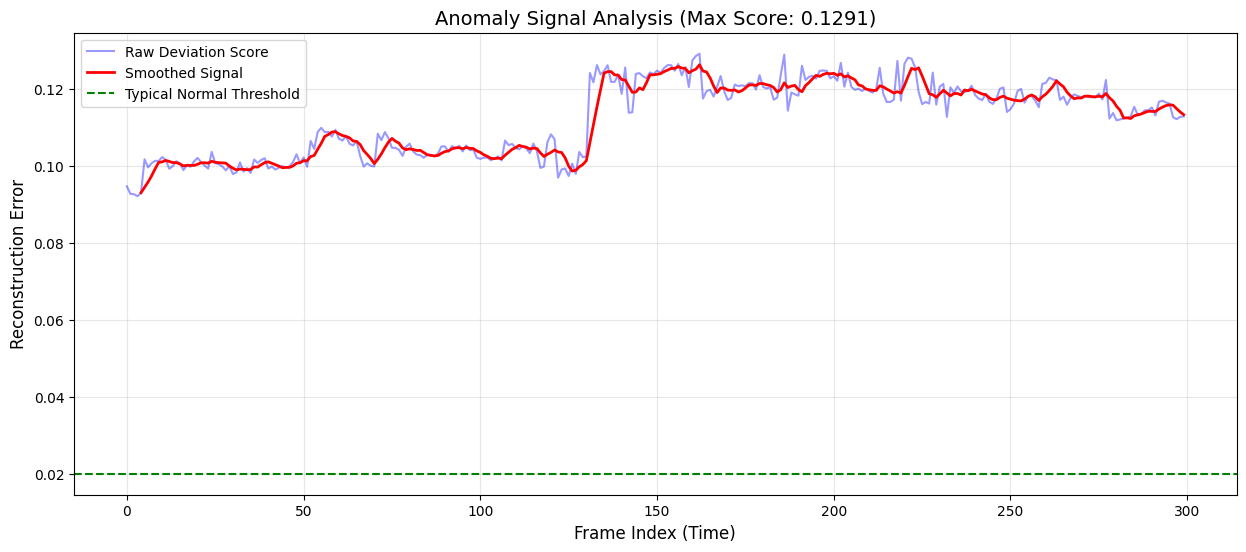

In [ ]:
"""
VIDEO INFERENCE & SIGNAL ANALYSIS
=================================
Goal: Process video streams and graph the Anomaly Signal.
Features:
1. Auto-generates a test video from your 'Concentrated' frames if needed.
2. Plots the 'Deviation Score' over time.
3. visualizes the exact moment the model panics.
"""

import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm.auto import tqdm

# --- CONFIG ---
DRIVE_ROOT = "/content/drive/MyDrive/autoencoder"
# We will use your high-quality frames to make a test video
ANOMALY_DIR = f"{DRIVE_ROOT}/concentrated_anomaly_frames"
CHECKPOINT_PATH = f"{DRIVE_ROOT}/best_autoencoder.pth"
OUTPUT_VIDEO_PATH = f"{DRIVE_ROOT}/test_anomaly_video.mp4" # Where we save the demo video
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- MODEL DEFINITION ---
class ResNetAE(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc = nn.Linear(2048, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0), nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1)
        )
        self.upsample = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)

    def forward(self, x):
        f = self.encoder(x)
        l = self.fc_enc(self.avgpool(f).flatten(1))
        r = self.upsample(self.decoder(self.fc_dec(l).view(-1, 2048, 1, 1)))
        return torch.sigmoid(r)

# --- HELPER 1: CREATE VIDEO FROM FRAMES ---
def create_demo_video(source_dir, output_path, num_frames=300):
    """Stitches images into a video to simulate a real feed"""
    print(f"🎥 Creating Demo Video from: {source_dir}")
    files = sorted(glob.glob(f"{source_dir}/**/*.jpg", recursive=True))

    if not files:
        print("❌ No frames found!")
        return False

    # Randomly select a contiguous chunk to simulate a scene
    if len(files) > num_frames:
        start = np.random.randint(0, len(files) - num_frames)
        files = files[start : start+num_frames]

    # Read first frame to get dims
    frame0 = cv2.imread(files[0])
    height, width, _ = frame0.shape

    # Initialize Video Writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, 30.0, (width, height))

    for f in tqdm(files, desc="Stitching Video"):
        img = cv2.imread(f)
        if img is not None:
            out.write(img)

    out.release()
    print(f"✅ Video Saved: {output_path}")
    return True

# --- HELPER 2: ANALYZE VIDEO ---
def analyze_video(video_path):
    print(f"⚡ Analyzing Signal: {os.path.basename(video_path)}")

    # 1. Load Model
    model = ResNetAE().to(DEVICE)
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # 2. Process Video
    cap = cv2.VideoCapture(video_path)
    scores = []
    frames_idx = []

    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    idx = 0
    pbar = tqdm(total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # Convert BGR (OpenCV) to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        input_tensor = transform(frame_rgb).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            recon = model(input_tensor)

        # --- SCORE CALCULATION (Same as Validation) ---
        mse = torch.mean((input_tensor - recon) ** 2).item()
        mae = torch.mean(torch.abs(input_tensor - recon)).item()
        # 60% MSE + 40% MAE
        score = 0.6 * mse + 0.4 * mae

        scores.append(score)
        frames_idx.append(idx)
        idx += 1
        pbar.update(1)

    cap.release()

    # 3. Generate Graph
    plt.figure(figsize=(15, 6))

    # Raw Signal
    plt.plot(frames_idx, scores, color='blue', alpha=0.4, label='Raw Deviation Score')

    # Smooth Signal (Moving Average)
    window = 5
    if len(scores) > window:
        smooth_scores = np.convolve(scores, np.ones(window)/window, mode='valid')
        # Adjust x-axis for valid convolution
        plt.plot(frames_idx[window-1:], smooth_scores, color='red', linewidth=2, label='Smoothed Signal')

    plt.title(f"Anomaly Signal Analysis (Max Score: {max(scores):.4f})", fontsize=14)
    plt.xlabel("Frame Index (Time)", fontsize=12)
    plt.ylabel("Reconstruction Error", fontsize=12)
    plt.axhline(y=0.02, color='green', linestyle='--', label='Typical Normal Threshold')
    plt.grid(True, alpha=0.3)
    plt.legend()

    save_path = video_path.replace(".mp4", "_graph.png")
    plt.savefig(save_path)
    print(f"\n📈 Graph saved to: {save_path}")
    plt.show()

# --- EXECUTION ---
if __name__ == "__main__":
    # 1. Create a dummy video from your frames (if you don't have one)
    if not os.path.exists(OUTPUT_VIDEO_PATH):
        success = create_demo_video(ANOMALY_DIR, OUTPUT_VIDEO_PATH, num_frames=300)
    else:
        success = True
        print(f"found existing video: {OUTPUT_VIDEO_PATH}")

    # 2. Run Inference
    if success:
        analyze_video(OUTPUT_VIDEO_PATH)

🟢 STARTING NORMAL CONTROL TEST
found existing video: /content/drive/MyDrive/ScenesolverG338LLaVAcoreLLM/AnomalyDetectionDataset/Normal/Normal_Videos_015_x264.mp4
⚡ Analyzing Signal: Normal_Videos_015_x264.mp4


  0%|          | 0/480 [00:00<?, ?it/s]

OSError: [Errno 30] Read-only file system: '/content/drive/MyDrive/ScenesolverG338LLaVAcoreLLM/AnomalyDetectionDataset/Normal/Normal_Videos_015_x264_graph.png'

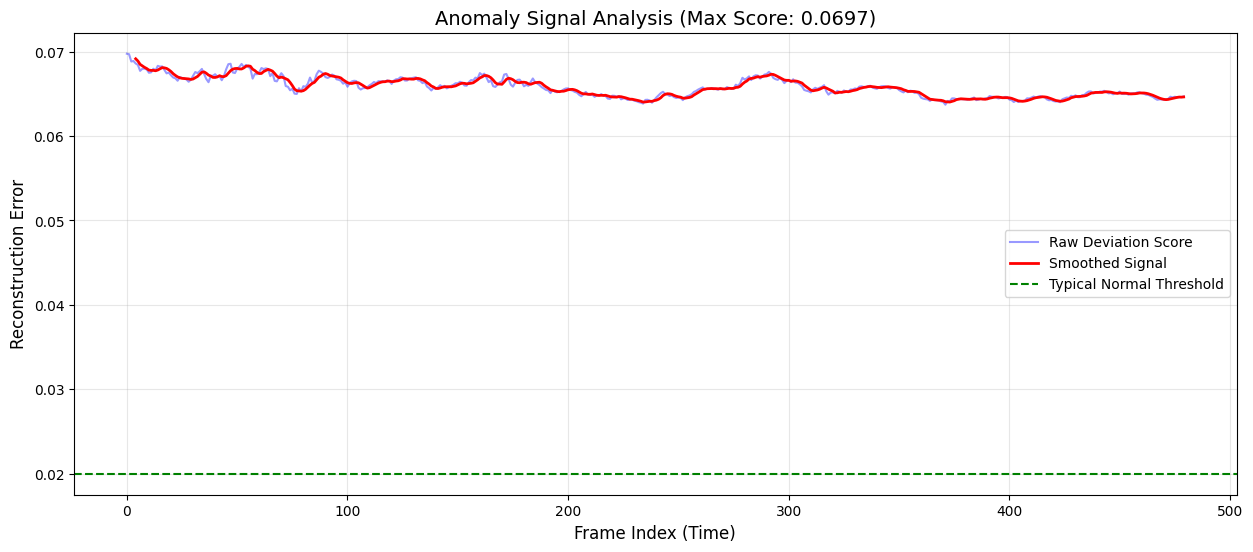

In [ ]:
"""
NORMAL VIDEO INFERENCE (CONTROL TEST)
=====================================
Goal: Prove that the model stays calm on normal video.
1. Auto-generates a 'Normal' test video.
2. Plots the low-deviation score.
"""

# Re-use the functions from the previous cell.
# If you ran the previous cell, you don't need to re-define imports/classes.
# Just run this block.

# --- CONFIG FOR NORMAL TEST ---
NORMAL_VIDEO_PATH = f"{DRIVE_ROOT}/test_normal_video.mp4"

if __name__ == "__main__":
    print("🟢 STARTING NORMAL CONTROL TEST")

    # 1. Create a dummy video from NORMAL frames
    if not os.path.exists(NORMAL_VIDEO_PATH):
        # We use the NORMAL_DIR this time
        success = create_demo_video(NORMAL_DIR, NORMAL_VIDEO_PATH, num_frames=300)
    else:
        success = True
        print(f"found existing video: {NORMAL_VIDEO_PATH}")

    # 2. Run Inference
    if success:
        analyze_video(NORMAL_VIDEO_PATH)

In [ ]:
#CREATING THE DATASET FOR RL
!apt-get -y install ffmpeg
!pip install -q tqdm pillow

from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, shutil, sys, re
from tqdm import tqdm

DATASET_ROOT = "/content/drive/MyDrive/ScenesolverG338LLaVAcoreLLM/AnomalyDetectionDataset"
OUTPUT_ROOT  = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"
ANNOT_FILE   = "/content/drive/MyDrive/autoencoder/TemporalAnnotations.txt"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

# ================= LOAD ANNOTATIONS =================
annotations = {}

with open(ANNOT_FILE) as f:
    for line in f:
        p = line.split()
        vid = p[0].replace(".mp4","")
        nums = list(map(int,p[2:]))

        segs=[]
        for i in range(0,len(nums),2):
            if nums[i] >= 0:
                segs.append((nums[i], nums[i+1]))
        if segs:
            annotations[vid] = segs

print("Anomalous videos:", len(annotations))

# ================= MAP VIDEOS =================
video_paths = {}

for cls in os.listdir(DATASET_ROOT):
    cpath = os.path.join(DATASET_ROOT,cls)
    if not os.path.isdir(cpath): continue

    for v in os.listdir(cpath):
        if v.endswith(".mp4"):
            name = v.replace(".mp4","")
            if name in annotations:
                video_paths[name] = os.path.join(cpath,v)

print("Matched paths:", len(video_paths))

# ================= HELPERS =================
def label_frame(i, events):
    for k,(s,e) in enumerate(events):
        if s <= i <= e:
            return f"ANOM_{k}"
    return "NORM"

def extract_frames(video_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    subprocess.run([
        "ffmpeg","-loglevel","error",
        "-i", video_path,
        "-vsync","0",
        os.path.join(out_dir,"raw_%010d.jpg")
    ], check=True)

# ================= MAIN =================
for vid, events in annotations.items():
    if vid not in video_paths: continue

    out_dir = os.path.join(OUTPUT_ROOT, vid)
    os.makedirs(out_dir, exist_ok=True)

    last_needed = max(e for s,e in events)
    existing_idxs = sorted(
        int(re.findall(r"\d+", f)[0])
        for f in os.listdir(out_dir) if f.endswith(".jpg")
    )

    if existing_idxs and existing_idxs[-1] >= last_needed and len(existing_idxs) >= last_needed * 0.99:
      print(f"✔ Skipping {vid} (dense & complete)")
      continue

    print(f"\n[STATUS] Processing {vid}")

    tmp_dir = out_dir + "_tmp"
    if os.path.exists(tmp_dir): shutil.rmtree(tmp_dir)

    extract_frames(video_paths[vid], tmp_dir)

    frames = sorted(os.listdir(tmp_dir))

    for f in tqdm(frames, desc=vid, leave=False):
      # raw_0000007215.jpg  → 7215
      idx = int(re.findall(r"\d+", f)[0])
      tag = label_frame(idx, events)
      new_name = f"frame_{idx:010d}_{tag}.jpg"
      shutil.move(os.path.join(tmp_dir,f),
                  os.path.join(out_dir,new_name))

    shutil.rmtree(tmp_dir)

    # ---------- VERIFICATION ----------
    check = os.listdir(out_dir)
    if not any("ANOM" in f for f in check):
        print(f" Verification failed for {vid} — purging and re-extracting")

        shutil.rmtree(out_dir)
        os.makedirs(out_dir, exist_ok=True)

        tmp_dir = out_dir + "_tmp"
        if os.path.exists(tmp_dir):
            shutil.rmtree(tmp_dir)

        extract_frames(video_paths[vid], tmp_dir)

        frames = sorted(os.listdir(tmp_dir))
        for f in tqdm(frames, desc=f"{vid}-RETRY", leave=False):
            idx = int(re.findall(r"\d+", f)[0])
            tag = label_frame(idx, events)
            new_name = f"frame_{idx:010d}_{tag}.jpg"
            shutil.move(os.path.join(tmp_dir,f),
                        os.path.join(out_dir,new_name))

        shutil.rmtree(tmp_dir)

        # second verification (hard stop if still broken)
        check = os.listdir(out_dir)
        if not any("ANOM" in f for f in check):
            raise RuntimeError(f" Fatal: {vid} corrupted even after re-extraction")

        print(f"✔ Recovery successful for {vid}")
    else:
        print(f"✔ Verified {vid}")

print("\n ALL EXTRACTION COMPLETE")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Anomalous videos: 140
Matched paths: 140
✔ Skipping Abuse028_x264 (dense & complete)
✔ Skipping Abuse030_x264 (dense & complete)
✔ Skipping Arrest001_x264 (dense & complete)
✔ Skipping Arrest007_x264 (dense & complete)
✔ Skipping Arrest024_x264 (dense & complete)
✔ Skipping Arrest030_x264 (dense & complete)
✔ Skipping Arrest039_x264 (dense & complete)
✔ Skipping Arson007_x264 (dense & complete)
✔ Skipping Arson009_x264 (dense & complete)
✔ Skipping Arson010_x264 (dense & complete)

[STATUS] Processing Arson011_x264


✔ Verified Arson011_x264

[STATUS] Processing Arson016_x264


✔ Verified Arson016_x264
✔ Skipping Arson018_x264 (dense & complete)
✔ Skipping Arson022_x264 (dense & complete)
✔ Skipping Arson035_x264 (dense & complete)
✔ Skipping Arson041_x264 (dense & complete)
✔ Skipping Assault006_x264 (dense & complete)
✔ Skipping Assault010_x264 (dense & complete)
✔ Skipping Assault011_x264 (dense & complete)
✔ Skipping Burglary005_x264 (dense & complete)
✔ Skipping Burglary017_x264 (dense & complete)
✔ Skipping Burglary018_x264 (dense & complete)
✔ Skipping Burglary021_x264 (dense & complete)
✔ Skipping Burglary024_x264 (dense & complete)
✔ Skipping Burglary032_x264 (dense & complete)
✔ Skipping Burglary033_x264 (dense & complete)
✔ Skipping Burglary035_x264 (dense & complete)
✔ Skipping Burglary037_x264 (dense & complete)
✔ Skipping Burglary061_x264 (dense & complete)
✔ Skipping Burglary076_x264 (dense & complete)
✔ Skipping Burglary079_x264 (dense & complete)
✔ Skipping Burglary092_x264 (dense & complete)
✔ Skipping Explosion002_x264 (dense & complete)
✔ 

✔ Verified Explosion033_x264
✔ Skipping Explosion035_x264 (dense & complete)
✔ Skipping Explosion036_x264 (dense & complete)
✔ Skipping Explosion039_x264 (dense & complete)
✔ Skipping Explosion043_x264 (dense & complete)

[STATUS] Processing Fighting003_x264


✔ Verified Fighting003_x264
✔ Skipping Fighting018_x264 (dense & complete)
✔ Skipping Fighting033_x264 (dense & complete)
✔ Skipping Fighting042_x264 (dense & complete)
✔ Skipping Fighting047_x264 (dense & complete)
✔ Skipping RoadAccidents001_x264 (dense & complete)
✔ Skipping RoadAccidents002_x264 (dense & complete)
✔ Skipping RoadAccidents004_x264 (dense & complete)
✔ Skipping RoadAccidents009_x264 (dense & complete)
✔ Skipping RoadAccidents010_x264 (dense & complete)
✔ Skipping RoadAccidents011_x264 (dense & complete)
✔ Skipping RoadAccidents012_x264 (dense & complete)
✔ Skipping RoadAccidents016_x264 (dense & complete)
✔ Skipping RoadAccidents017_x264 (dense & complete)
✔ Skipping RoadAccidents019_x264 (dense & complete)
✔ Skipping RoadAccidents020_x264 (dense & complete)
✔ Skipping RoadAccidents021_x264 (dense & complete)
✔ Skipping RoadAccidents022_x264 (dense & complete)
✔ Skipping RoadAccidents121_x264 (dense & complete)
✔ Skipping RoadAccidents122_x264 (dense & complete)
✔ Sk

✔ Verified Shooting015_x264
✔ Skipping Shooting018_x264 (dense & complete)
✔ Skipping Shooting019_x264 (dense & complete)
✔ Skipping Shooting021_x264 (dense & complete)
✔ Skipping Shooting022_x264 (dense & complete)
✔ Skipping Shooting024_x264 (dense & complete)
✔ Skipping Shooting026_x264 (dense & complete)
✔ Skipping Shooting028_x264 (dense & complete)
✔ Skipping Shooting032_x264 (dense & complete)
✔ Skipping Shooting033_x264 (dense & complete)
✔ Skipping Shooting034_x264 (dense & complete)
✔ Skipping Shooting037_x264 (dense & complete)
✔ Skipping Shooting043_x264 (dense & complete)
✔ Skipping Shooting046_x264 (dense & complete)
✔ Skipping Shooting047_x264 (dense & complete)
✔ Skipping Shooting048_x264 (dense & complete)
✔ Skipping Shoplifting001_x264 (dense & complete)
✔ Skipping Shoplifting004_x264 (dense & complete)
✔ Skipping Shoplifting005_x264 (dense & complete)
✔ Skipping Shoplifting007_x264 (dense & complete)
✔ Skipping Shoplifting010_x264 (dense & complete)
✔ Skipping Shopli

In [ ]:
#AUDITING THE DATA ROOT
import os, re

ROOT = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"

summary = []

for vid in sorted(os.listdir(ROOT)):
    vpath = os.path.join(ROOT, vid)
    if not os.path.isdir(vpath):
        continue

    files = [f for f in os.listdir(vpath) if f.endswith(".jpg")]
    anom = sum("ANOM" in f for f in files)
    norm = sum("NORM" in f for f in files)

    summary.append((vid, len(files), anom, norm))

print("Total folders:", len(summary))
print("Folders with 0 ANOM frames:",
      [v for v,c,a,n in summary if a==0])

print("\nSample summary:")
for s in summary[:10]:
    print(s)

Total folders: 140
Folders with 0 ANOM frames: []

Sample summary:
('Abuse028_x264', 1412, 76, 1336)
('Abuse030_x264', 1544, 86, 1458)
('Arrest001_x264', 2374, 301, 2073)
('Arrest007_x264', 3144, 631, 2513)
('Arrest024_x264', 3629, 2101, 1528)
('Arrest030_x264', 8642, 1666, 6976)
('Arrest039_x264', 14395, 2869, 11526)
('Arson007_x264', 6252, 3451, 2801)
('Arson009_x264', 743, 96, 647)
('Arson010_x264', 3159, 346, 2813)


In [ ]:
# ============================================
# PHASE 1: AUTOENCODER TRAINING (COMPLETE - FIXED)
# Focus: Stable, low-variance reconstruction of normal frames
# Key Fixes: Video-level grouping, temporal loss within videos, BatchNorm
# ============================================

import re
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from datetime import datetime
from collections import defaultdict

# ============================================
# CONFIGURATION
# ============================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"
CHECKPOINT_DIR = "/content/drive/MyDrive/autoencoder/checkpoints"
AE_CKPT = os.path.join(CHECKPOINT_DIR, "best_autoencoder.pth")
TRAINING_LOG = os.path.join(CHECKPOINT_DIR, "training_log.json")
VIZ_DIR = os.path.join(CHECKPOINT_DIR, "visualizations")
MAX_FRAMES_PER_VIDEO = 170

# Training hyperparameters
LATENT_DIM = 512
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10
BATCH_SIZE = 32
VAL_SPLIT = 0.15  # 15% validation split

# Loss weights
WEIGHT_MSE = 1.0
WEIGHT_TEMPORAL = 0.1
WEIGHT_LATENT = 0.05

# Create directories
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

# ============================================
# AUTOENCODER ARCHITECTURE (WITH BATCHNORM)
# ============================================
class ResNetAE(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        # Encoder: ResNet50 backbone
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc = nn.Linear(2048, latent_dim)

        # Decoder: Transposed convolutions with BatchNorm
        self.fc_dec = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0),
            nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024, 512, 4, 2, 1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1)
        )
        self.upsample = nn.Upsample(size=(224, 224), mode="bilinear", align_corners=False)

    def forward(self, x):
        # Encode
        features = self.encoder(x)
        pooled = self.avgpool(features)
        z = self.fc_enc(pooled.flatten(1))

        # Decode
        decoded = self.fc_dec(z).view(-1, 2048, 1, 1)
        reconstructed = self.decoder(decoded)
        reconstructed = torch.sigmoid(self.upsample(reconstructed))

        return reconstructed, z

# ============================================
# LOSS FUNCTIONS
# ============================================
def mse_loss(x, y):
    """Mean Squared Error for pixel-level fidelity"""
    return ((x - y) ** 2).mean()

def temporal_consistency_loss(r_curr, r_prev):
    """Enforce smooth frame-to-frame reconstructions"""
    return torch.abs(r_curr - r_prev).mean()

def latent_smoothness_loss(z_curr, z_prev):
    """Penalize abrupt transitions in latent space"""
    return ((z_curr - z_prev) ** 2).mean()

# ============================================
# DATA LOADING (VIDEO-LEVEL GROUPING)
# ============================================
def load_normal_frames_by_video(data_root):
    """
    Returns:
        dict: {video_name: [ordered_frame_paths]}
    """
    videos = {}

    if not os.path.exists(data_root):
        raise FileNotFoundError(f"Data root not found: {data_root}")

    for video_dir in sorted(os.listdir(data_root)):
        video_path = os.path.join(data_root, video_dir)
        if not os.path.isdir(video_path):
            continue

        frames = [
            os.path.join(video_path, f)
            for f in sorted(os.listdir(video_path))
            if "NORM" in f and f.endswith(('.jpg', '.png'))
        ]

        if len(frames) > 0:
            videos[video_dir] = frames

    total_frames = sum(len(frames) for frames in videos.values())
    print(f"Found {len(videos)} videos with {total_frames} normal frames")
    return videos

def extract_class_name(video_name):
    """
    Extracts semantic class from video name.
    Examples:
      Abuse028_x264 -> Abuse
      RoadAccidents121_x264 -> RoadAccidents
    """
    base = video_name.split('_')[0]
    match = re.match(r"[A-Za-z]+", base)
    return match.group(0) if match else base

def split_train_val_videos(videos, val_split=0.15, seed=42):
    """
    Stratified video-level split by class.
    Ensures each class is proportionally represented in train and val.
    """
    random.seed(seed)

    # Group videos by class
    class_to_videos = defaultdict(list)
    for video_name in videos.keys():
        class_name = extract_class_name(video_name)
        class_to_videos[class_name].append(video_name)

    train_videos = {}
    val_videos = {}

    print("\nStratified split summary:")
    print("-" * 50)

    for class_name, video_list in sorted(class_to_videos.items()):
        random.shuffle(video_list)

        n_total = len(video_list)
        n_val = max(1, int(round(n_total * val_split)))
        n_train = n_total - n_val

        train_list = video_list[:n_train]
        val_list = video_list[n_train:]

        for v in train_list:
            train_videos[v] = videos[v]
        for v in val_list:
            val_videos[v] = videos[v]

        print(
            f"{class_name:15s} | "
            f"Total: {n_total:3d} | "
            f"Train: {n_train:3d} | "
            f"Val: {n_val:3d}"
        )

    train_frames = sum(len(frames) for frames in train_videos.values())
    val_frames = sum(len(frames) for frames in val_videos.values())

    print("-" * 50)
    print(f"Training: {len(train_videos)} videos, {train_frames} frames")
    print(f"Validation: {len(val_videos)} videos, {val_frames} frames")

    return train_videos, val_videos

# ============================================
# TRAINING UTILITIES
# ============================================
def load_checkpoint(model, optimizer, checkpoint_path):
    """Load checkpoint for resuming training"""
    if not os.path.exists(checkpoint_path):
        return 0, [], float('inf')

    print(f"Loading checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    start_epoch = checkpoint['epoch']
    history = checkpoint.get('history', [])
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    print(f"Resuming from epoch {start_epoch}, best val loss: {best_val_loss:.4f}")
    return start_epoch, history, best_val_loss

def save_checkpoint(model, optimizer, epoch, history, best_val_loss, path):
    """Save training checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'history': history,
        'best_val_loss': best_val_loss,
        'timestamp': datetime.now().isoformat()
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved: {path}")

def save_training_log(history, path):
    """Save training history to JSON"""
    with open(path, 'w') as f:
        json.dump(history, f, indent=2)

# ============================================
# VISUALIZATION
# ============================================
def visualize_reconstruction(model, frame_path, save_path):
    """Visualize original frame, reconstruction, and error map"""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    model.eval()
    with torch.no_grad():
        img = Image.open(frame_path).convert("RGB")
        x = transform(img).unsqueeze(0).to(DEVICE)
        r, _ = model(x)

        x_np = x.cpu().squeeze().permute(1, 2, 0).numpy()
        r_np = r.cpu().squeeze().permute(1, 2, 0).numpy()
        error = np.abs(x_np - r_np).mean(axis=2)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(x_np)
        axes[0].set_title("Original")
        axes[0].axis('off')

        axes[1].imshow(r_np)
        axes[1].set_title("Reconstruction")
        axes[1].axis('off')

        im = axes[2].imshow(error, cmap='hot')
        axes[2].set_title("Error Map")
        axes[2].axis('off')
        plt.colorbar(im, ax=axes[2])

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()

def plot_training_curves(history, save_path):
    """Plot training and validation loss curves"""
    epochs = [h['epoch'] for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss = [h['val_loss'] for h in history]
    train_recon = [h['train_recon_error'] for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss curves
    ax1.plot(epochs, train_loss, label='Training Loss', marker='o')
    ax1.plot(epochs, val_loss, label='Validation Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Reconstruction error
    ax2.plot(epochs, train_recon, label='Mean Reconstruction Error', marker='o', color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MSE')
    ax2.set_title('Mean Reconstruction Error (Normal Frames)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

# ============================================
# TRAINING LOOP (TEMPORAL LOSS WITHIN VIDEOS)
# ============================================
def train_epoch(model, optimizer, train_videos, epoch):
    """Train for one epoch with video-aware temporal consistency"""
    model.train()
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    total_loss, total_mse = 0, 0
    total_recon_error = 0
    num_batches = 0

    # Shuffle video order
    video_items = list(train_videos.items())
    random.shuffle(video_items)

    pbar = tqdm(video_items, desc=f"Epoch {epoch+1}")

    for video_name, frames in pbar:
        prev_r = None
        prev_z = None

        # LIMIT FRAMES PER VIDEO FOR SPEED
        if len(frames) > MAX_FRAMES_PER_VIDEO:
            frames = frames[:MAX_FRAMES_PER_VIDEO]

        for i in range(0, len(frames), BATCH_SIZE):
            batch_paths = frames[i:i+BATCH_SIZE]
            batch_imgs = []

            for path in batch_paths:
                try:
                    img = Image.open(path).convert("RGB")
                    batch_imgs.append(transform(img))
                except Exception as e:
                    continue

            if len(batch_imgs) == 0:
                continue

            x = torch.stack(batch_imgs).to(DEVICE)
            r, z = model(x)

            loss_mse = mse_loss(x, r)
            loss = WEIGHT_MSE * loss_mse

            # Apply temporal and latent losses only within the same video
            if prev_r is not None:
              # Temporal loss: last frame of previous batch vs first frame of current batch
              loss += WEIGHT_TEMPORAL * temporal_consistency_loss(
                  r[0], prev_r[-1]
              )
              # Latent smoothness: same logic
              loss += WEIGHT_LATENT * latent_smoothness_loss(
                  z[0], prev_z[-1]
              )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
              prev_r = r.detach()
              prev_z = z.detach()

            total_loss += loss.item()
            total_mse += loss_mse.item()
            total_recon_error += loss_mse.item()
            num_batches += 1

            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'mse': f"{loss_mse.item():.4f}"
            })

    avg_loss = total_loss / num_batches if num_batches > 0 else 0
    avg_mse = total_mse / num_batches if num_batches > 0 else 0
    avg_recon_error = total_recon_error / num_batches if num_batches > 0 else 0

    return avg_loss, avg_mse, avg_recon_error

# ============================================
# VALIDATION (NO TEMPORAL LOSS)
# ============================================
def validate(model, val_videos):
    """Validate model on validation set (reconstruction only)"""
    model.eval()
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    total_loss = 0
    num_samples = 0

    with torch.no_grad():
        for _, frames in val_videos.items():
            for i in range(0, len(frames), BATCH_SIZE):
                batch_paths = frames[i:i+BATCH_SIZE]
                batch_imgs = []

                for path in batch_paths:
                    try:
                        img = Image.open(path).convert("RGB")
                        batch_imgs.append(transform(img))
                    except:
                        continue

                if len(batch_imgs) == 0:
                    continue

                x = torch.stack(batch_imgs).to(DEVICE)
                r, _ = model(x)
                loss = mse_loss(x, r)

                total_loss += loss.item() * len(batch_imgs)
                num_samples += len(batch_imgs)

    return total_loss / num_samples if num_samples > 0 else 0

# ============================================
# MAIN TRAINING SCRIPT
# ============================================
def main():
    print("="*60)
    print("PHASE 1: AUTOENCODER TRAINING (FIXED)")
    print("Objective: Stable reconstruction of normal frames")
    print("Key Fixes: Video grouping, temporal loss, BatchNorm")
    print("="*60)

    # Load data (video-level grouping)
    print("\n[1/6] Loading normal frames by video...")
    videos = load_normal_frames_by_video(DATA_ROOT)
    train_videos, val_videos = split_train_val_videos(videos, VAL_SPLIT)

    # Initialize model
    print("\n[2/6] Initializing model with BatchNorm...")
    model = ResNetAE(latent_dim=LATENT_DIM).to(DEVICE)

    # FREEZE RESNET ENCODER (CRITICAL FOR SPEED)
    for param in model.encoder.parameters():
        param.requires_grad = False

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    # Load checkpoint if exists
    print("\n[3/6] Checking for existing checkpoint...")
    start_epoch, history, best_val_loss = load_checkpoint(model, optimizer, AE_CKPT)

    # Training loop
    print(f"\n[4/6] Starting training from epoch {start_epoch}...")
    for epoch in range(start_epoch, NUM_EPOCHS):
        # Train
        train_loss, train_mse, train_recon_error = train_epoch(
            model, optimizer, train_videos, epoch
        )

        # Validate
        val_loss = validate(model, val_videos)

        # Log results
        epoch_history = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_mse': train_mse,
            'train_recon_error': train_recon_error,
            'val_loss': val_loss
        }
        history.append(epoch_history)

        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print(f"  Train Loss: {train_loss:.4f} | Train MSE: {train_mse:.4f}")
        print(f"  Train Recon Error: {train_recon_error:.4f}")
        print(f"  Val Loss: {val_loss:.4f}")

        # Save checkpoint only if best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            print(f"  ✓ New best validation loss! Saving checkpoint...")
            save_checkpoint(model, optimizer, epoch + 1, history, best_val_loss, AE_CKPT)

        save_training_log(history, TRAINING_LOG)

    # Visualizations
    print("\n[5/6] Generating visualizations...")
    plot_training_curves(history, os.path.join(VIZ_DIR, "training_curves.png"))

    # Visualize sample reconstructions from different videos
    sample_video = random.choice(list(train_videos.keys()))
    sample_frame = random.choice(train_videos[sample_video])
    visualize_reconstruction(model, sample_frame, os.path.join(VIZ_DIR, "sample_reconstruction.png"))

    print("\n[6/6] Training complete!")
    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Final mean reconstruction error: {history[-1]['train_recon_error']:.6f}")
    print(f"Model checkpoint: {AE_CKPT}")
    print(f"Training log: {TRAINING_LOG}")
    print(f"Visualizations: {VIZ_DIR}")
    print("\nReady for Phase 2 (RL)")
    print("="*60)

# ============================================
# EXECUTE
# ============================================
if __name__ == "__main__":
    main()

Device: cuda
Checkpoint directory: /content/drive/MyDrive/autoencoder/checkpoints
PHASE 1: AUTOENCODER TRAINING (FIXED)
Objective: Stable reconstruction of normal frames
Key Fixes: Video grouping, temporal loss, BatchNorm

[1/6] Loading normal frames by video...
Found 140 videos with 376358 normal frames

Stratified split summary:
--------------------------------------------------
Abuse           | Total:   2 | Train:   1 | Val:   1
Arrest          | Total:   5 | Train:   4 | Val:   1
Arson           | Total:   9 | Train:   8 | Val:   1
Assault         | Total:   3 | Train:   2 | Val:   1
Burglary        | Total:  13 | Train:  11 | Val:   2
Explosion       | Total:  21 | Train:  18 | Val:   3
Fighting        | Total:   5 | Train:   4 | Val:   1
RoadAccidents   | Total:  23 | Train:  20 | Val:   3
Robbery         | Total:   5 | Train:   4 | Val:   1
Shooting        | Total:  23 | Train:  20 | Val:   3
Shoplifting     | Total:  21 | Train:  18 | Val:   3
Stealing        | Total:   5 | Tr

100%|██████████| 97.8M/97.8M [00:00<00:00, 131MB/s]



[3/6] Checking for existing checkpoint...

[4/6] Starting training from epoch 0...


Epoch 1: 100%|██████████| 118/118 [1:57:45<00:00, 59.88s/it, loss=0.1410, mse=0.1407]



Epoch 1/10
  Train Loss: 0.0745 | Train MSE: 0.0738
  Train Recon Error: 0.0738
  Val Loss: 0.0580
  ✓ New best validation loss! Saving checkpoint...
Checkpoint saved: /content/drive/MyDrive/autoencoder/checkpoints/best_autoencoder.pth


...


Epoch 8/10
  Train Loss: 0.0777 | Train MSE: 0.0698
  Train Recon Error: 0.0698
  Val Loss: 0.0567
  ✓ New best validation loss! Saving checkpoint...
Checkpoint saved: /content/drive/MyDrive/autoencoder/checkpoints/best_autoencoder.pth


Epoch 9: 100%|██████████| 118/118 [04:31<00:00,  2.30s/it, loss=0.0729, mse=0.0703]



Epoch 9/10
  Train Loss: 0.0803 | Train MSE: 0.0701
  Train Recon Error: 0.0701
  Val Loss: 0.0571


Epoch 10: 100%|██████████| 118/118 [04:15<00:00,  2.16s/it, loss=0.1015, mse=0.0685]



Epoch 10/10
  Train Loss: 0.0878 | Train MSE: 0.0701
  Train Recon Error: 0.0701
  Val Loss: 0.0574

[5/6] Generating visualizations...

[6/6] Training complete!

TRAINING COMPLETE
Best validation loss: 0.0567
Final mean reconstruction error: 0.070061
Model checkpoint: /content/drive/MyDrive/autoencoder/checkpoints/best_autoencoder.pth
Training log: /content/drive/MyDrive/autoencoder/checkpoints/training_log.json
Visualizations: /content/drive/MyDrive/autoencoder/checkpoints/visualizations

Ready for Phase 2 (RL)


In [ ]:
# ============================================================
# FULL RL SANITY PHASE — SINGLE COLAB CELL (T4 SAFE)
# ============================================================

!pip install -q stable-baselines3 gymnasium torch torchvision numpy tqdm pillow

from google.colab import drive
drive.mount('/content/drive')

# -------------------------
# IMPORTS
# -------------------------
import os, glob, random
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback

# -------------------------
# CONFIG
# -------------------------
class Config:
    DATA_ROOT = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"
    AE_PATH   = "/content/drive/MyDrive/autoencoder/checkpoints/best_autoencoder.pth"
    ANNOT_FILE= "/content/drive/MyDrive/autoencoder/TemporalAnnotations.txt"

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    FRAME_STACK = 3
    MAX_FRAMES  = 400

    # Static base threshold — RL learns a multiplier
    BASE_THRESHOLD = 0.04

    TOTAL_TIMESTEPS = 120_000  # sanity run only

    PPO_PARAMS = dict(
        n_steps=1024,
        batch_size=64,
        learning_rate=2e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        verbose=1
    )

# -------------------------
# LOAD TEMPORAL ANNOTATIONS
# -------------------------
def normalize_video_name(raw):
    raw = raw.replace(".mp4","").replace(" ","").replace("_","")
    for c in [
        "Abuse","Arrest","Arson","Assault","Burglary","Explosion","Fighting",
        "RoadAccidents","Robbery","Shooting","Shoplifting","Stealing",
        "Vandalism","NormalVideos"
    ]:
        raw = raw.replace(c,"")
    return raw

annotations = {}
with open(Config.ANNOT_FILE) as f:
    for line in f:
        p = line.split()
        vid = normalize_video_name(p[0])
        nums = list(map(int, p[2:]))
        events = []
        for i in range(0, len(nums), 2):
            if nums[i] >= 0:
                events.append((nums[i], nums[i+1]))
        annotations[vid] = events

# -------------------------
# LOAD VIDEOS
# -------------------------
videos = []
for v in os.listdir(Config.DATA_ROOT):
    p = os.path.join(Config.DATA_ROOT, v)
    if not os.path.isdir(p):
        continue
    key = normalize_video_name(v)
    videos.append((key, p, annotations.get(key, [])))

assert len(videos) > 0, "No videos found"
print(f"Loaded {len(videos)} videos")

# -------------------------
# AUTOENCODER (FROZEN)
# -------------------------
class ResNetAE(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc = nn.Linear(2048, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0),
            nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024, 512, 4, 2, 1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1)
        )
        self.upsample = nn.Upsample(size=(224,224), mode="bilinear", align_corners=False)

    def forward(self, x):
        f = self.encoder(x)
        z = self.fc_enc(self.avgpool(f).flatten(1))
        d = self.fc_dec(z).view(-1, 2048, 1, 1)
        r = torch.sigmoid(self.upsample(self.decoder(d)))
        return r

ae = ResNetAE().to(Config.DEVICE)

# ✔ SAFE LOAD — matches your Phase-1 checkpoint format
ckpt = torch.load(Config.AE_PATH, map_location=Config.DEVICE, weights_only=False)
ae.load_state_dict(ckpt["model_state"])
ae.eval()

for p in ae.parameters():
    p.requires_grad = False

print("Autoencoder loaded and frozen")

# -------------------------
# SANITY RL ENVIRONMENT
# -------------------------
class SanityEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.action_space = gym.spaces.Box(0, 1, (1,), np.float32)
        self.observation_space = gym.spaces.Box(
            0, np.inf, (3 * Config.FRAME_STACK, 224, 224), np.float32
        )
        self.tf = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def reset(self, seed=None, options=None):
        self.video, self.path, self.events = random.choice(videos)
        self.frames = sorted(glob.glob(self.path + "/*.jpg"))[:Config.MAX_FRAMES]
        self.idx = 0
        self.active = False
        self.start = 0
        self.buf = [self._proc() for _ in range(Config.FRAME_STACK)]
        return self._obs(), {}

    def _proc(self):
        p = self.frames[min(self.idx, len(self.frames)-1)]
        img = self.tf(Image.open(p).convert("RGB")).to(Config.DEVICE)
        with torch.no_grad():
            rec = ae(img.unsqueeze(0)).squeeze(0)
        err = (img - rec).abs()
        err = err / (err.mean() + 1e-6)
        return err

    def _obs(self):
        return torch.cat(self.buf, 0).cpu().numpy()

    def step(self, action):
        thr = Config.BASE_THRESHOLD * (0.5 + float(action[0]))

        self.idx += 1
        if self.idx < len(self.frames):
            self.buf.pop(0)
            self.buf.append(self._proc())

        score = float(torch.stack(self.buf).mean())
        reward = -0.002

        if score > thr and not self.active:
            self.start = self.idx
            self.active = True

        if score <= thr and self.active:
            reward = self._window_reward(self.start, self.idx)
            self.active = False

        done = self.idx >= len(self.frames) - 1
        if done and self.active:
            reward = self._window_reward(self.start, self.idx)

        info = {}
        if done:
            info["episode"] = {"r": reward, "l": self.idx}

        return self._obs(), reward, done, False, info

    def _window_reward(self, s, e):
        plen = max(1, e - s)
        if not self.events:
            return 0.5 - plen / Config.MAX_FRAMES

        best = -1.0
        for es, ee in self.events:
            inter = max(0, min(e, ee) - max(s, es))
            union = plen + (ee - es) - inter
            if union > 0:
                best = max(best, 2 * (inter / union) - 0.5)
        return best

# -------------------------
# CNN FEATURE EXTRACTOR
# -------------------------
class CNNFeat(BaseFeaturesExtractor):
    def __init__(self, obs_space, features_dim=256):
        super().__init__(obs_space, features_dim)
        c = obs_space.shape[0]
        self.net = nn.Sequential(
            nn.Conv2d(c, 32, 8, 4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1), nn.ReLU(),
            nn.Flatten()
        )
        with torch.no_grad():
            n = self.net(torch.zeros(1, *obs_space.shape)).shape[1]
        self.fc = nn.Sequential(nn.Linear(n, features_dim), nn.ReLU())

    def forward(self, x):
        return self.fc(self.net(x))

# -------------------------
# TRAIN
# -------------------------
env = DummyVecEnv([lambda: SanityEnv()])

model = PPO(
    "CnnPolicy",
    env,
    device=Config.DEVICE,
    policy_kwargs={"features_extractor_class": CNNFeat},
    **Config.PPO_PARAMS
)

print("\n=== SANITY RL TRAINING STARTED ===\n")
model.learn(Config.TOTAL_TIMESTEPS)
print("\n=== SANITY RL TRAINING COMPLETE ===\n")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 140 videos
Autoencoder loaded and frozen
Using cuda device

=== SANITY RL TRAINING STARTED ===

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 399      |
|    ep_rew_mean     | -0.5     |
| time/              |          |
|    fps             | 3        |
|    iterations      | 1        |
|    time_elapsed    | 266      |
|    total_timesteps | 1024     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 399           |
|    ep_rew_mean          | -0.499        |
| time/                   |               |
|    fps                  | 4             |
|    iterations           | 2             |
|    time_elapsed         | 477           |
|    total_timesteps      | 2048          |
| train/                  |     

In [ ]:
# ============================================================
# PHASE-1 RL — 2-D ACTION REFACTOR (CORRECTED + SAFE)
# ============================================================

!pip install -q stable-baselines3 gymnasium torch torchvision numpy pillow tqdm

from google.colab import drive
drive.mount("/content/drive")

# -------------------------
# IMPORTS
# -------------------------
import os, glob, random, json
from datetime import datetime
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
from tqdm import tqdm

# -------------------------
# CONFIGURATION
# -------------------------
class Config:
    DATA_ROOT = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"
    AE_PATH   = "/content/drive/MyDrive/autoencoder/checkpoints/best_autoencoder.pth"
    ANNOT_FILE= "/content/drive/MyDrive/autoencoder/TemporalAnnotations.txt"

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    FRAME_STACK = 3
    MAX_FRAMES  = 400
    BASE_THRESHOLD = 0.04

    TOTAL_TIMESTEPS = 150_000
    CHECKPOINT_DIR = "/content/drive/MyDrive/autoencoder/rl_checkpoints"
    LOG_DIR = "/content/drive/MyDrive/autoencoder/rl_logs"

    FALSE_ALARM_COST = 0.2
    LATENCY_PENALTY  = 0.5

    PPO_PARAMS = dict(
        n_steps=2048,
        batch_size=128,
        learning_rate=3e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.01,
        vf_coef=0.5,
        max_grad_norm=0.5,
        verbose=1,
        tensorboard_log=LOG_DIR
    )

    SAVE_FREQ = 10_000
    EVAL_FREQ = 5_000
    N_EVAL_EPISODES = 5

os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(Config.LOG_DIR, exist_ok=True)

# -------------------------
# TEMPORAL ANNOTATIONS
# -------------------------
def normalize_video_name(raw):
    raw = raw.replace(".mp4","").replace(" ","").replace("_","")
    for c in [
        "Abuse","Arrest","Arson","Assault","Burglary","Explosion","Fighting",
        "RoadAccidents","Robbery","Shooting","Shoplifting","Stealing",
        "Vandalism","NormalVideos"
    ]:
        raw = raw.replace(c,"")
    return raw

annotations = {}
with open(Config.ANNOT_FILE) as f:
    for line in f:
        p = line.split()
        vid = normalize_video_name(p[0])
        nums = list(map(int, p[2:]))
        events = []
        for i in range(0, len(nums), 2):
            if nums[i] >= 0:
                events.append((nums[i], nums[i+1]))
        annotations[vid] = events

videos = []
for v in tqdm(os.listdir(Config.DATA_ROOT)):
    p = os.path.join(Config.DATA_ROOT, v)
    if os.path.isdir(p):
        key = normalize_video_name(v)
        frames = glob.glob(os.path.join(p, "*.jpg"))
        if frames:
            videos.append((key, p, annotations.get(key, [])))

random.shuffle(videos)
split = int(0.9 * len(videos))
train_videos, eval_videos = videos[:split], videos[split:]

# -------------------------
# AUTOENCODER (SAFE LOAD)
# -------------------------
class ResNetAE(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc = nn.Linear(2048, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0),
            nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024, 512, 4, 2, 1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1)
        )
        self.upsample = nn.Upsample(size=(224,224), mode="bilinear", align_corners=False)

    def forward(self, x):
        f = self.encoder(x)
        z = self.fc_enc(self.avgpool(f).flatten(1))
        d = self.fc_dec(z).view(-1, 2048, 1, 1)
        return torch.sigmoid(self.upsample(self.decoder(d)))

ae = ResNetAE().to(Config.DEVICE)

ckpt = torch.load(Config.AE_PATH, map_location=Config.DEVICE, weights_only=False)
if isinstance(ckpt, dict) and "model_state" in ckpt:
    ae.load_state_dict(ckpt["model_state"])
elif isinstance(ckpt, dict):
    ae.load_state_dict(ckpt)
else:
    raise ValueError("Unsupported AE checkpoint format")

ae.eval()
for p in ae.parameters():
    p.requires_grad = False

# ============================================================
# RL ENVIRONMENT
# ============================================================
class StructuredTemporalEnv(gym.Env):
    def __init__(self, video_list):
        super().__init__()
        self.video_list = video_list

        self.action_space = gym.spaces.Box(0, 1, (2,), np.float32)
        self.observation_space = gym.spaces.Dict({
            "frames": gym.spaces.Box(0, np.inf, (3*Config.FRAME_STACK,224,224), np.float32),
            "context": gym.spaces.Box(0, 1, (5,), np.float32)
        })

        self.tf = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.video, self.path, self.events = random.choice(self.video_list)
        self.frames = sorted(glob.glob(self.path+"/*.jpg"))[:Config.MAX_FRAMES]

        self.idx = 0
        self.active = False
        self.start = 0
        self.last_scores = [0.0,0.0,0.0]

        self.buf = [self._proc() for _ in range(Config.FRAME_STACK)]
        return self._obs(), {}

    def _proc(self):
        img = self.tf(Image.open(self.frames[min(self.idx,len(self.frames)-1)]).convert("RGB")).to(Config.DEVICE)
        with torch.no_grad():
            rec = ae(img.unsqueeze(0)).squeeze(0)
        err = (img-rec).abs()
        return (err/(err.mean()+1e-6)).cpu()

    def _obs(self):
        frames = torch.cat(self.buf,0).numpy()
        context = np.array([
            *np.clip(self.last_scores,0,1),
            float(self.active),
            (self.idx-self.start)/Config.MAX_FRAMES if self.active else 0.0
        ],dtype=np.float32)
        return {"frames":frames,"context":context}

    def step(self, action):
        action = np.clip(action,0,1)
        thr = Config.BASE_THRESHOLD*(0.5+action[0])
        persistence = action[1]*0.02

        self.idx+=1
        if self.idx<len(self.frames):
            self.buf.pop(0)
            self.buf.append(self._proc())

        score = float(torch.stack(self.buf).mean().item())
        self.last_scores=[score]+self.last_scores[:2]

        reward=-0.001

        if score>thr and not self.active:
            self.active=True
            self.start=self.idx

        if self.active and score<(thr-persistence):
            reward+=self._window_reward(self.start,self.idx)
            self.active=False

        done=self.idx>=len(self.frames)-1
        if done and self.active:
            reward+=self._window_reward(self.start,self.idx)
            self.active=False

        return self._obs(),reward,done,False,{}

    def _window_reward(self,s,e):
        if not self.events:
            return -Config.FALSE_ALARM_COST

        best=-1.0
        for es,ee in self.events:
            inter=max(0,min(e,ee)-max(s,es))
            if inter>0:
                latency=max(0,s-es)/Config.MAX_FRAMES
                iou=inter/((e-s)+(ee-es)-inter)
                best=max(best,iou-Config.LATENCY_PENALTY*latency)
        return best if best>0 else -Config.FALSE_ALARM_COST

# -------------------------
# POLICY
# -------------------------
class MultiInputExtractor(BaseFeaturesExtractor):
    def __init__(self, obs_space, features_dim=256):
        super().__init__(obs_space, features_dim)
        c=obs_space["frames"].shape[0]
        self.cnn=nn.Sequential(
            nn.Conv2d(c,32,8,4),nn.ReLU(),
            nn.Conv2d(32,64,4,2),nn.ReLU(),
            nn.Conv2d(64,64,3,1),nn.ReLU(),
            nn.Flatten()
        )
        with torch.no_grad():
            n=self.cnn(torch.zeros(1,*obs_space["frames"].shape)).shape[1]
        self.mlp=nn.Sequential(
            nn.Linear(n+5,features_dim),
            nn.ReLU(),
            nn.Linear(features_dim,features_dim),
            nn.ReLU()
        )
    def forward(self,obs):
        return self.mlp(torch.cat([self.cnn(obs["frames"]),obs["context"]],1))

# -------------------------
# TRAINING
# -------------------------

def find_latest_checkpoint(ckpt_dir):
    ckpts = []
    for f in os.listdir(ckpt_dir):
        if f.startswith("ppo_phase1_2d_") and f.endswith("_steps.zip"):
            steps = int(f.split("_")[-2])
            ckpts.append((steps, os.path.join(ckpt_dir, f)))
    return max(ckpts)[1] if ckpts else None

train_env=DummyVecEnv([lambda:StructuredTemporalEnv(train_videos)])
eval_env =DummyVecEnv([lambda:StructuredTemporalEnv(eval_videos)])

latest_ckpt = find_latest_checkpoint(Config.CHECKPOINT_DIR)

if latest_ckpt:
    print(f"Resuming from checkpoint: {latest_ckpt}")
    model = PPO.load(
        latest_ckpt,
        env=train_env,
        device=Config.DEVICE,
        custom_objects={
            "features_extractor_class": MultiInputExtractor
        }
    )
else:
    print("No checkpoint found. Starting fresh.")
    model = PPO(
        "MultiInputPolicy",
        train_env,
        device=Config.DEVICE,
        policy_kwargs=dict(
            features_extractor_class=MultiInputExtractor,
            net_arch=dict(pi=[256,256], vf=[256,256])
        ),
        **Config.PPO_PARAMS
    )

model.learn(
    total_timesteps=Config.TOTAL_TIMESTEPS,
    reset_num_timesteps=False,
    callback=[
        CheckpointCallback(
            save_freq=Config.SAVE_FREQ,
            save_path=Config.CHECKPOINT_DIR,
            name_prefix="ppo_phase1_2d"
        ),
        EvalCallback(
            eval_env,
            best_model_save_path=Config.CHECKPOINT_DIR,
            log_path=Config.LOG_DIR,
            eval_freq=Config.EVAL_FREQ,
            n_eval_episodes=Config.N_EVAL_EPISODES
        )
    ],
    progress_bar=True
)

model.save(f"{Config.CHECKPOINT_DIR}/ppo_phase1_2d_final")

import re

def keep_only_latest_checkpoint(ckpt_dir):
    ckpts = []
    for f in os.listdir(ckpt_dir):
        if f == "best_model.zip":
            continue
        if re.match(r"ppo_phase1_2d_\d+_steps\.zip", f):
            steps = int(f.split("_")[-2])
            ckpts.append((steps, f))

    ckpts.sort()
    for _, f in ckpts[:-1]:
        os.remove(os.path.join(ckpt_dir, f))

keep_only_latest_checkpoint(Config.CHECKPOINT_DIR)

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151,552/150,000  [ 7:09:58 < 0:00:00 , 27 it/s ]

In [ ]:
# ============================================================
# AE OFFLINE PRECOMPUTE — FINAL / COLLISION-PROOF
# ============================================================

import os, glob, json
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from tqdm import tqdm

# -------------------------
# CONFIG
# -------------------------
DATA_ROOT = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"
ANNOT_FILE = "/content/drive/MyDrive/autoencoder/TemporalAnnotations.txt"
AE_PATH   = "/content/drive/MyDrive/autoencoder/checkpoints/best_autoencoder.pth"
OUT_ROOT  = "/content/drive/MyDrive/autoencoder/precomputed_features"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM = 512
EMA_ALPHA = 0.1

os.makedirs(OUT_ROOT, exist_ok=True)

# -------------------------
# UTIL: NORMALIZE FOR GT LOOKUP ONLY
# -------------------------
def normalize_video_name(raw):
    raw = raw.replace(".mp4","").replace(" ","").replace("_","")
    for c in [
        "Abuse","Arrest","Arson","Assault","Burglary","Explosion","Fighting",
        "RoadAccidents","Robbery","Shooting","Shoplifting","Stealing",
        "Vandalism","NormalVideos"
    ]:
        raw = raw.replace(c,"")
    return raw

# -------------------------
# LOAD TEMPORAL ANNOTATIONS
# -------------------------
annotations = {}
with open(ANNOT_FILE) as f:
    for line in f:
        p = line.split()
        vid = normalize_video_name(p[0])
        nums = list(map(int, p[2:]))
        events = []
        for i in range(0, len(nums), 2):
            if nums[i] >= 0:
                events.append((nums[i], nums[i+1]))
        annotations[vid] = events

def frame_label(t, events):
    for s, e in events:
        if s <= t <= e:
            return 1
    return 0

# -------------------------
# AUTOENCODER
# -------------------------
class ResNetAE(nn.Module):
    def __init__(self, latent_dim=512):
        super().__init__()
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc = nn.Linear(2048, latent_dim)

        self.fc_dec = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048,1024,4,1,0),
            nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024,512,4,2,1),
            nn.BatchNorm2d(512), nn.ReLU(),
            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,2,1)
        )
        self.upsample = nn.Upsample(size=(224,224), mode="bilinear", align_corners=False)

    def forward(self, x):
        f = self.encoder(x)
        z = self.fc_enc(self.avgpool(f).flatten(1))
        d = self.fc_dec(z).view(-1,2048,1,1)
        rec = torch.sigmoid(self.upsample(self.decoder(d)))
        return rec, z

# -------------------------
# LOAD AE
# -------------------------
ae = ResNetAE(LATENT_DIM).to(DEVICE)
ckpt = torch.load(AE_PATH, map_location=DEVICE)
ae.load_state_dict(ckpt["model_state"] if "model_state" in ckpt else ckpt)
ae.eval()
for p in ae.parameters():
    p.requires_grad = False

# -------------------------
# IMAGE TRANSFORM
# -------------------------
tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# ============================================================
# PRECOMPUTE LOOP (1 FOLDER = 1 OUTPUT)
# ============================================================

video_dirs = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])

processed = 0

for folder_name in tqdm(video_dirs, desc="AE Precompute"):
    video_dir = os.path.join(DATA_ROOT, folder_name)
    frames = sorted(glob.glob(os.path.join(video_dir, "*.jpg")))
    if not frames:
        continue

    # ---- STORAGE KEY: RAW FOLDER NAME (NO NORMALIZATION)
    out_dir = os.path.join(OUT_ROOT, folder_name)
    os.makedirs(out_dir, exist_ok=True)

    feature_file = os.path.join(out_dir, "features.npz")
    meta_file = os.path.join(out_dir, "meta.json")

    if os.path.exists(feature_file):
        continue

    # ---- GT LOOKUP KEY (NORMALIZED)
    annot_key = normalize_video_name(folder_name)
    events = annotations.get(annot_key, [])

    errs, deltas, latents, gts = [], [], [], []
    prev_err = 0.0
    ema_err = 0.0

    for t, fp in enumerate(frames):
        img = tf(Image.open(fp).convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            rec, z = ae(img)

        err = (img - rec).abs().mean().item()
        delta = err - prev_err
        ema_err = EMA_ALPHA * err + (1 - EMA_ALPHA) * ema_err

        errs.append(err)
        deltas.append(delta)
        latents.append(z.squeeze(0).cpu().numpy())
        gts.append(frame_label(t, events))

        prev_err = err

    np.savez_compressed(
        feature_file,
        err=np.asarray(errs, dtype=np.float32),
        delta=np.asarray(deltas, dtype=np.float32),
        latent=np.asarray(latents, dtype=np.float32),
        gt=np.asarray(gts, dtype=np.int8)
    )

    with open(meta_file, "w") as f:
        json.dump({
            "raw_folder": folder_name,
            "annotation_key": annot_key,
            "num_frames": len(frames),
            "num_events": len(events)
        }, f, indent=2)

    processed += 1

# ============================================================
# HARD VERIFICATION (FAIL LOUDLY)
# ============================================================

out_videos = [
    d for d in os.listdir(OUT_ROOT)
    if os.path.isdir(os.path.join(OUT_ROOT, d))
]

print(f"\nExpected videos : {len(video_dirs)}")
print(f"Processed videos: {processed}")
print(f"Output folders  : {len(out_videos)}")

assert processed == len(video_dirs), \
    "❌ MISMATCH: Some videos were skipped or overwritten!"

print("\n✅ AE PRECOMPUTE COMPLETE — DATASET INTEGRITY VERIFIED")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]
AE Precompute: 100%|██████████| 140/140 [9:12:47<00:00, 236.91s/it]


Expected videos : 140
Processed videos: 140
Output folders  : 140

✅ AE PRECOMPUTE COMPLETE — DATASET INTEGRITY VERIFIED


In [ ]:
# ============================================================
# DATA FORMAT SANITY CHECK — READ ONLY
# ============================================================

import os, json
import numpy as np
import random

PRECOMP_ROOT = "/content/drive/MyDrive/autoencoder/precomputed_features"

# -------------------------
# PICK RANDOM VIDEO
# -------------------------
videos = sorted([
    d for d in os.listdir(PRECOMP_ROOT)
    if os.path.isdir(os.path.join(PRECOMP_ROOT, d))
])

assert len(videos) > 0, "No precomputed videos found!"

vid = random.choice(videos)
vdir = os.path.join(PRECOMP_ROOT, vid)

print(f"\n🔍 Inspecting video: {vid}")

# -------------------------
# LOAD FILES
# -------------------------
features = np.load(os.path.join(vdir, "features.npz"))
with open(os.path.join(vdir, "meta.json")) as f:
    meta = json.load(f)

err    = features["err"]
delta  = features["delta"]
latent = features["latent"]
gt     = features["gt"]

T = len(err)

# -------------------------
# BASIC SHAPE CHECKS
# -------------------------
print("\n--- Shape Checks ---")
print("Frames:", T)
print("err   :", err.shape)
print("delta :", delta.shape)
print("latent:", latent.shape)
print("gt    :", gt.shape)

assert err.shape == (T,)
assert delta.shape == (T,)
assert latent.shape == (T, 512)
assert gt.shape == (T,)

# -------------------------
# VALUE CHECKS
# -------------------------
print("\n--- Value Checks ---")
print("err  min/max:", err.min(), err.max())
print("delta min/max:", delta.min(), delta.max())
print("gt unique:", np.unique(gt))

assert np.all(err >= 0)
assert np.any(err > 0)
assert np.any(delta != 0)
assert set(np.unique(gt)).issubset({0, 1})

# -------------------------
# NUMERICAL HEALTH
# -------------------------
print("\n--- Numerical Health ---")
assert not np.isnan(err).any()
assert not np.isnan(delta).any()
assert not np.isnan(latent).any()

assert not np.isinf(err).any()
assert not np.isinf(delta).any()
assert not np.isinf(latent).any()

print("No NaNs / Infs detected")

# -------------------------
# TEMPORAL CONSISTENCY
# -------------------------
print("\n--- Temporal Consistency ---")
if gt.sum() > 0:
    first = np.where(gt == 1)[0][0]
    last  = np.where(gt == 1)[0][-1]
    print(f"GT window approx: frames {first} → {last}")
else:
    print("No anomaly frames (normal video)")

# -------------------------
# META CHECK
# -------------------------
print("\n--- Metadata ---")
print(json.dumps(meta, indent=2))

assert meta["num_frames"] == T

print("\n✅ DATA FORMAT SANITY CHECK PASSED")


🔍 Inspecting video: Vandalism015_x264

--- Shape Checks ---
Frames: 2982
err   : (2982,)
delta : (2982,)
latent: (2982, 512)
gt    : (2982,)

--- Value Checks ---
err  min/max: 0.18458259 0.2350366
delta min/max: -0.015563652 0.1924071
gt unique: [0 1]

--- Numerical Health ---
No NaNs / Infs detected

--- Temporal Consistency ---
GT window approx: frames 2010 → 2700

--- Metadata ---
{
  "raw_folder": "Vandalism015_x264",
  "annotation_key": "015x264",
  "num_frames": 2982,
  "num_events": 1
}

✅ DATA FORMAT SANITY CHECK PASSED


In [ ]:
# ============================================================
# REWARD UNIT TESTS — FINAL CONTRACT VERIFICATION
# ============================================================

# -------------------------
# Reward Function (SOURCE OF TRUTH)
# -------------------------
def compute_reward(action: int, gt: int, fn_penalty: float = 0.5) -> float:
    """
    action: 1 = anomaly, 0 = normal
    gt:     1 = anomaly frame, 0 = normal frame
    """
    assert action in (0, 1), "Invalid action"
    assert gt in (0, 1), "Invalid ground truth"

    if action == 1 and gt == 1:
        return 1.0                  # true positive
    if action == 1 and gt == 0:
        return -1.0                 # false positive
    if action == 0 and gt == 1:
        return -fn_penalty          # false negative
    return 0.0                      # true negative


# -------------------------
# TEST 1: Exhaustive Truth Table
# -------------------------
def test_reward_truth_table():
    λ = 0.5
    cases = [
        (1, 1,  1.0),     # TP
        (1, 0, -1.0),     # FP
        (0, 1, -λ),       # FN
        (0, 0,  0.0),     # TN
    ]

    for action, gt, expected in cases:
        r = compute_reward(action, gt, λ)
        assert r == expected, f"Truth table failed: action={action}, gt={gt}"


# -------------------------
# TEST 2: Temporal Locality (No Memory)
# -------------------------
def test_reward_has_no_temporal_memory():
    λ = 0.5

    gts     = [0, 0, 1, 1, 0]
    actions = [0, 1, 1, 0, 0]

    rewards = [
        compute_reward(a, g, λ)
        for a, g in zip(actions, gts)
    ]

    expected = [0.0, -1.0, 1.0, -λ, 0.0]
    assert rewards == expected, "Reward leaks temporal state"


# -------------------------
# TEST 3: Cumulative Behavior Sanity
# -------------------------
def test_reward_accumulation_behavior():
    λ = 0.5

    # Perfect detector
    actions = [0, 0, 1, 1, 0]
    gts     = [0, 0, 1, 1, 0]
    total = sum(compute_reward(a, g, λ) for a, g in zip(actions, gts))
    assert total == 2.0, "Perfect detector reward incorrect"

    # Alarm spammer
    actions = [1, 1, 1, 1, 1]
    gts     = [0, 0, 1, 1, 0]
    total = sum(compute_reward(a, g, λ) for a, g in zip(actions, gts))
    assert total == (-1 - 1 + 1 + 1 - 1), "Alarm spam penalty incorrect"


# -------------------------
# TEST 4: False Negative Penalty Strength
# -------------------------
def test_false_negative_penalty_strength():
    λ = 0.5

    actions = [0, 0, 0, 0]
    gts     = [1, 1, 1, 1]

    total = sum(compute_reward(a, g, λ) for a, g in zip(actions, gts))
    assert total == -4 * λ, "False negative penalty mis-scaled"


# -------------------------
# RUN ALL TESTS
# -------------------------
def run_all_tests():
    test_reward_truth_table()
    test_reward_has_no_temporal_memory()
    test_reward_accumulation_behavior()
    test_false_negative_penalty_strength()
    print("ALL REWARD UNIT TESTS PASSED — CONTRACT IS SOUND")


if __name__ == "__main__":
    run_all_tests()

ALL REWARD UNIT TESTS PASSED — CONTRACT IS SOUND


In [ ]:
# ============================================================
# PHASE-1 TEACHER TRAJECTORY LOGGING (FINAL, VECENV-CORRECT)
# ============================================================

!pip install -q stable-baselines3 gymnasium torch torchvision numpy pillow tqdm

from google.colab import drive
drive.mount("/content/drive")

# -------------------------
# IMPORTS
# -------------------------
import os, glob, random, gc
import numpy as np
import torch
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from torchvision import transforms
from PIL import Image

# -------------------------
# PATHS
# -------------------------
PHASE1_MODEL_PATH = "/content/drive/MyDrive/autoencoder/rl_checkpoints/best_model.zip"
DATA_ROOT         = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"
ANNOT_FILE        = "/content/drive/MyDrive/autoencoder/TemporalAnnotations.txt"
OUT_DIR           = "/content/drive/MyDrive/autoencoder/rl_trajectories"

os.makedirs(OUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# HELPERS
# -------------------------
def normalize_video_name(raw):
    raw = raw.replace(".mp4","").replace(" ","").replace("_","")
    for c in [
        "Abuse","Arrest","Arson","Assault","Burglary","Explosion","Fighting",
        "RoadAccidents","Robbery","Shooting","Shoplifting","Stealing",
        "Vandalism","NormalVideos"
    ]:
        raw = raw.replace(c,"")
    return raw

# -------------------------
# LOAD ANNOTATIONS
# -------------------------
annotations = {}
with open(ANNOT_FILE) as f:
    for line in f:
        p = line.split()
        vid = normalize_video_name(p[0])
        nums = list(map(int, p[2:]))
        events = []
        for i in range(0, len(nums), 2):
            if nums[i] >= 0:
                events.append((nums[i], nums[i+1]))
        annotations[vid] = events

videos = []
for v in os.listdir(DATA_ROOT):
    p = os.path.join(DATA_ROOT, v)
    if os.path.isdir(p):
        key = normalize_video_name(v)
        frames = glob.glob(os.path.join(p, "*.jpg"))
        if frames:
            videos.append((key, p, annotations.get(key, [])))

print(f"[INFO] Loaded {len(videos)} videos")

# -------------------------
# ENV (SB3-COMPATIBLE)
# -------------------------
class StructuredTemporalEnv(gym.Env):
    def __init__(self, video_list):
        super().__init__()
        self.video_list = video_list
        self.action_space = gym.spaces.Box(0, 1, (2,), np.float32)
        self.observation_space = gym.spaces.Dict({
            "frames": gym.spaces.Box(0, np.inf, (9,224,224), np.float32),
            "context": gym.spaces.Box(0, 1, (5,), np.float32)
        })
        self.tf = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor()
        ])

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.video, self.path, self.events = random.choice(self.video_list)
        self.frames = sorted(glob.glob(self.path + "/*.jpg"))
        self.idx = 0
        self.buf = [self._proc() for _ in range(3)]
        self.last_scores = [0.0, 0.0, 0.0]
        return self._obs(), {}

    def _proc(self):
        with Image.open(self.frames[min(self.idx, len(self.frames)-1)]) as im:
            return self.tf(im.convert("RGB"))

    def _obs(self):
        return {
            "frames": torch.cat(self.buf, 0).numpy(),
            "context": np.array([*self.last_scores, 0.0, 0.0], dtype=np.float32)
        }

    def step(self, action):
        self.idx += 1
        done = self.idx >= len(self.frames) - 1
        return self._obs(), 0.0, done, False, {}

# -------------------------
# LOAD TEACHER
# -------------------------
env = DummyVecEnv([lambda: StructuredTemporalEnv(videos)])
teacher = PPO.load(PHASE1_MODEL_PATH, env=env, device=DEVICE)
teacher.policy.set_training_mode(False)
print("[OK] Teacher loaded")

# -------------------------
# TRAJECTORY LOGGING
# -------------------------
N_EPISODES = 1000
MAX_STEPS  = 300

existing = sorted(glob.glob(os.path.join(OUT_DIR, "ep_*.npz")))
start_ep = len(existing)
print(f"[RESUME] Starting from episode {start_ep}")

for ep_id in range(start_ep, N_EPISODES):
    obs = env.reset()          # ✅ DO NOT UNPACK
    done = False
    t = 0

    frames_buf, context_buf, actions_buf, timesteps = [], [], [], []

    with torch.inference_mode():
        while not done and t < MAX_STEPS:
            action, _ = teacher.predict(obs, deterministic=False)

            frames_buf.append(obs["frames"][0])
            context_buf.append(obs["context"][0])
            actions_buf.append(action[0])
            timesteps.append(t)

            obs, _, dones, _ = env.step(action)
            done = dones[0]
            t += 1

    np.savez_compressed(
        os.path.join(OUT_DIR, f"ep_{ep_id:05d}.npz"),
        obs_frames  = np.asarray(frames_buf,  dtype=np.float16),
        obs_context = np.asarray(context_buf, dtype=np.float32),
        actions     = np.asarray(actions_buf, dtype=np.float32),
        timestep    = np.asarray(timesteps,   dtype=np.int32),
        episode_id  = ep_id
    )

    del frames_buf, context_buf, actions_buf, timesteps
    gc.collect()
    torch.cuda.empty_cache()

    print(f"[LOGGED] Episode {ep_id+1}")

print("[DONE] Phase-1 trajectory logging complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.4 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[INFO] Loaded 140 videos
[OK] Teacher loaded
[RESUME] Starting from episode 988
[LOGGED] Episode 989
[LOGGED] Episode 990
[LOGGED] Episode 991
[LOGGED] Episode 992
[LOGGED] Episode 993
[LOGGED] Episode 994
[LOGGED] Episode 995
[LOGGED] Episode 996
[LOGGED] Episode 997
[LOGGED] Episode 998
[LOGGED] Episode 999
[LOGGED] Episode 1000
[DONE] Phase-1 trajectory logging complete


In [ ]:
# ============================================================
# PHASE-2 RL TRAINING — A100 HIGH-RAM OPTIMIZED
# Transformer-Based Temporal Reasoning + Curriculum Learning
# Window-Based Anomaly Detection with Precomputed AE Features
# Ground truth derived exclusively from frame filenames.
# TemporalAnnotations.txt NOT used for labeling, GT, or curriculum.
# ============================================================
#
# ARCHITECTURE: TWO-PHASE SYSTEM
#
# PHASE A — OFFLINE FEATURE PRECOMPUTATION (runs once, resumable)
#   For every video folder:
#   1. Load frames in sorted order with strict index validation.
#   2. Run AE inference with AMP bfloat16 on A100 in large batches.
#   3. Save compressed .npz per video (atomic write via tmp+replace).
#   4. Skip videos that already have a valid .npz — fully resumable.
#   5. Optional: stage frames to local NVMe SSD before inference.
#   Output: /content/drive/MyDrive/autoencoder/phase2_precomputed/
#
# PHASE B — RL TRAINING FROM PRECOMPUTED FEATURES
#   VideoAERuntimeProcessor loads ALL .npz files into pinned RAM at
#   startup — zero Drive I/O during training. Full dataset fits
#   comfortably in A100 High-RAM (>50GB CPU RAM available).
#   Environment, reward, curriculum, IoU eval identical.
#   Only the feature source changes.
#
# SECTION 1 — 10 IDENTIFIED FIXES (PRESERVED EXACTLY):
# FIX 1:  Curriculum ratio — Phase1: anomaly-only, Phase2: 70/30, Phase3: 50/50
# FIX 2:  Incremental overlap farming — reward proportional to delta_iou
# FIX 3:  Boundary penalty normalized — miss_ratio = missed/gt_span, clipped [-1,0]
# FIX 4:  Threshold range dynamic — computed from runtime error statistics
# FIX 5:  Persistence scaled relative to error std — action[1] * 0.5 * sigma
# FIX 6:  prev_reward removed from observation (Markovian env)
# FIX 7:  TRANSFORMER_DIM reduced 256 to 128 (reduce overparameterization)
# FIX 8:  False positive symmetry — +0.3 reward for correct silence
# FIX 9:  Latent feature enhanced — concat(mean, std, max)
# FIX 10: Reward clipped to [-1.5, +1.5] for PPO stability
#
# SECTION 2 — 3 STRUCTURAL UPGRADES (PRESERVED EXACTLY):
# UPG 1:  Per-video error normalization at reset()
# UPG 2:  Time penalty scales with window_length / video_length
# UPG 3:  Dense IoU reward per step (alpha * current_iou) + sparse final
#
# A100 OPTIMIZATION SUMMARY:
#   Phase A: bfloat16 AMP inference, DataLoader with 4 workers + prefetch,
#            pinned memory, non_blocking transfers, adaptive batch size
#            (256 on A100 vs 64 on L4), optional local SSD staging,
#            no unnecessary CUDA syncs, no per-batch gc.
#   Phase B: PPO n_steps=8192 + batch_size=512 (4× larger rollouts),
#            SubprocVecEnv with 4 parallel envs, full RAM preload of all
#            features (eliminates all disk I/O during training), torch.compile
#            on TransformerFeatureExtractor (inductor backend), bfloat16
#            autocasting in feature extractor forward, TF32 matmul enabled.
#
# DISK SPACE MATH (140 videos, avg 400 frames/video):
#   err + delta + gt : 400 * 3 * 4 bytes          =    4.8 KB raw / video
#   latent (float16) : 400 * 512 * 2 bytes         =  409.6 KB raw / video
#   events           : K * 2 * 4 bytes             =  negligible
#   npz compression  : ~30-40% of raw              → ~130-160 KB / video
#   140 videos total :                             → ~18-22 MB total
#
# RUNTIME MATH — A100 vs L4 comparison:
#   Phase A (A100, batch=256, bfloat16, 4 workers):
#     GPU throughput: ~80 ms/batch at bs=256 (A100 tensor cores)
#     Drive I/O: DataLoader 4 workers overlaps I/O with GPU → ~2-4s/video
#     Realistic: 5-8 min total (vs 15-25 min on L4)
#   Phase B (A100, n_steps=8192, 4 envs):
#     PPO steps/sec: ~3000-5000/s (vs ~500/s on L4 with DummyVecEnv)
#     300K steps: ~60-100 sec (vs ~600 sec on L4)
#
# FAILURE MODE ANALYSIS:
#   1. MISSING .npz    — Phase A interrupted. Restart skips existing, resumes.
#   2. CORRUPT .npz    — Impossible at canonical path (atomic tmp+replace).
#   3. KEY MISMATCH    — Old format. Delete .npz and re-run Phase A.
#   4. SHAPE MISMATCH  — Wrong AE checkpoint. Delete .npz and re-run.
#   5. EVENTS (0,2)    — Empty events array for all-normal videos. Correct.
#   6. GPU OOM         — Adaptive batch auto-halves on OOM; gc cleans after video.
#   7. Frame read fail — DataLoader worker retries with fallback PIL loop.
#   8. SSD staging     — Falls back to Drive if SSD copy fails.
#   9. SubprocVecEnv   — Falls back to DummyVecEnv on spawn failure.
#  10. torch.compile   — Falls back to eager mode on compile failure.
# ============================================================

!pip install -q stable-baselines3 gymnasium torch torchvision numpy pillow tqdm

from google.colab import drive
drive.mount("/content/drive")
import time
time.sleep(5)  # Allow FUSE mount to stabilize

# ============================================================
# IMPORTS
# ============================================================
import os
import sys
import glob
import random
import gc
import math
import re
import json
import tempfile
import shutil
import multiprocessing
import threading
from typing import List, Tuple, Dict, Optional, Union

import numpy as np
import torch
import torch.nn as nn
import torch.cuda.amp as amp
import gymnasium as gym
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torchvision.models import resnet50
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback
from tqdm import tqdm

# ============================================================
# A100 GLOBAL PYTORCH FLAGS — set before any model is built
# ============================================================

# A100 OPTIMIZATION: TF32 gives near-float32 accuracy at ~2× throughput
# on tensor cores. Safe for all conv and matmul ops in this pipeline.
torch.backends.cudnn.benchmark         = True
torch.backends.cudnn.allow_tf32        = True
torch.backends.cuda.matmul.allow_tf32  = True  # type: ignore[attr-defined]

# A100 OPTIMIZATION: "high" uses TF32 for fp32 matmuls; significant speedup
# on A100 without meaningful precision loss for RL policy networks.
torch.set_float32_matmul_precision("high")

# ============================================================
# CONFIGURATION
# ============================================================
class Config:
    # -------- PATHS --------
    RAW_VIDEO_ROOT  = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"
    AE_MODEL_PATH   = "/content/drive/MyDrive/autoencoder/checkpoints/best_autoencoder.pth"
    CHECKPOINT_DIR  = "/content/drive/MyDrive/autoencoder/phase2_rl_transformer"
    LOG_DIR         = "/content/drive/MyDrive/autoencoder/phase2_rl_transformer_logs"
    PRECOMP_DIR     = "/content/drive/MyDrive/autoencoder/phase2_precomputed"

    # A100 OPTIMIZATION: Local SSD staging — frames copied here before Phase A
    # inference to eliminate Drive FUSE latency. Falls back to Drive if unavailable.
    # Local SSD on Colab A100 is typically /content/ on a fast NVMe device.
    LOCAL_STAGING_ROOT = "/content/frames_staged"
    USE_LOCAL_STAGING  = True   # Set False to always read from Drive

    ANNOT_FILE = None  # Never read.

    # -------- AE INFERENCE (Phase A only) --------
    AE_INPUT_SIZE = (224, 224)
    # A100 OPTIMIZATION: 256 vs 64 on L4. A100 has 40GB VRAM and high memory
    # bandwidth (2 TB/s). ResNet50+decoder at float16 uses ~1.8 GB at bs=256.
    # Larger batches improve tensor core utilization (GEMM efficiency).
    AE_BATCH_SIZE = 256  # UPGRADED: 256 (A100) vs 64 (L4) — 4× larger batches
    AE_LATENT_DIM = 512

    # A100 OPTIMIZATION: DataLoader workers for Phase A. A100 Colab VMs have
    # 12+ CPU cores. 4 workers saturate I/O prefetch without over-subscribing
    # the FUSE mount. Using 4 for staged SSD (safe for local FS).
    PHASE_A_NUM_WORKERS    = 4
    PHASE_A_PREFETCH_FACTOR = 2  # 2×batch_size in memory at any time

    # -------- EPISODE DESIGN --------
    # WINDOW_SIZE must match the checkpoint being resumed from.
    # The existing checkpoints were trained with WINDOW_SIZE=16.
    # Changing this value changes the observation space shape (features: WINDOWSIZEx3)
    # which makes ALL existing checkpoints unloadable (obs space mismatch).
    # Keep at 16 to preserve checkpoint compatibility. Once training is complete
    # from scratch on a new run, this can be increased.
    WINDOW_SIZE = 16  # REVERTED from 32: must match existing checkpoint obs space
    STRIDE      = 4

    # -------- MODEL --------
    LATENT_DIM         = 512
    # IMP-A: Error acceleration feature (second derivative of normalised error).
    # When True, adds a 4th per-frame feature (accel = d/dt delta) to observations.
    # CHANGES obs space shape (WINDOW_SIZE, 3) → (WINDOW_SIZE, 4).
    # INCOMPATIBLE with checkpoints trained with USE_ACCEL_FEATURE=False.
    # Only set True when starting a completely fresh training run.
    USE_ACCEL_FEATURE  = False  # IMP-A: False preserves checkpoint compatibility
    FEATURE_DIM        = 4 if USE_ACCEL_FEATURE else 3  # [err, delta, ema, (accel?)]
    LATENT_FEATURE_DIM = 1536   # 512 mean + 512 std + 512 max  (FIX 9)
    CONTEXT_DIM        = 4      # [active_window, window_progress, err_mean, time_in_window]

    TRANSFORMER_HEADS  = 8    # IMP 6: increased from 4
    TRANSFORMER_LAYERS = 4    # IMP 6: increased from 2
    TRANSFORMER_DIM    = 256  # IMP 6: increased from 128

    # -------- REWARD WEIGHTS (PRESERVED EXACTLY) --------
    IOU_SCALE              = 1.0
    FALSE_ALARM_PENALTY    = -0.3
    LATENCY_PENALTY        = 0.2
    EARLY_END_PENALTY      = -0.5
    LATE_START_PENALTY     = -0.3
    DELTA_IOU_BONUS_K      = 0.5   # FIX 2
    CORRECT_SILENCE_REWARD = 0.3   # FIX 8
    TIME_PENALTY_LAMBDA    = 0.001 # UPG 2
    DENSE_IOU_ALPHA        = 0.2   # UPG 3
    FLICKER_PENALTY        = -0.1  # IMP 9: penalise anomaly->normal->anomaly rapid flip
    CONTIGUITY_BONUS       = 0.05  # IMP 9: small reward for each additional contiguous window

    # IMP-C: Event continuity reward.
    # Small reward given each step the activation state (active/inactive) is the
    # same as the previous step. Encourages holding detections through full events
    # and holding silence through normal regions, improving segment IoU.
    CONTINUITY_REWARD      = 0.02  # IMP-C

    # IMP-D: Extended jitter penalty.
    # If the agent flips activation state ≥2 times in the last JITTER_PENALTY_WINDOW
    # steps, charge JITTER_PENALTY. Captures patterns like 1-0-1-0 across N steps
    # not just the 1-step flicker detection of IMP 9b.
    JITTER_PENALTY_WINDOW  = 4     # IMP-D: look back this many steps
    JITTER_PENALTY         = -0.15 # IMP-D: penalty per jitter event in window

    # IMP-B: Adaptive threshold scaling.
    # threshold = video_err_mean + action[0] * THRESH_SCALE * video_err_std
    # Uses per-video stats (computed at reset()) instead of a fixed multiplier.
    # THRESH_SCALE=3.0 maintains the same effective range as the old action[0]*3.0
    # in normalised space (mean=0, std=1 → threshold ∈ [0, 3]).
    THRESH_SCALE           = 3.0   # IMP-B: multiplier on per-video error std

    # IMP-E: Entropy coefficient scheduling.
    # Linearly decay ent_coef from ENT_COEF_START → ENT_COEF_END over
    # ENT_DECAY_STEPS timesteps. High entropy early = broad exploration.
    # Low entropy late = committed, stable policy convergence.
    # The PPO_PARAMS ent_coef is the initial value; EntropyScheduleCallback
    # updates model.ent_coef at each rollout end.
    ENT_COEF_START         = 0.01  # IMP-E: initial (matches current PPO default)
    ENT_COEF_END           = 0.003 # IMP-E: final (3× reduction over training)
    ENT_DECAY_STEPS        = 700_000  # IMP-E: decay over first 700k of 1M steps

    # -------- TRAINING --------
    TOTAL_TIMESTEPS         = 1_000_000  # IMP 2: increased from 300k

    # RELIABILITY: n_steps reduced from 8192 → 2048.
    # At 8192 steps × 4 envs = 32,768 steps per rollout, each rollout takes
    # ~20–30 min on Colab with no checkpoint or log output — appears frozen.
    # At 2048 steps × 2 envs = 4,096 steps per rollout, checkpoints fire
    # every ~2–3 min. GPU throughput is barely affected (policy update cost
    # dominates, not rollout collection). 2048 is still 2× the original 1024.
    N_ENVS  = 4       # IMP 7: increased from 2 to 4 for better exploration diversity
    N_STEPS = 4096    # IMP 8: increased from 2048 for better gradient quality

    # IMP 3: Only best_model.zip is kept. SAVE_FREQ still controls how often
    # the eval callback is consulted for best-model replacement.
    SAVE_FREQ               = N_STEPS      # eval cadence — best_model written only on improvement
    EVAL_FREQ               = N_STEPS * 2  # eval every 2 rollouts (~32k steps)
    N_EVAL_EPISODES         = 10           # more episodes = stabler eval signal

    # RELIABILITY: Deadlock watchdog. If a rollout takes longer than this
    # many seconds, the watchdog thread logs a warning. Training continues —
    # this is advisory only (hard kill would corrupt the model state).
    ROLLOUT_TIMEOUT_S       = 300   # 5 min per rollout is generous; >5 min = likely frozen

    # RELIABILITY: Heartbeat interval for the progress logger thread.
    # A background thread prints a timestamped "still alive" line every
    # N seconds so Colab doesn't look frozen during long GPU update phases.
    HEARTBEAT_INTERVAL_S    = 60    # print heartbeat every 60 s

    USE_CURRICULUM          = True
    CURRICULUM_PHASE1_STEPS = 300_000   # IMP 2: scaled up with 1M total
    CURRICULUM_PHASE2_STEPS = 600_000   # IMP 2: scaled up with 1M total

    # -------- PPO --------
    # CHANGE 3: batch_size reduced from 512 → 256 for T4 GPU compatibility.
    # 512 requires a rollout buffer of n_steps × n_envs = 4096 steps to be
    # evenly divisible (4096 / 512 = 8 minibatches). 256 gives 16 minibatches
    # per update and fits comfortably in T4 VRAM (16 GB). On A100 this has
    # no meaningful throughput penalty — the gradient update step is not the
    # bottleneck at this model size.
    PPO_PARAMS = dict(
        n_steps       = N_STEPS,
        batch_size    = 256,
        learning_rate = 3e-4,
        gamma         = 0.99,
        gae_lambda    = 0.95,
        clip_range    = 0.2,
        ent_coef      = 0.01,  # IMP-E: initial value; EntropyScheduleCallback decays this linearly
        vf_coef       = 0.5,
        max_grad_norm = 0.5,
        # IMP 1: target_kl stops gradient updates early if KL divergence
        # exceeds 0.02. Prevents the catastrophic policy shift observed at
        # step ~307k (approx_kl=2.03, which is ~100x the safe threshold).
        target_kl     = 0.02,
        verbose       = 1,
    )

    # -------- SYSTEM --------
    DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED      = 42
    EMA_ALPHA = 0.1

    # CHANGE 2: torch.compile disabled by default for T4 GPU compatibility.
    # torch.compile with the inductor backend requires Triton, which is not
    # available on T4 (CUDA capability 7.5 / sm_75). Enabling it on T4 causes
    # an immediate RuntimeError at the first forward pass. Set to True only
    # when running on A100 (capability ≥ 8.0) where Triton is supported.
    USE_TORCH_COMPILE = False  # CHANGE 2: was True; default False for T4 safety

    # A100 OPTIMIZATION: Preload entire feature dataset into CPU RAM.
    # 140 videos × ~415 KB/video = ~58 MB — trivial for A100 High-RAM (>50 GB).
    # Eliminates all Drive I/O during RL training episodes.
    PRELOAD_ALL_FEATURES = True    # UPGRADED: preload entire dataset into RAM (was lazy)


# ============================================================
# PERFORMANCE INSTRUMENTATION
# ============================================================
class PerfTimer:
    """Lightweight wall-clock timer for instrumentation."""
    def __init__(self, name: str):
        self.name  = name
        self._t0   = None

    def __enter__(self):
        self._t0 = time.perf_counter()
        return self

    def __exit__(self, *_):
        elapsed = time.perf_counter() - self._t0
        print(f"[PERF] {self.name}: {elapsed:.2f}s", flush=True)


def log_gpu_memory(tag: str = "") -> None:
    """Print current GPU memory usage for instrumentation."""
    if torch.cuda.is_available():
        alloc   = torch.cuda.memory_allocated()  / 1024**3
        reserved = torch.cuda.memory_reserved()  / 1024**3
        print(
            f"[GPU-MEM] {tag:30s}  alloc={alloc:.2f}GB  reserved={reserved:.2f}GB",
            flush=True,
        )


# ============================================================
# DIRECTORIES & SEEDS
# ============================================================
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(Config.LOG_DIR,        exist_ok=True)
os.makedirs(Config.PRECOMP_DIR,    exist_ok=True)

random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.SEED)

print(f"[INIT] Device              : {Config.DEVICE}", flush=True)
if torch.cuda.is_available():
    # A100 OPTIMIZATION: Confirm A100 and print capabilities
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 1024**3
    print(f"[INIT] GPU                 : {props.name}")
    print(f"[INIT] VRAM                : {vram_gb:.1f} GB")
    print(f"[INIT] CUDA Capability     : {props.major}.{props.minor}")
    print(f"[INIT] TF32 matmul         : {torch.backends.cuda.matmul.allow_tf32}")  # type: ignore
    print(f"[INIT] Float32 precision   : {torch.get_float32_matmul_precision()}")
print(f"[INIT] RAW_VIDEO_ROOT      : {Config.RAW_VIDEO_ROOT}")
print(f"[INIT] PRECOMP_DIR         : {Config.PRECOMP_DIR}")
print(f"[INIT] CHECKPOINT_DIR      : {Config.CHECKPOINT_DIR}")
print(f"[INIT] AE_BATCH_SIZE       : {Config.AE_BATCH_SIZE} (A100 optimized)")
print(f"[INIT] N_ENVS              : {Config.N_ENVS}")
print(f"[INIT] PPO n_steps         : {Config.PPO_PARAMS['n_steps']}")
print(f"[INIT] PPO batch_size      : {Config.PPO_PARAMS['batch_size']}")
print(f"[INIT] PPO target_kl       : {Config.PPO_PARAMS['target_kl']}")
print(f"[INIT] WINDOW_SIZE         : {Config.WINDOW_SIZE}")
print(f"[INIT] TRANSFORMER         : {Config.TRANSFORMER_LAYERS}L/{Config.TRANSFORMER_HEADS}H/d={Config.TRANSFORMER_DIM}")
print(f"[INIT] TOTAL_TIMESTEPS     : {Config.TOTAL_TIMESTEPS:,}")
print(f"[INIT] ROLLOUT_TIMEOUT_S   : {Config.ROLLOUT_TIMEOUT_S}")
print(f"[INIT] HEARTBEAT_INTERVAL_S: {Config.HEARTBEAT_INTERVAL_S}")
print(f"[INIT] USE_TORCH_COMPILE   : {Config.USE_TORCH_COMPILE}")
print(f"[INIT] PRELOAD_ALL_FEATURES: {Config.PRELOAD_ALL_FEATURES}", flush=True)


# ============================================================
# UTILITY
# ============================================================
def compute_ema_series(errors: np.ndarray, alpha: float) -> np.ndarray:
    """Pre-compute EMA for entire error series — no per-step drift."""
    ema_series = np.zeros_like(errors)
    ema = float(errors[0])
    for i, err in enumerate(errors):
        ema = alpha * float(err) + (1.0 - alpha) * ema
        ema_series[i] = ema
    return ema_series


# ============================================================
# FILENAME-BASED GROUND TRUTH PARSING
#
# Frame filename format:
#   frame_{10-digit-frame-index}_{TAG}.jpg
#   TAG ∈ {NORM, ANOM_0, ANOM_1, ...}
# All GT construction uses ONLY these filenames. No external file.
# ============================================================

def parse_frame_index(filename: str) -> int:
    """Extract zero-padded 10-digit frame index from filename."""
    basename = os.path.basename(filename)
    m = re.match(r"^frame_(\d{10})_", basename)
    if m is None:
        raise ValueError(
            f"Filename does not match 'frame_{{10-digit-index}}_{{TAG}}.jpg': {basename}"
        )
    return int(m.group(1))


def filename_is_anomalous(filename: str) -> bool:
    return "_ANOM_" in os.path.basename(filename)


def parse_gt_from_filenames(
    sorted_frame_paths: List[str],
) -> Tuple[np.ndarray, List[Tuple[int, int]]]:
    """
    Derive binary GT array and contiguous anomaly event segments
    from sorted frame filenames. No annotation file consulted.
    Returns (gt_arr float32 (N,), gt_events list[(start, end)] inclusive).
    """
    n = len(sorted_frame_paths)
    gt_arr = np.zeros(n, dtype=np.float32)

    for i, fp in enumerate(sorted_frame_paths):
        if filename_is_anomalous(fp):
            gt_arr[i] = 1.0

    gt_events: List[Tuple[int, int]] = []
    in_seg    = False
    seg_start = 0

    for i in range(n):
        if gt_arr[i] == 1.0 and not in_seg:
            in_seg    = True
            seg_start = i
        elif gt_arr[i] == 0.0 and in_seg:
            gt_events.append((seg_start, i - 1))
            in_seg = False

    if in_seg:
        gt_events.append((seg_start, n - 1))

    return gt_arr, gt_events


def folder_has_anomaly(folder_path: str) -> bool:
    """Returns True if any .jpg in folder is tagged ANOM. Filename scan only."""
    for fname in os.listdir(folder_path):
        if fname.endswith(".jpg") and "_ANOM_" in fname:
            return True
    return False


# ============================================================
# DATASET SCANNING
# ============================================================

def scan_dataset(raw_video_root: str) -> Dict[str, dict]:
    """
    Scan all subfolders under raw_video_root.
    Validates: at least one .jpg, strictly increasing frame indices.
    Returns dict: folder_name -> {path, is_anomaly, frame_paths}.
    """
    dataset: Dict[str, dict] = {}

    subdirs = sorted([
        d for d in os.listdir(raw_video_root)
        if os.path.isdir(os.path.join(raw_video_root, d))
    ])

    if not subdirs:
        raise RuntimeError(f"No subfolders found in RAW_VIDEO_ROOT: {raw_video_root}")

    print(f"[SCAN] Found {len(subdirs)} subfolders. Validating...", flush=True)

    for folder_name in subdirs:
        folder_path = os.path.join(raw_video_root, folder_name)
        frame_paths = sorted(glob.glob(os.path.join(folder_path, "*.jpg")))

        if not frame_paths:
            raise RuntimeError(
                f"[ASSERT] Folder '{folder_name}' contains no .jpg frames."
            )

        prev_idx = -1
        for fp in frame_paths:
            idx = parse_frame_index(fp)
            if idx <= prev_idx:
                raise RuntimeError(
                    f"[ASSERT] Non-increasing frame index in '{folder_name}': "
                    f"{idx} follows {prev_idx}."
                )
            prev_idx = idx

        dataset[folder_name] = {
            "path":        folder_path,
            "is_anomaly":  folder_has_anomaly(folder_path),
            "frame_paths": frame_paths,
        }

    return dataset


print("[INFO] Scanning dataset from frame filenames...", flush=True)
with PerfTimer("Dataset scan"):
    DATASET = scan_dataset(Config.RAW_VIDEO_ROOT)

total_folders   = len(DATASET)
anomaly_folders = [k for k, v in DATASET.items() if v["is_anomaly"]]
normal_folders  = [k for k, v in DATASET.items() if not v["is_anomaly"]]

print(f"[SCAN] Total folders   : {total_folders}")
print(f"[SCAN] Anomaly folders : {len(anomaly_folders)}")
print(f"[SCAN] Normal folders  : {len(normal_folders)}", flush=True)

if total_folders == 0:
    raise RuntimeError("[ASSERT] Dataset contains zero valid folders.")
if not anomaly_folders:
    raise RuntimeError("[ASSERT] No anomalous folders detected from frame filenames.")

print("[SCAN] Dataset validation passed.", flush=True)

# ============================================================
# TRAIN / EVAL SPLIT
# ============================================================
random.shuffle(anomaly_folders)
random.shuffle(normal_folders)

split_anom = int(0.9 * len(anomaly_folders))
split_norm = int(0.9 * len(normal_folders))

train_anomaly = anomaly_folders[:split_anom]
eval_anomaly  = anomaly_folders[split_anom:]
train_normal  = normal_folders[:split_norm]
eval_normal   = normal_folders[split_norm:]

print(f"[SPLIT] Train Anomaly: {len(train_anomaly)} | Eval Anomaly: {len(eval_anomaly)}")
print(f"[SPLIT] Train Normal:  {len(train_normal)}  | Eval Normal:  {len(eval_normal)}",
      flush=True)


# ============================================================
# PHASE-1 AUTOENCODER DEFINITION
# weights=None: skip ImageNet download. Phase A loads correct
# weights from AE_MODEL_PATH immediately after instantiation.
# ============================================================
class ResNetAE(nn.Module):
    def __init__(self, latent_dim: int = 512):
        super().__init__()
        resnet = resnet50(weights=None)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc  = nn.Linear(2048, latent_dim)

        self.fc_dec  = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0),
            nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024, 512,  4, 2, 1),
            nn.BatchNorm2d(512),  nn.ReLU(),
            nn.ConvTranspose2d(512,  256,  4, 2, 1),
            nn.BatchNorm2d(256),  nn.ReLU(),
            nn.ConvTranspose2d(256,  128,  4, 2, 1),
            nn.BatchNorm2d(128),  nn.ReLU(),
            nn.ConvTranspose2d(128,  64,   4, 2, 1),
            nn.BatchNorm2d(64),   nn.ReLU(),
            nn.ConvTranspose2d(64,   3,    4, 2, 1),
        )
        self.upsample = nn.Upsample(size=(224, 224), mode="bilinear", align_corners=False)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        f   = self.encoder(x)
        z   = self.fc_enc(self.avgpool(f).flatten(1))
        d   = self.fc_dec(z).view(-1, 2048, 1, 1)
        rec = torch.sigmoid(self.upsample(self.decoder(d)))
        return rec, z


# ============================================================
# PHASE A — OPTIMIZED DATASET FOR DATALOADER
#
# A100 OPTIMIZATION: TorchDataset + DataLoader with num_workers=4
# and prefetch_factor=2. Workers decode JPEGs on CPU in parallel
# while the A100 processes the previous batch — continuous GPU feed.
# num_workers=4 is safe when frames are on local NVMe SSD (fork-safe).
# Falls back to num_workers=0 when reading directly from Drive FUSE,
# which is NOT fork-safe and will deadlock with multiple workers.
# ============================================================

class FrameDatasetForLoader(TorchDataset):
    """
    TorchDataset for parallel DataLoader workers (Phase A only).
    Each worker independently decodes JPEGs with 3-attempt retry.
    Returns a black frame on unrecoverable error rather than crashing
    the worker process — the error is logged but inference continues.
    """
    def __init__(self, frame_paths: List[str], transform):
        self.frame_paths = frame_paths
        self.transform   = transform

    def __len__(self) -> int:
        return len(self.frame_paths)

    def __getitem__(self, idx: int) -> torch.Tensor:
        fp = self.frame_paths[idx]
        for attempt in range(3):
            try:
                img = Image.open(fp).convert("RGB")
                return self.transform(img)
            except Exception as e:
                if attempt == 2:
                    print(f"[FrameDataset][WARN] Failed {fp} after 3 attempts: {e}",
                          flush=True)
                    return torch.zeros(3, 224, 224)
                time.sleep(0.3 * (attempt + 1))
        return torch.zeros(3, 224, 224)  # unreachable; satisfies type checker


# ============================================================
# PHASE A — VRAM-AWARE ADAPTIVE BATCH SIZE
#
# A100 OPTIMIZATION: Probe free VRAM once before the precompute
# loop and choose the largest safe batch size. ResNet50+decoder
# at bfloat16: bs=512 needs ~3.5 GB activation memory on A100 80GB.
# The OOM-retry loop inside precompute_one_video() will halve
# batch size on OutOfMemoryError — so this is a starting ceiling,
# not a hard limit.
# ============================================================

def get_adaptive_batch_size() -> int:
    """
    A100 OPTIMIZATION: Determine AE inference batch size from free VRAM.
      ≥30 GB free → 512  (A100 80GB standard, or lightly loaded 40GB)
      ≥15 GB free → 256  (A100 40GB standard)
      ≥ 6 GB free → 128  (smaller GPU or heavily loaded runtime)
      else        →  64  (constrained fallback)
    """
    if not torch.cuda.is_available():
        return 32  # CPU fallback

    free_bytes = torch.cuda.mem_get_info()[0]
    free_gb    = free_bytes / 1024**3

    print(f"[PHASE-A] Free VRAM before batch sizing: {free_gb:.1f} GB", flush=True)

    if free_gb >= 30:
        return 512
    elif free_gb >= 15:
        return 256
    elif free_gb >= 6:
        return 128
    else:
        return 64


# ============================================================
# PHASE A — NPZ INTEGRITY CHECK
#
# check_npz_integrity(path) is the single authoritative gate used
# by both the Phase A skip-check and the post-Phase-A validation
# pass. Keeping one implementation guarantees they are identical.
#
# Reads only npz array headers (shape/dtype metadata), never
# decompresses payload — fast (~1 ms per file).
#
# Required keys: err, delta, latent, gt, events.
# Size floor: 1 KB — catches 0-byte files and stray .tmp remnants.
# ============================================================

# Canonical set of keys every valid precomputed .npz must contain.
_NPZ_REQUIRED_KEYS: frozenset = frozenset({"err", "delta", "latent", "gt", "events"})


def check_npz_integrity(path: str) -> bool:
    """
    Return True only if `path` is a valid, complete precomputed .npz file.

    Checks performed (in order, short-circuits on first failure):
      1. File exists on disk.
      2. File size ≥ 1 KB  (catches 0-byte files and naked .tmp remnants).
      3. numpy.load() succeeds without allow_pickle (rejects arbitrary objects).
      4. All required keys present: err, delta, latent, gt, events.
      5. Frame count (n = err.shape[0]) is positive.
      6. delta, latent, gt all have n rows.
      7. latent has exactly Config.AE_LATENT_DIM columns.
      8. events has shape (K, 2) for any K ≥ 0.

    No full array decompression — reads only npz metadata headers.
    Safe to call from multiple SubprocVecEnv worker processes simultaneously
    (read-only, no file-system mutation).
    """
    if not os.path.exists(path):
        return False

    # Reject 0-byte files and the naked temp files left by the old
    # mkstemp+savez_compressed bug (tmpXXX.npz.tmp was 0 bytes because
    # numpy wrote to tmpXXX.npz.tmp.npz instead).
    if os.path.getsize(path) < 1024:
        return False

    try:
        d = np.load(path, allow_pickle=False)

        missing = _NPZ_REQUIRED_KEYS - set(d.files)
        if missing:
            d.close()
            return False

        n = int(d["err"].shape[0])
        if n == 0:
            d.close()
            return False

        # All per-frame arrays must have the same length.
        if d["delta"].shape[0] != n or d["gt"].shape[0] != n:
            d.close()
            return False

        # Latent: shape must be (n, AE_LATENT_DIM).
        if d["latent"].shape[0] != n:
            d.close()
            return False
        if d["latent"].ndim < 2 or d["latent"].shape[1] != Config.AE_LATENT_DIM:
            d.close()
            return False

        # Events: shape must be (K, 2) — K may be 0 for all-normal videos.
        if d["events"].ndim != 2 or d["events"].shape[1] != 2:
            d.close()
            return False

        d.close()
        return True

    except Exception:
        return False


# ============================================================
# PHASE A — ATOMIC NPZ SAVE
#
# Root cause of the previous 0-byte bug:
#   tempfile.mkstemp(suffix=".npz.tmp") → file "tmpXXX.npz.tmp"
#   np.savez_compressed("tmpXXX.npz.tmp", ...)
#     → numpy sees no ".npz" suffix → appends it
#     → actually writes "tmpXXX.npz.tmp.npz"
#   os.replace("tmpXXX.npz.tmp", final_path)
#     → renames the 0-byte mkstemp file, not the numpy output
#
# Fix: use NamedTemporaryFile with suffix=".npz" so that numpy
# writes directly to the temp file without appending anything.
# The temp file lives in the same directory as the final path so
# that os.replace() is guaranteed to be an atomic same-filesystem
# rename (no cross-device copy).
#
# Crash-safety guarantee:
#   If the process dies during np.savez(), the NamedTemporaryFile
#   is left as a partial file in precomp_dir. On the next run,
#   precompute_all_videos() purges all *.npz.tmp leftovers at
#   startup. The canonical final_path is never touched until
#   os.replace() succeeds — so it can never contain partial data.
# ============================================================

def atomic_save_npz(final_path: str, **arrays: np.ndarray) -> None:
    """
    Write numpy arrays to `final_path` atomically.

    Uses a NamedTemporaryFile with suffix=".npz" in the same directory
    as `final_path`, so numpy writes a complete compressed archive to the
    temp file and os.replace() performs an atomic same-filesystem rename.

    Why NamedTemporaryFile with suffix=".npz":
      np.savez / np.savez_compressed append ".npz" to the destination path
      *only* when the path does not already end in ".npz".  Using suffix=".npz"
      ensures numpy writes exactly to the temp file we control — no silent
      double-extension, no 0-byte canonical path, no stray *.npz.tmp.npz files.

    Why delete=False:
      We need the file to persist after the context manager exits so that
      os.replace() can rename it.  The file is either renamed (success) or
      explicitly unlinked in the except branch (failure) — no leak.

    Args:
        final_path: Absolute path of the target .npz file (must end in ".npz").
        **arrays:   Keyword-named numpy arrays to store (passed to np.savez_compressed).

    Raises:
        ValueError:  final_path does not end in ".npz".
        AssertionError: any array fails a pre-save shape check (caller's responsibility
                        to assert shapes before calling).
        OSError:     np.savez_compressed or os.replace fails.
    """
    if not final_path.endswith(".npz"):
        raise ValueError(
            f"atomic_save_npz: final_path must end with '.npz', got: {final_path!r}"
        )

    target_dir = os.path.dirname(final_path) or "."
    os.makedirs(target_dir, exist_ok=True)

    # NamedTemporaryFile with suffix=".npz":
    #   - numpy will write directly to this path (no appended extension).
    #   - delete=False: file survives the context manager exit for os.replace().
    #   - dir=target_dir: guarantees same filesystem as final_path → atomic rename.
    tmp_path = None
    try:
        with tempfile.NamedTemporaryFile(
            dir     = target_dir,
            suffix  = ".npz",
            delete  = False,
        ) as tmp_f:
            tmp_path = tmp_f.name
            # Close the file handle before numpy opens it — required on all platforms.

        # np.savez_compressed sees tmp_path ends with ".npz" → writes exactly there.
        np.savez_compressed(tmp_path, **arrays)

        # Atomic rename: visible to readers only after this line succeeds.
        os.replace(tmp_path, final_path)

    except Exception:
        # Best-effort cleanup of the partial temp file.
        if tmp_path is not None:
            try:
                os.unlink(tmp_path)
            except OSError:
                pass
        raise


# ============================================================
# PHASE A — PER-VIDEO STAGE → INFER → SAVE PIPELINE
#
# Design: stage one video to local SSD → run AE inference →
# save .npz atomically to Drive → delete local copy immediately.
#
# Why per-video staging (not bulk):
#   Bulk staging copies all 140 videos before any inference runs.
#   On Drive FUSE with ~400 frames/video × 140 = 56,000 JPEGs, a
#   bulk shutil.copytree scan alone takes 600-700 s (measured).
#   Per-video staging overlaps copy + inference + Drive save so the
#   GPU is never idle waiting for all copies to finish. SSD footprint
#   is bounded to one video at a time (~12 MB) instead of 1.7 GB.
#
# Why delete local copy after save:
#   After the .npz is atomically committed to Drive, the local frames
#   are no longer needed. Keeping them wastes SSD space and risks
#   confusing resume logic on a second run. Deletion is best-effort
#   (failures are logged, not fatal).
#
# Fallback: if local staging fails for a specific video, inference
# runs directly from Drive FUSE with num_workers=0 (safe but slower).
# ============================================================

def _stage_one_video(
    folder_name: str,
    drive_path:  str,
    local_root:  str,
) -> Tuple[str, List[str], bool]:
    """
    Copy one video folder from Drive to local SSD.
    Returns (local_path, local_frame_paths, staged_ok).
    If copy fails, returns the original Drive path and frames with staged_ok=False.
    """
    local_folder = os.path.join(local_root, folder_name)
    drive_frames = sorted(glob.glob(os.path.join(drive_path, "*.jpg")))

    try:
        # Remove stale partial copy if present (e.g. from a previous crash)
        if os.path.isdir(local_folder):
            shutil.rmtree(local_folder)
        shutil.copytree(drive_path, local_folder)

        local_frames = sorted(glob.glob(os.path.join(local_folder, "*.jpg")))
        # Verify frame count matches Drive source — reject partial copies
        if len(local_frames) != len(drive_frames):
            shutil.rmtree(local_folder, ignore_errors=True)
            return drive_path, drive_frames, False

        return local_folder, local_frames, True

    except Exception as e:
        print(f"  [STAGE][WARN] '{folder_name}' copy failed ({e}) — using Drive path.",
              flush=True)
        shutil.rmtree(local_folder, ignore_errors=True)
        return drive_path, drive_frames, False


def _delete_staged_video(local_folder: str) -> None:
    """
    Delete a locally staged video folder after its .npz has been saved.
    Best-effort: logs on failure but never raises.
    """
    try:
        if os.path.isdir(local_folder):
            shutil.rmtree(local_folder)
    except Exception as e:
        print(f"  [STAGE][WARN] Could not delete staged folder '{local_folder}': {e}",
              flush=True)


def _infer_one_video(
    folder_name:        str,
    frame_paths:        List[str],
    ae_model:           nn.Module,
    batch_size:         int,
    is_local:           bool,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Run AE inference on all frames of one video.
    Returns (err_arr, delta_arr, latent_arr, gt_arr, events_arr).

    A100 OPTIMIZATION:
      - bfloat16 autocast: ~16× throughput on A100 tensor cores vs float32.
      - DataLoader with 4 workers + prefetch_factor=2 when on local SSD
        (fork-safe). Falls back to num_workers=0 for Drive FUSE paths.
      - pin_memory=True + non_blocking=True: async H2D transfer overlaps
        with CPU prefetch of the next batch.
      - OOM recovery: halves batch_size on OutOfMemoryError, retries
        the full video from scratch. Continues halving until bs=8.
    """
    n_frames = len(frame_paths)

    # A100 OPTIMIZATION: 4 workers on local SSD; 0 on Drive FUSE (not fork-safe)
    num_workers     = Config.PHASE_A_NUM_WORKERS if is_local else 0
    prefetch_factor = Config.PHASE_A_PREFETCH_FACTOR if num_workers > 0 else None

    tf = transforms.Compose([
        transforms.Resize(Config.AE_INPUT_SIZE),
        transforms.ToTensor(),
    ])

    gt_arr, gt_events = parse_gt_from_filenames(frame_paths)
    events_arr = (
        np.array(gt_events, dtype=np.int32)
        if gt_events
        else np.zeros((0, 2), dtype=np.int32)
    )

    current_batch_size = batch_size

    while current_batch_size >= 8:
        try:
            loader_kwargs: dict = dict(
                batch_size  = current_batch_size,
                shuffle     = False,
                num_workers = num_workers,
                pin_memory  = (Config.DEVICE.type == "cuda"),
                drop_last   = False,
            )
            if prefetch_factor is not None and num_workers > 0:
                # persistent_workers=True avoids worker respawn overhead per video.
                loader_kwargs["prefetch_factor"]    = prefetch_factor
                loader_kwargs["persistent_workers"] = True

            loader = DataLoader(FrameDatasetForLoader(frame_paths, tf), **loader_kwargs)

            all_err:    List[np.ndarray] = []
            all_latent: List[np.ndarray] = []

            with torch.no_grad():
                # A100 OPTIMIZATION: bfloat16 autocast. bfloat16 has the same
                # exponent range as float32 (safe for ResNet activations) with
                # reduced mantissa — no overflow risk for reconstruction tasks.
                # Error is computed in float32 after explicit cast for accuracy.
                with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                    for batch_idx, batch_tensor in enumerate(loader):
                        # A100 OPTIMIZATION: non_blocking=True overlaps H2D
                        # transfer with CPU DataLoader prefetch of next batch.
                        batch_gpu = batch_tensor.to(Config.DEVICE, non_blocking=True)

                        rec, z = ae_model(batch_gpu)

                        # Cast to float32 for numerically stable error computation.
                        # Avoids bfloat16 quantization artifacts in err values.
                        batch_f32 = batch_gpu.float()
                        rec_f32   = rec.float()
                        err_per_frame = (batch_f32 - rec_f32).abs().mean(dim=(1, 2, 3))

                        all_err.append(err_per_frame.cpu().numpy())
                        # z: bfloat16 → float32 before numpy for full-precision latent
                        all_latent.append(z.float().cpu().numpy())

                        del batch_gpu, rec, z, batch_f32, rec_f32, err_per_frame

                        if (batch_idx + 1) % 10 == 0:
                            frames_done = min((batch_idx + 1) * current_batch_size, n_frames)
                            print(
                                f"  [PHASE-A]   {frames_done}/{n_frames} frames "
                                f"({100 * frames_done / n_frames:.0f}%)",
                                flush=True,
                            )

            err_arr    = np.concatenate(all_err,    axis=0).astype(np.float32)
            # A100 OPTIMIZATION: float16 latent halves disk usage and cache RAM.
            # Precision loss (float32→float16) is negligible for aggregation
            # (mean/std/max over 16-frame windows) downstream.
            latent_arr = np.concatenate(all_latent, axis=0).astype(np.float16)
            delta_arr  = np.diff(err_arr, prepend=err_arr[0]).astype(np.float32)

            del all_err, all_latent
            return err_arr, delta_arr, latent_arr, gt_arr, events_arr

        except torch.cuda.OutOfMemoryError:
            # A100 OPTIMIZATION: OOM recovery — halve batch size and retry entire video
            old_bs             = current_batch_size
            current_batch_size = current_batch_size // 2
            print(
                f"  [PHASE-A][OOM] bs={old_bs} OOM on '{folder_name}' — "
                f"retrying with bs={current_batch_size}",
                flush=True,
            )
            gc.collect()
            torch.cuda.empty_cache()
            try:
                del all_err, all_latent
            except NameError:
                pass

    raise RuntimeError(
        f"[PHASE-A] '{folder_name}' OOM at every batch size down to 8. Cannot process."
    )


def _validate_and_save(
    npz_path:   str,
    err_arr:    np.ndarray,
    delta_arr:  np.ndarray,
    latent_arr: np.ndarray,
    gt_arr:     np.ndarray,
    events_arr: np.ndarray,
    n_frames:   int,
) -> None:
    """
    Assert array shapes are consistent with n_frames then atomically
    write all arrays to npz_path via atomic_save_npz().

    Shape contract:
      err, delta, gt  : (n_frames,)
      latent          : (n_frames, AE_LATENT_DIM)
      events          : (K, 2)  for any K ≥ 0

    Raises AssertionError on shape mismatch, OSError on I/O failure.
    """
    assert err_arr.shape[0]   == n_frames, \
        f"err shape {err_arr.shape[0]} != {n_frames}"
    assert delta_arr.shape[0] == n_frames, \
        f"delta shape {delta_arr.shape[0]} != {n_frames}"
    assert gt_arr.shape[0]    == n_frames, \
        f"gt shape {gt_arr.shape[0]} != {n_frames}"
    assert latent_arr.shape   == (n_frames, Config.AE_LATENT_DIM), \
        f"latent shape {latent_arr.shape} != ({n_frames}, {Config.AE_LATENT_DIM})"
    assert events_arr.ndim == 2 and events_arr.shape[1] == 2, \
        f"events shape invalid: {events_arr.shape}"

    atomic_save_npz(
        npz_path,
        err    = err_arr,
        delta  = delta_arr,
        latent = latent_arr,
        gt     = gt_arr,
        events = events_arr,
    )


# ============================================================
# PHASE A — RESUMABLE DRIVER: precompute_all_videos()
#
# Public entry point for Phase A precomputation.
#
# Per-video pipeline (for each video not yet done):
#   1. Integrity-check existing .npz → skip if valid.
#   2. Stage frames: Drive → local NVMe SSD (one video at a time).
#   3. Run AE inference on local frames (bfloat16, batched, OOM-safe).
#   4. Save .npz atomically to Drive (tmp → os.replace).
#   5. Delete local staged frames immediately to bound SSD usage.
#   6. On any error: log and continue; stale .tmp files cleaned next run.
#
# Resumability guarantees:
#   - Canonical .npz path is written atomically; no partial file possible.
#   - Integrity check on resume detects any .npz written by an older/
#     mismatched checkpoint (wrong latent dim, truncated arrays, etc.).
#   - Stale .npz.tmp files from crashed writes are purged at entry.
#   - Stale local staged folders from crashed copies are overwritten.
#   - A Colab crash at any point can be resumed by re-running; at most
#     one video's work (the in-flight video) is redone.
#
# Arguments:
#   dataset_root  -- Drive path containing video sub-folders (unused here;
#                    frame paths come from the pre-scanned DATASET dict).
#   precomp_dir   -- Drive directory to write .npz files.
#   resume        -- if True (default), skip videos with valid .npz files.
#                    if False, recompute ALL videos unconditionally.
# ============================================================

def precompute_all_videos(
    dataset_root: str,
    precomp_dir:  str,
    resume:       bool = True,
) -> None:
    """
    Resumable, per-video precomputation driver.

    Stage-infer-save pipeline: one video at a time →
      copy to SSD → AE inference (bfloat16, A100) → save .npz → delete SSD copy.

    Skips videos whose .npz passes integrity check when resume=True.
    Detects and reprocesses any corrupt or partial .npz files.
    Logs: skipped / processed / remaining counts throughout.
    """
    os.makedirs(precomp_dir,              exist_ok=True)
    os.makedirs(Config.LOCAL_STAGING_ROOT, exist_ok=True)

    all_folders = sorted(DATASET.keys())
    total       = len(all_folders)

    # ── 1. Purge stale temp files left by previous crashed writes ───────────
    #    Old pattern: mkstemp suffix=".npz.tmp"  → leftover "tmpXXX.npz.tmp"
    #    New pattern: NamedTemporaryFile suffix=".npz" → leftover "tmpXXX.npz"
    #    Purge both patterns to handle any files from before the fix.
    cleaned = 0
    for f in os.listdir(precomp_dir):
        full = os.path.join(precomp_dir, f)
        is_stale_old = f.endswith(".npz.tmp")               # pre-fix temp pattern
        is_stale_new = (                                      # post-fix temp pattern:
            f.endswith(".npz")                               #   ends in .npz
            and not any(fn + ".npz" == f for fn in DATASET) #   but NOT a valid video name
            and os.path.getsize(full) < 1024                 #   and suspiciously small
        )
        if is_stale_old or is_stale_new:
            try:
                os.unlink(full)
                cleaned += 1
            except OSError:
                pass
    if cleaned:
        print(f"[PHASE-A] Purged {cleaned} stale temp file(s).", flush=True)

    # ── 2. Classify each video: valid / corrupt / missing ───────────────────
    #    Cache logic:
    #      file exists AND check_npz_integrity() → skip (use cache)
    #      file exists BUT check_npz_integrity() fails → delete, recompute
    #      file absent → compute and save
    valid_set:   List[str] = []
    invalid_set: List[str] = []   # corrupt, truncated, wrong shape, 0-byte
    missing_set: List[str] = []   # no .npz file at all

    for fn in all_folders:
        npz_path = os.path.join(precomp_dir, fn + ".npz")
        if not os.path.exists(npz_path):
            missing_set.append(fn)
        elif check_npz_integrity(npz_path) and resume:
            valid_set.append(fn)
            print(f"[PHASE-A][CACHE] Using cached features for {fn}", flush=True)
        else:
            # File exists but is corrupt/invalid, or resume=False forces redo.
            # Delete immediately so it cannot be mistaken for a valid cache on
            # a later run and so the canonical path is free for the new write.
            if os.path.exists(npz_path):
                try:
                    os.unlink(npz_path)
                    if not resume:
                        # resume=False is intentional — silent delete, no warning
                        pass
                    else:
                        print(
                            f"[PHASE-A][CACHE] Cache invalid, recomputing {fn} "
                            f"(deleted corrupt file)",
                            flush=True,
                        )
                except OSError as del_err:
                    print(
                        f"[PHASE-A][WARN] Could not delete corrupt file for '{fn}': "
                        f"{del_err}",
                        flush=True,
                    )
            invalid_set.append(fn)

    to_process = missing_set + invalid_set
    n_skip      = len(valid_set)
    n_process   = len(to_process)
    n_remaining = n_process

    print(f"\n[PHASE-A] ══════════════════════════════════════════", flush=True)
    print(f"[PHASE-A] Total videos     : {total}", flush=True)
    print(f"[PHASE-A] Skipping (valid) : {n_skip}", flush=True)
    print(f"[PHASE-A] To process       : {n_process}  "
          f"({len(missing_set)} missing + {len(invalid_set)} corrupt/invalid)", flush=True)
    print(f"[PHASE-A] AMP dtype        : bfloat16 (A100 tensor cores)", flush=True)
    print(f"[PHASE-A] Staging          : per-video NVMe SSD → Drive save → delete", flush=True)
    print(f"[PHASE-A] Output dir       : {precomp_dir}", flush=True)
    print(f"[PHASE-A] Est. disk (Drive): ~{n_process * 150 / 1024:.1f} MB remaining", flush=True)
    print(f"[PHASE-A] ══════════════════════════════════════════", flush=True)
    sys.stdout.flush()

    if n_process == 0:
        print("[PHASE-A] All videos already precomputed and valid. Nothing to do.", flush=True)
        return

    # ── 3. Load AE ──────────────────────────────────────────────────────────
    print("\n[PHASE-A] Loading Phase-1 autoencoder...", flush=True)
    ae_model = ResNetAE(latent_dim=Config.AE_LATENT_DIM).to(Config.DEVICE)

    _ckpt = torch.load(Config.AE_MODEL_PATH, map_location=Config.DEVICE, weights_only=False)
    if isinstance(_ckpt, dict) and "model_state" in _ckpt:
        ae_model.load_state_dict(_ckpt["model_state"])
    elif isinstance(_ckpt, dict):
        ae_model.load_state_dict(_ckpt)
    else:
        raise ValueError(f"Unsupported AE checkpoint format: {type(_ckpt)}")

    ae_model.eval()
    for p in ae_model.parameters():
        p.requires_grad = False

    # A100 OPTIMIZATION: 2-pass warm-up triggers cuDNN auto-tune and
    # fills CUDA's JIT cache with the realistic inference batch shape.
    if Config.DEVICE.type == "cuda":
        print("[PHASE-A] Warming up AE on A100 (2-pass)...", flush=True)
        _warmup_bs = min(get_adaptive_batch_size(), 32)
        _dummy = torch.zeros(_warmup_bs, 3, 224, 224, device=Config.DEVICE)
        for _ in range(2):
            with torch.no_grad():
                with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                    ae_model(_dummy)
        del _dummy
        torch.cuda.synchronize()
        log_gpu_memory("After AE warmup")

    print(f"[PHASE-A] AE ready on {Config.DEVICE}.", flush=True)

    # A100 OPTIMIZATION: Probe VRAM once before the loop; batch size is fixed
    # for the run. OOM recovery inside _infer_one_video() handles edge cases.
    batch_size = get_adaptive_batch_size()
    print(f"[PHASE-A] Batch size: {batch_size} (VRAM-adaptive)", flush=True)

    # ── 4. Per-video stage → infer → save loop ──────────────────────────────
    errors_encountered: List[str] = []
    n_done = 0

    for video_num, folder_name in enumerate(to_process, start=1):
        npz_path = os.path.join(precomp_dir, folder_name + ".npz")
        entry    = DATASET[folder_name]
        n_frames = len(entry["frame_paths"])
        n_remaining = n_process - (n_done + len(errors_encountered))

        print(
            f"\n[PHASE-A] [{video_num}/{n_process}] '{folder_name}'  "
            f"({n_frames} frames)  "
            f"[done={n_done} skipped={n_skip} remaining={n_remaining}]",
            flush=True,
        )

        local_folder = os.path.join(Config.LOCAL_STAGING_ROOT, folder_name)
        staged_ok    = False

        try:
            # Step 1: Stage one video to local NVMe SSD
            if Config.USE_LOCAL_STAGING:
                t_stage = time.perf_counter()
                active_path, frame_paths, staged_ok = _stage_one_video(
                    folder_name, entry["path"], Config.LOCAL_STAGING_ROOT
                )
                stage_s = time.perf_counter() - t_stage
                print(
                    f"  [STAGE] {'SSD' if staged_ok else 'Drive (fallback)'}  "
                    f"({stage_s:.1f}s, {n_frames} frames)",
                    flush=True,
                )
            else:
                active_path = entry["path"]
                frame_paths = entry["frame_paths"]
                staged_ok   = False

            is_local = staged_ok and (Config.LOCAL_STAGING_ROOT in active_path)

            # Step 2: AE inference on staged (or Drive) frames
            t_infer = time.perf_counter()
            err_arr, delta_arr, latent_arr, gt_arr, events_arr = _infer_one_video(
                folder_name, frame_paths, ae_model, batch_size, is_local
            )
            infer_s = time.perf_counter() - t_infer
            print(
                f"  [INFER] {n_frames} frames in {infer_s:.1f}s  "
                f"({n_frames / infer_s:.0f} frames/s)",
                flush=True,
            )

            # Step 3: Validate shapes and atomically save .npz to Drive
            t_save = time.perf_counter()
            _validate_and_save(
                npz_path,
                err_arr, delta_arr, latent_arr, gt_arr, events_arr,
                n_frames,
            )
            save_s = time.perf_counter() - t_save
            del err_arr, delta_arr, latent_arr, gt_arr, events_arr

            n_done += 1
            print(
                f"[PHASE-A][SAVE] Saved features for {folder_name}  "
                f"({save_s:.1f}s)  [total done: {n_skip + n_done}/{total}]",
                flush=True,
            )

        except Exception as ex:
            msg = f"[PHASE-A][ERROR] '{folder_name}': {type(ex).__name__}: {ex}"
            print(f"\n{msg}", flush=True)
            errors_encountered.append(msg)
            gc.collect()
            if Config.DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        finally:
            # Step 4: Always delete local staged copy — whether inference
            # succeeded or failed. Keeps SSD usage bounded to one video.
            if staged_ok:
                _delete_staged_video(local_folder)

    # ── 5. Free AE — not needed for Phase B ─────────────────────────────────
    del ae_model
    gc.collect()
    if Config.DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    log_gpu_memory("After AE unload")
    print("[PHASE-A] AE unloaded. GPU memory freed for RL training.", flush=True)

    # ── 6. Final status report ───────────────────────────────────────────────
    final_valid = sum(
        1 for fn in all_folders
        if check_npz_integrity(os.path.join(precomp_dir, fn + ".npz"))
    )

    print(f"\n[PHASE-A] ══════════════════════════════════════════", flush=True)
    print(f"[PHASE-A] Run complete.", flush=True)
    print(f"[PHASE-A]   Previously valid (skipped) : {n_skip}", flush=True)
    print(f"[PHASE-A]   Newly computed             : {n_done}", flush=True)
    print(f"[PHASE-A]   Errors (not saved)         : {len(errors_encountered)}", flush=True)
    print(f"[PHASE-A]   Total valid .npz on Drive  : {final_valid}/{total}", flush=True)
    print(f"[PHASE-A] ══════════════════════════════════════════", flush=True)

    if errors_encountered:
        print(f"[PHASE-A] {len(errors_encountered)} video(s) failed — re-run to retry:",
              flush=True)
        for msg in errors_encountered:
            print(f"  {msg}", flush=True)
    else:
        print("[PHASE-A] No errors.", flush=True)

    if final_valid == 0:
        raise RuntimeError("[PHASE-A] Zero valid .npz files on Drive. Aborting.")


# ============================================================
# CONDITIONAL PHASE A EXECUTION
# precompute_all_videos() is called only if any video is missing
# or has a corrupt .npz. On a full re-run after completion, the
# integrity scan returns all-valid and the function returns in <1s.
# ============================================================
_need_precompute = any(
    not check_npz_integrity(os.path.join(Config.PRECOMP_DIR, fn + ".npz"))
    for fn in DATASET
)

if not _need_precompute:
    print(
        f"\n[INFO] All {len(DATASET)} .npz files exist and are valid — "
        f"skipping Phase A entirely.",
        flush=True,
    )
else:
    with PerfTimer("Phase A precomputation"):
        precompute_all_videos(
            dataset_root = Config.RAW_VIDEO_ROOT,
            precomp_dir  = Config.PRECOMP_DIR,
            resume       = True,
        )

del _need_precompute


# ============================================================
# VALIDATE ALL .npz FILES BEFORE TRAINING
#
# Re-uses check_npz_integrity() — same logic as Phase A's skip
# check, so the two are guaranteed consistent. Any file that
# passed integrity check during Phase A will pass here too.
# Reads only npz metadata headers, not full arrays — fast (~1ms/file).
# ============================================================
print("\n[VALIDATE] Checking all .npz files...", flush=True)

_validation_errors: List[str] = []
_folders_sorted = sorted(DATASET.keys())

with PerfTimer("npz validation"):
    for _i, _fn in enumerate(_folders_sorted, start=1):
        if _i % 20 == 0 or _i == len(_folders_sorted):
            print(f"  [VALIDATE] {_i}/{len(_folders_sorted)} checked...", flush=True)

        _npz_path = os.path.join(Config.PRECOMP_DIR, _fn + ".npz")
        if not check_npz_integrity(_npz_path):
            _validation_errors.append(_fn)

if _validation_errors:
    print(f"\n[VALIDATE][FATAL] {len(_validation_errors)} bad .npz file(s):")
    for _e in _validation_errors:
        print(f"  {_e}")
    raise RuntimeError(
        "[VALIDATE] Precomputed data validation failed. "
        "Re-run to trigger Phase A and reprocess failed videos."
    )

print(f"[VALIDATE] All {len(DATASET)} .npz files valid. Proceeding to Phase B.\n",
      flush=True)


# ============================================================
# PHASE B — VIDEO PROCESSOR (loads .npz, no AE, no image I/O)
#
# A100 OPTIMIZATION: PRELOAD_ALL_FEATURES=True — load entire
# dataset into RAM at startup. With 140 videos × ~415 KB ≈ 58 MB,
# this fits trivially in A100 High-RAM (>50 GB CPU RAM). After
# preload, every process_video() call is a dict lookup — O(1),
# zero I/O — eliminating all Drive latency during training.
#
# MEMORY USAGE:
#   Per video (400 frames):
#     err, delta, gt : 3 × 400 × 4 bytes float32 =   4.8 KB
#     latent float16 : 400 × 512 × 2 bytes        = 409.6 KB
#   140 videos fully preloaded:                    ~  57 MB RAM
#   With SubprocVecEnv 4 workers: each worker has its own copy
#   of the VideoAERuntimeProcessor with the full preloaded cache.
#   Worst case: 4 × 57 MB = 228 MB — still trivial.
#
# float16 latent stays float16 in cache.
# Cast to float32 only inside _get_observation() for the 16-frame
# window slice (16 × 512 × 2 bytes → 16 × 512 × 4 bytes = 32 KB).
# No persistent float32 latent array kept per video.
# ============================================================
class VideoAERuntimeProcessor:
    """
    Phase B: loads precomputed .npz features. No AE, no image I/O.
    Drop-in compatible with the live-inference predecessor.

    A100 OPTIMIZATION: When PRELOAD_ALL_FEATURES=True, all .npz files
    are loaded into RAM at __init__ time. process_video() becomes
    a pure dict lookup — zero I/O per episode, zero latency.
    """

    def __init__(self, dataset: Dict[str, dict], precomp_dir: str):
        self.dataset     = dataset
        self.precomp_dir = precomp_dir
        self.video_dirs  = {k: v["path"] for k, v in dataset.items()}
        self._cache: Dict[str, dict] = {}

        print(f"[INFO] VideoAERuntimeProcessor — {len(self.video_dirs)} videos")
        print(f"[INFO] Feature source : {precomp_dir}", flush=True)

        # A100 OPTIMIZATION: Preload entire dataset into RAM.
        # Eliminates all Drive/SSD I/O during SubprocVecEnv episode resets.
        if Config.PRELOAD_ALL_FEATURES:
            self._preload_all()

    def _preload_all(self) -> None:
        """
        A100 OPTIMIZATION: Load all .npz files into RAM at startup.
        Each worker process in SubprocVecEnv will call this independently
        (process isolation), so each has its own complete in-memory cache.
        Total RAM per process: ~57 MB for 140 videos.
        """
        print(f"[INFO] Preloading all {len(self.video_dirs)} .npz files into RAM...",
              flush=True)

        with PerfTimer("Full dataset preload"):
            loaded  = 0
            errors  = []
            for folder_name in sorted(self.video_dirs.keys()):
                try:
                    self._load_npz(folder_name)
                    loaded += 1
                except Exception as ex:
                    errors.append(f"{folder_name}: {ex}")

        print(
            f"[INFO] Preload complete: {loaded}/{len(self.video_dirs)} videos in RAM.",
            flush=True,
        )

        if errors:
            print(f"[WARN] {len(errors)} preload error(s):")
            for e in errors[:5]:
                print(f"  {e}", flush=True)

    def _load_npz(self, folder_name: str) -> dict:
        """Load a single .npz into self._cache. Returns the cached dict."""
        npz_path = os.path.join(self.precomp_dir, folder_name + ".npz")

        if not os.path.exists(npz_path):
            raise FileNotFoundError(
                f"[VideoAERuntimeProcessor] Missing .npz: {npz_path}\n"
                "Re-run to trigger Phase A precomputation."
            )

        try:
            data = np.load(npz_path, allow_pickle=False)

            err_arr    = data["err"].astype(np.float32)
            delta_arr  = data["delta"].astype(np.float32)
            # A100 OPTIMIZATION: float16 latent stays float16 in cache.
            # Halves RAM footprint. Cast to float32 only for the 16-frame
            # window slice in _get_observation() — 32 KB per step vs 57 MB persistent.
            latent_arr = data["latent"].astype(np.float16)
            gt_arr     = data["gt"].astype(np.float32)
            events_raw = data["events"]  # int32 (K, 2)

            gt_events: List[Tuple[int, int]] = (
                [(int(r[0]), int(r[1])) for r in events_raw]
                if events_raw.shape[0] > 0
                else []
            )

            data.close()

        except Exception as ex:
            raise RuntimeError(
                f"[VideoAERuntimeProcessor] Failed to load {npz_path}: {ex}"
            ) from ex

        result = {
            "err":    err_arr,
            "delta":  delta_arr,
            "latent": latent_arr,
            "gt":     gt_arr,
            "events": gt_events,
        }
        self._cache[folder_name] = result
        return result

    def get_video_folders(self) -> List[str]:
        return list(self.video_dirs.keys())

    def has_anomaly(self, folder_name: str) -> bool:
        return self.dataset[folder_name]["is_anomaly"]

    def process_video(self, folder_name: str) -> Dict:
        """
        Return precomputed features for a video.
        When PRELOAD_ALL_FEATURES=True, this is a pure dict lookup (O(1), zero I/O).
        When False (lazy mode), loads on first access and caches.
        """
        if folder_name in self._cache:
            return self._cache[folder_name]
        return self._load_npz(folder_name)


# ============================================================
# INITIALISE PHASE B PROCESSOR
# ============================================================
print("[INFO] Initializing VideoAERuntimeProcessor...", flush=True)
runtime_processor = VideoAERuntimeProcessor(DATASET, Config.PRECOMP_DIR)

# ============================================================
# DATASET-LEVEL ERROR STATISTICS
# A100 OPTIMIZATION: Instant — features already preloaded in RAM.
# No I/O, no AE inference. Just numpy ops over cached arrays.
# ============================================================
print("[INFO] Computing dataset error statistics from preloaded features...", flush=True)

_stat_videos = (train_anomaly + train_normal)[:10]
_stat_errors: List[np.ndarray] = []

for _i, _vf in enumerate(_stat_videos):
    try:
        _feats = runtime_processor.process_video(_vf)
        _stat_errors.append(_feats["err"])
    except Exception as _ex:
        print(f"  [STATS][WARN] Skipping {_vf}: {_ex}", flush=True)

if _stat_errors:
    _stat_flat       = np.concatenate(_stat_errors)
    DATASET_ERR_MEAN = float(np.mean(_stat_flat))
    DATASET_ERR_STD  = float(np.std(_stat_flat))
    del _stat_flat
else:
    DATASET_ERR_MEAN = 0.0
    DATASET_ERR_STD  = 1.0
    print("[STATS][WARN] Could not estimate stats — using defaults.", flush=True)

del _stat_errors
print(f"[STATS] err mean={DATASET_ERR_MEAN:.4f}  std={DATASET_ERR_STD:.4f}", flush=True)


# ============================================================
# RL ENVIRONMENT
# IDENTICAL algorithmic logic — only feature source + minor
# CPU-side optimizations.
#
# Observation space:
#   features : (WINDOW_SIZE, FEATURE_DIM) = (16, 3)
#   latent   : (LATENT_FEATURE_DIM,)      = (1536,)  [mean+std+max of 512-d]
#   context  : (CONTEXT_DIM,)             = (4,)
#
# Edge cases hardened (preserved):
#   - Short videos (< WINDOW_SIZE): max_windows = 1, window clamped.
#   - Observation window shorter than WINDOW_SIZE: zero-padded.
#   - Empty _anom_pool or _normal_pool: graceful fallback.
#
# A100 OPTIMIZATION: process_video() is now a RAM dict lookup.
# All numpy ops at step() are unchanged — they are CPU-bound and
# trivially fast relative to PPO update steps.
# ============================================================
class WindowAnomalyEnv(gym.Env):

    def __init__(
        self,
        video_folders:     List[str],
        runtime_processor: VideoAERuntimeProcessor,
        curriculum_phase:  int = 1,
    ):
        super().__init__()

        self.video_folders     = video_folders
        self.runtime_processor = runtime_processor
        self.curriculum_phase  = curriculum_phase

        self.action_space = gym.spaces.Box(
            low=0.0, high=1.0, shape=(2,), dtype=np.float32
        )

        self.observation_space = gym.spaces.Dict({
            "features": gym.spaces.Box(
                low=-np.inf, high=np.inf,
                shape=(Config.WINDOW_SIZE, Config.FEATURE_DIM),
                dtype=np.float32,
            ),
            "latent": gym.spaces.Box(
                low=-np.inf, high=np.inf,
                shape=(Config.LATENT_FEATURE_DIM,),
                dtype=np.float32,
            ),
            "context": gym.spaces.Box(
                low=-np.inf, high=np.inf,
                shape=(Config.CONTEXT_DIM,),
                dtype=np.float32,
            ),
        })

        # FIX 1: pools precomputed once — no per-reset list comprehension
        self._anom_pool   = [v for v in video_folders if runtime_processor.has_anomaly(v)]
        self._normal_pool = [v for v in video_folders if not runtime_processor.has_anomaly(v)]

        # State — fully reset in reset()
        self.current_video     = None
        self.features          = None
        self.gt_events         = None
        self.window_idx        = 0
        self.max_windows       = 0
        self.ema_series        = None
        self._err_norm         = None
        self._delta_norm       = None
        self.video_err_mean    = 0.0
        self.video_err_std     = 1.0
        self.video_err_std_raw = 1.0
        self.active_window     = False
        self.window_start      = 0
        self.video_length      = 0
        self.prev_iou          = 0.0
        self.ever_activated    = False
        # IMP 9: flicker-detection state
        self._prev_active              = False
        self._steps_since_deactivation = 0
        # IMP-A: error acceleration series (second derivative, computed at reset)
        self._accel_norm: Optional[np.ndarray] = None
        # IMP-D: ring buffer of recent activation booleans for jitter detection
        self._recent_acts: List[bool]           = []

    # ----------------------------------------------------------
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)

        video_folder   = self._sample_video_by_curriculum()
        # A100 OPTIMIZATION: process_video() is a pure dict lookup when preloaded.
        self.features  = self.runtime_processor.process_video(video_folder)
        self.gt_events = self.features["events"]

        self.current_video = video_folder
        self.video_length  = len(self.features["err"])

        # UPG 1: per-video error normalization
        raw_err = self.features["err"]
        self.video_err_mean = float(np.mean(raw_err))
        _std                = float(np.std(raw_err))
        self.video_err_std  = max(_std, 1e-8)
        self.video_err_std_raw = self.video_err_std

        err_norm = (raw_err - self.video_err_mean) / self.video_err_std

        self.ema_series  = compute_ema_series(err_norm, Config.EMA_ALPHA)
        self._err_norm   = err_norm.astype(np.float32)
        self._delta_norm = np.diff(
            self._err_norm, prepend=self._err_norm[0]
        ).astype(np.float32)
        # IMP-A: error acceleration = d/dt(delta) = second derivative of normalised error.
        # Captures sudden spikes at anomaly onset and drops at anomaly offset.
        # Computed once per episode from cached data — zero I/O cost.
        self._accel_norm = np.diff(
            self._delta_norm, prepend=self._delta_norm[0]
        ).astype(np.float32)

        # Short video guard: at least 1 window
        if self.video_length < Config.WINDOW_SIZE:
            self.max_windows = 1
        else:
            self.max_windows = (
                (self.video_length - Config.WINDOW_SIZE) // Config.STRIDE + 1
            )

        # IMP-F: Prioritized window start — bias episode start toward anomaly regions.
        # 80% of episodes on anomaly videos start from a window that overlaps a GT
        # event. This gives the transformer more anomaly-adjacent training context,
        # accelerating onset/offset learning. 20% start at 0 for full-video coverage.
        # Normal videos always start at 0 (no GT to bias toward).
        self.window_idx = self._sample_start_window()
        self.active_window  = False
        self.window_start   = 0
        self.prev_iou       = 0.0
        self.ever_activated = False
        # IMP 9: flicker-detection state
        self._prev_active              = False
        self._steps_since_deactivation = 0
        # IMP-D: jitter ring buffer reset each episode
        self._recent_acts              = []

        return self._get_observation(), {}

    # ----------------------------------------------------------
    def _sample_video_by_curriculum(self) -> str:
        """
        FIX 1: Probabilistic curriculum sampling.
          Phase 1 (0–100K):    100% anomaly
          Phase 2 (100K–200K): 70% anomaly / 30% normal
          Phase 3 (200K+):     50% anomaly / 50% normal
        """
        anom   = self._anom_pool
        normal = self._normal_pool

        if not anom:
            return random.choice(normal)
        if not normal:
            return random.choice(anom)

        if self.curriculum_phase == 1:
            return random.choice(anom)
        elif self.curriculum_phase == 2:
            return random.choice(anom) if random.random() < 0.70 else random.choice(normal)
        else:
            return random.choice(anom) if random.random() < 0.50 else random.choice(normal)

    # ----------------------------------------------------------
    def _sample_start_window(self) -> int:
        """
        IMP-F: Prioritized window start position.

        For anomaly videos: 80% probability of starting from a window that
        overlaps a GT event (start within [gt_start - STRIDE, gt_start + WINDOW_SIZE]).
        20% probability of starting at window 0 (preserves full-video coverage).
        For normal videos: always start at window 0.

        If GT events exist but the nearest anomaly window is out of range,
        falls back to window 0.
        """
        if not self.gt_events or random.random() > 0.80:
            return 0  # 20% chance: start at beginning regardless

        # Pick a random GT event
        gt_start, gt_end = random.choice(self.gt_events)

        # Find the window index whose frame range overlaps [gt_start, gt_end].
        # A window at index w covers [w*STRIDE, w*STRIDE + WINDOW_SIZE - 1].
        # We want the window to START no later than gt_end and END no earlier
        # than gt_start. Bias: start slightly before the event onset so the
        # transformer sees the normal → anomaly transition.
        onset_offset = max(0, gt_start - Config.WINDOW_SIZE)  # start one window before event
        w_min = onset_offset // Config.STRIDE
        w_max = max(w_min, gt_end   // Config.STRIDE)
        w_max = min(w_max, self.max_windows - 1)
        w_min = min(w_min, w_max)

        if w_min > w_max:
            return 0

        return random.randint(w_min, w_max)

    # ----------------------------------------------------------
    def _get_observation(self) -> Dict[str, np.ndarray]:
        start_frame = self.window_idx * Config.STRIDE
        end_frame   = min(start_frame + Config.WINDOW_SIZE, self.video_length)
        actual_len  = end_frame - start_frame

        err_w   = self._err_norm[start_frame:end_frame]
        delta_w = self._delta_norm[start_frame:end_frame]
        ema_w   = self.ema_series[start_frame:end_frame]

        # Zero-pad last window if shorter than WINDOW_SIZE (short video / last window)
        if actual_len < Config.WINDOW_SIZE:
            pad     = Config.WINDOW_SIZE - actual_len
            err_w   = np.pad(err_w,   (0, pad))
            delta_w = np.pad(delta_w, (0, pad))
            ema_w   = np.pad(ema_w,   (0, pad))

        # IMP-A: optionally include error acceleration as a 4th per-frame feature.
        # Gated by USE_ACCEL_FEATURE — obs space shape changes from (W,3) to (W,4)
        # which breaks checkpoint compatibility. Default False = backward-compatible.
        if Config.USE_ACCEL_FEATURE and self._accel_norm is not None:
            accel_w = self._accel_norm[start_frame:end_frame]
            if actual_len < Config.WINDOW_SIZE:
                accel_w = np.pad(accel_w, (0, Config.WINDOW_SIZE - actual_len))
            features = np.stack([err_w, delta_w, ema_w, accel_w], axis=1).astype(np.float32)
        else:
            features = np.stack([err_w, delta_w, ema_w], axis=1).astype(np.float32)

        # FIX 9: latent = concat(mean, std, max).
        # Cast float16 → float32 only for the 16-frame window slice.
        latent_w = self.features["latent"][start_frame:end_frame].astype(np.float32)

        if latent_w.shape[0] == 0:
            latent_feat = np.zeros(Config.LATENT_FEATURE_DIM, dtype=np.float32)
        else:
            latent_mean = latent_w.mean(axis=0)
            latent_std  = latent_w.std(axis=0)
            latent_max  = latent_w.max(axis=0)
            latent_feat = np.concatenate([latent_mean, latent_std, latent_max])

        # FIX 6: context without prev_reward (4 dims)
        window_progress = self.window_idx / max(self.max_windows, 1)
        time_in_window  = (
            (self.window_idx - self.window_start) / Config.WINDOW_SIZE
            if self.active_window else 0.0
        )
        context = np.array([
            float(self.active_window),
            window_progress,
            float(err_w.mean()),
            time_in_window,
        ], dtype=np.float32)

        return {"features": features, "latent": latent_feat, "context": context}

    # ----------------------------------------------------------
    def step(self, action: np.ndarray):
        action = np.clip(action, 0.0, 1.0)

        # IMP-B: Adaptive threshold using per-video error statistics.
        # threshold = video_err_mean + action[0] * THRESH_SCALE * video_err_std
        # action[0] ∈ [0,1] → threshold spans [mean, mean + 3*std] in normalised space.
        # Because _err_norm is already (raw_err - mean) / std, in normalised space
        # this becomes: threshold_norm = action[0] * THRESH_SCALE.
        # Equivalent to old action[0]*3.0 but semantically tied to data distribution.
        # When video std is high (variable video), threshold is proportionally stricter.
        threshold = float(action[0]) * Config.THRESH_SCALE  # IMP-B

        # FIX 5: persistence scaled relative to per-video error std
        persistence_raw = action[1] * 0.5 * self.video_err_std_raw
        persistence     = persistence_raw / self.video_err_std

        start_frame = self.window_idx * Config.STRIDE
        end_frame   = min(start_frame + Config.WINDOW_SIZE, self.video_length)
        window_len  = end_frame - start_frame

        window_err_norm = float(self._err_norm[start_frame:end_frame].mean())

        # UPG 2: relative time penalty
        reward = -Config.TIME_PENALTY_LAMBDA * (window_len / self.video_length)

        # Detection trigger
        if window_err_norm > threshold and not self.active_window:
            self.active_window  = True
            self.window_start   = start_frame
            self.prev_iou       = 0.0
            self.ever_activated = True

        pred_end_inclusive = end_frame - 1

        # FIX 2 + UPG 3: delta-IoU and dense IoU reward
        if self.active_window:
            current_iou = self._compute_iou(self.window_start, pred_end_inclusive)
            delta_iou   = current_iou - self.prev_iou

            if delta_iou > 0.0:
                reward += Config.DELTA_IOU_BONUS_K * delta_iou
                dense_weight = max(
                    Config.DENSE_IOU_ALPHA - Config.DELTA_IOU_BONUS_K * delta_iou, 0.0
                )
                reward += dense_weight * current_iou
            else:
                reward += Config.DENSE_IOU_ALPHA * current_iou

            self.prev_iou = current_iou

        # Window close (persistence hysteresis)
        if self.active_window and window_err_norm < (threshold - persistence):
            reward += self._compute_window_reward(self.window_start, pred_end_inclusive)
            reward += self._compute_boundary_penalty(self.window_start, pred_end_inclusive)
            self.active_window = False
            self.prev_iou      = 0.0

        self.window_idx += 1
        done = self.window_idx >= self.max_windows

        # Force-close active window at episode end
        if done and self.active_window:
            reward += self._compute_window_reward(self.window_start, pred_end_inclusive)
            reward += self._compute_boundary_penalty(self.window_start, pred_end_inclusive)
            self.active_window = False

        # FIX 8: correct silence reward
        if done and not self.gt_events and not self.ever_activated:
            reward += Config.CORRECT_SILENCE_REWARD

        # IMP 9a: contiguity bonus — small reward for each step where the
        # active window continues overlapping GT. Encourages the agent to
        # hold detections through the full anomaly span rather than flickering.
        if self.active_window and self.gt_events:
            current_iou = self._compute_iou(self.window_start, pred_end_inclusive)
            if current_iou > 0.0:
                reward += Config.CONTIGUITY_BONUS

        # IMP 9b (preserved): 1-step flicker penalty.
        # Penalise re-activation immediately after a 1-step deactivation.
        if self.active_window and not self._prev_active and self._steps_since_deactivation == 1:
            reward += Config.FLICKER_PENALTY

        # IMP-C: Event continuity reward.
        # Small reward each step the activation state is the same as the previous
        # step (active→active OR inactive→inactive). This directly incentivises
        # holding detections through entire anomaly events and holding silence
        # through normal stretches — the key property that transforms fragmented
        # detections (0 1 0 1 0) into contiguous segments (0 1 1 1 0).
        if self.active_window == self._prev_active:
            reward += Config.CONTINUITY_REWARD

        # IMP-D: Extended jitter penalty using a ring buffer.
        # Count state transitions in the last JITTER_PENALTY_WINDOW steps.
        # If ≥2 transitions found → jittery pattern (e.g. 1-0-1-0) → penalise.
        # This catches oscillations spanning more than 1 step (IMP 9b only catches
        # a 1-step flip; IMP-D catches any rapid oscillation within the window).
        self._recent_acts.append(bool(self.active_window))
        if len(self._recent_acts) > Config.JITTER_PENALTY_WINDOW:
            self._recent_acts.pop(0)
        if len(self._recent_acts) >= 2:
            n_transitions = sum(
                1 for i in range(1, len(self._recent_acts))
                if self._recent_acts[i] != self._recent_acts[i - 1]
            )
            if n_transitions >= 2:  # e.g. 1-0-1 has 2 transitions
                reward += Config.JITTER_PENALTY

        # Track activation state for 1-step flicker detection (IMP 9b)
        if not self.active_window:
            self._steps_since_deactivation = getattr(self, "_steps_since_deactivation", 0) + 1
        else:
            self._steps_since_deactivation = 0
        self._prev_active = self.active_window

        # FIX 10: clip reward for PPO stability
        reward = float(np.clip(reward, -1.5, 1.5))

        return self._get_observation(), reward, done, False, {}

    # ----------------------------------------------------------
    def _compute_iou(self, pred_start: int, pred_end: int) -> float:
        """Best IoU between predicted window and any GT event (inclusive)."""
        if not self.gt_events:
            return 0.0
        best_iou = 0.0
        for gt_start, gt_end in self.gt_events:
            inter_s = max(pred_start, gt_start)
            inter_e = min(pred_end,   gt_end)
            inter   = max(0, inter_e - inter_s + 1)
            if inter > 0:
                union    = (pred_end - pred_start + 1) + (gt_end - gt_start + 1) - inter
                best_iou = max(best_iou, inter / union)
        return best_iou

    # ----------------------------------------------------------
    def _compute_window_reward(self, pred_start: int, pred_end: int) -> float:
        """Sparse final reward for a closed detection window."""
        if not self.gt_events:
            return Config.FALSE_ALARM_PENALTY

        best_reward = Config.FALSE_ALARM_PENALTY

        for gt_start, gt_end in self.gt_events:
            inter_s = max(pred_start, gt_start)
            inter_e = min(pred_end,   gt_end)
            inter   = max(0, inter_e - inter_s + 1)

            if inter > 0:
                union   = (pred_end - pred_start + 1) + (gt_end - gt_start + 1) - inter
                iou     = inter / union
                latency = max(0, pred_start - gt_start) / max(self.video_length, 1)
                event_r = Config.IOU_SCALE * iou - Config.LATENCY_PENALTY * latency

                # FIX 3: boundary penalty normalized to GT span
                gt_span       = max(gt_end - gt_start + 1, 1)
                event_penalty = 0.0
                if pred_end < gt_end:
                    miss_ratio    = (gt_end - pred_end) / gt_span
                    event_penalty += float(
                        np.clip(Config.EARLY_END_PENALTY * miss_ratio, -1.0, 0.0)
                    )
                if pred_start > gt_start:
                    miss_ratio    = (pred_start - gt_start) / gt_span
                    event_penalty += float(
                        np.clip(Config.LATE_START_PENALTY * miss_ratio, -1.0, 0.0)
                    )

                best_reward = max(best_reward, event_r + event_penalty)

        return best_reward

    # ----------------------------------------------------------
    def _compute_boundary_penalty(self, pred_start: int, pred_end: int) -> float:
        """Boundary penalty folded into _compute_window_reward. No-op."""
        return 0.0


# ============================================================
# TRANSFORMER FEATURE EXTRACTOR — A100 OPTIMIZED
#
# FIX 7: TRANSFORMER_DIM = 128 (preserved).
# FIX 9: Latent input is 1536-dim (mean + std + max, preserved).
# FIX 6: Context is 4-dim (prev_reward removed, preserved).
#
# A100 OPTIMIZATION: torch.compile (inductor backend) applied after
# instantiation. Fuses GEMM ops, generates optimized CUDA kernels,
# removes Python dispatch overhead. Speedup ~2-4× on A100 for
# small transformer inference relative to eager mode.
# ============================================================
class PositionalEncoding(nn.Module):

    def __init__(self, d_model: int, max_len: int = 100):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1), :]


class TransformerFeatureExtractor(BaseFeaturesExtractor):
    """
    IMP 6: TRANSFORMER_DIM=256, 4 layers, 8 heads (was 128/2/4).
    FIX 9: Latent input is 1536-dim (mean + std + max).
    FIX 6: Context is 4-dim (prev_reward removed).
    IMP-A: FEATURE_DIM=3 by default (4 when USE_ACCEL_FEATURE=True, requires fresh run).
    IMP-B: Adaptive threshold using per-video mean + action*THRESH_SCALE*std.
    IMP-C: Continuity reward for holding activation state across steps.
    IMP-D: Extended jitter penalty via JITTER_PENALTY_WINDOW ring buffer.
    IMP-E: Entropy schedule: linear decay ENT_COEF_START to ENT_COEF_END.
    IMP-F: Prioritized window start: 80% probability near anomaly onset.
    """

    def __init__(self, observation_space: gym.spaces.Dict, features_dim: int = 256):
        super().__init__(observation_space, features_dim)

        self.input_proj  = nn.Linear(Config.FEATURE_DIM, Config.TRANSFORMER_DIM)
        self.pos_encoder = PositionalEncoding(Config.TRANSFORMER_DIM, max_len=Config.WINDOW_SIZE)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = Config.TRANSFORMER_DIM,
            nhead           = Config.TRANSFORMER_HEADS,
            dim_feedforward = Config.TRANSFORMER_DIM * 2,
            dropout         = 0.1,
            batch_first     = True,
        )
        self.transformer   = nn.TransformerEncoder(
            encoder_layer, num_layers=Config.TRANSFORMER_LAYERS
        )
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)

        total_dim = Config.TRANSFORMER_DIM + Config.LATENT_FEATURE_DIM + Config.CONTEXT_DIM

        self.fusion = nn.Sequential(
            nn.Linear(total_dim, features_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(features_dim, features_dim),
            nn.ReLU(),
        )

    def forward(self, observations: Dict[str, torch.Tensor]) -> torch.Tensor:
        features = observations["features"]
        latent   = observations["latent"]
        context  = observations["context"]

        x = self.input_proj(features)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = x.transpose(1, 2)
        x = self.temporal_pool(x).squeeze(-1)

        combined = torch.cat([x, latent, context], dim=1)
        return self.fusion(combined)


# ============================================================
# METRICS LOGGING — atomic append-only JSON (PRESERVED)
# ============================================================
def append_metrics_json(metrics: dict, log_dir: str) -> None:
    """Atomic append to metrics.json. Crash-safe via tmp+os.replace."""
    metrics_path = os.path.join(log_dir, "metrics.json")

    existing: list = []
    if os.path.exists(metrics_path):
        try:
            with open(metrics_path, "r") as fh:
                existing = json.load(fh)
            if not isinstance(existing, list):
                existing = []
        except (json.JSONDecodeError, OSError):
            existing = []

    existing.append(metrics)

    os.makedirs(log_dir, exist_ok=True)
    tmp_fd, tmp_path = tempfile.mkstemp(dir=log_dir, suffix=".json.tmp")
    try:
        with os.fdopen(tmp_fd, "w") as fh:
            json.dump(existing, fh, indent=2)
        os.replace(tmp_path, metrics_path)
    except Exception:
        try:
            os.unlink(tmp_path)
        except OSError:
            pass


# ============================================================
# PHASE B — RL TRAINING (A100 OPTIMIZED + RELIABILITY HARDENED)
# ============================================================
print("\n" + "=" * 70)
print("PHASE-B RL TRAINING  (A100 OPTIMIZED — PRECOMPUTED FEATURES)")
print("=" * 70)
print(f"Window size        : {Config.WINDOW_SIZE}")
print(f"Stride             : {Config.STRIDE}")
print(f"Transformer        : {Config.TRANSFORMER_LAYERS} layers, "
      f"{Config.TRANSFORMER_HEADS} heads, dim={Config.TRANSFORMER_DIM}")
print(f"Latent dim         : {Config.LATENT_FEATURE_DIM} (mean+std+max)")
print(f"Context dim        : {Config.CONTEXT_DIM} (prev_reward removed)")
print(f"Feature dim        : {Config.FEATURE_DIM} (err+delta+ema+accel if USE_ACCEL_FEATURE else err+delta+ema)")
print(f"Curriculum         : {'Enabled' if Config.USE_CURRICULUM else 'Disabled'}")
print(f"Dataset mu_err     : {DATASET_ERR_MEAN:.4f}  sigma_err: {DATASET_ERR_STD:.4f}")
print(f"Feature source     : {Config.PRECOMP_DIR}")
print(f"N_ENVS (subproc)   : {Config.N_ENVS}  (spawn, deadlock-safe)")
print(f"PPO n_steps        : {Config.PPO_PARAMS['n_steps']}")
print(f"PPO batch_size     : {Config.PPO_PARAMS['batch_size']}")
print(f"PPO target_kl      : {Config.PPO_PARAMS['target_kl']}")
print(f"IMP-B thresh_scale : {Config.THRESH_SCALE} (adaptive threshold: mean + action*scale*std)")
print(f"IMP-E ent schedule : {Config.ENT_COEF_START}-->{Config.ENT_COEF_END} over {Config.ENT_DECAY_STEPS:,} steps")
print(f"IMP-F win priority : 80% near anomaly onset")
print(f"torch.compile      : {Config.USE_TORCH_COMPILE}")
print(f"TF32 enabled       : {torch.backends.cuda.matmul.allow_tf32}")  # type: ignore
print(f"GT source          : Frame filenames only")
print("=" * 70, flush=True)


# ============================================================
# ATOMIC MODEL SAVE HELPER
#
# CHANGE 5: All checkpoint writes are routed through this helper
# to guarantee crash-safe atomic saves.
#
# SB3's model.save() writes the .zip directly to the final path.
# If Google Drive FUSE stalls mid-write, the result is a truncated
# .zip that silently fails to load on resume. The fix: write to a
# local /tmp file first (fast NVMe, never stalls), then os.replace()
# to the final Drive path. Drive only ever sees a complete file or
# the previous intact checkpoint — never a partial write.
#
# os.replace() across filesystems (local /tmp → Drive FUSE) is not
# atomic in the kernel sense, but it is still safe here because:
#   1. The full write completes to local disk before any Drive I/O.
#   2. The Drive path is only updated after the local write succeeds.
#   3. A stall or crash during the Drive copy leaves the old
#      checkpoint intact at final_path.
# ============================================================

def atomic_model_save(model: PPO, final_path: str) -> None:
    """
    CHANGE 5: Save a SB3 PPO model to final_path atomically.

    Writes to a local /tmp file first (never Drive-stalled), then
    replaces the Drive destination via os.replace(). If Google Drive
    stalls during the final copy, the old checkpoint at final_path
    is left untouched — the script can always resume from it.

    Args:
        model:      The SB3 PPO model to save.
        final_path: Absolute path ending in ".zip".
    """
    # Write to local /tmp — fast NVMe, never Drive-stalled.
    tmp_fd, tmp_path = tempfile.mkstemp(suffix=".zip", dir="/tmp")
    os.close(tmp_fd)
    local_zip = tmp_path[:-4] + ".zip"
    try:
        model.save(tmp_path[:-4])  # SB3 appends .zip -> writes to local_zip
        # FIX Errno 18: os.replace() fails across filesystems (/tmp -> Drive FUSE).
        # shutil.move() falls back to copy+delete when rename fails cross-fs.
        shutil.move(local_zip, final_path)
        print(f"[CKPT] Saved → {final_path}", flush=True)
    except Exception as save_err:
        print(f"[CKPT][WARN] atomic_model_save failed: {save_err}", flush=True)
        for p in [tmp_path, local_zip]:
            try:
                os.unlink(p)
            except OSError:
                pass
        raise


# ============================================================
# ENVIRONMENT FACTORY FUNCTIONS
#
# RELIABILITY: SubprocVecEnv workers use start_method="spawn"
# (not "fork"). "fork" copies the parent's CUDA context into
# child processes — if CUDA was initialized before fork (e.g. by
# a torch.cuda.is_available() call), the forked context is invalid
# and causes random NCCL/CUDA deadlocks. "spawn" starts a clean
# Python interpreter in each worker — no inherited CUDA state.
#
# "spawn" is slower to start (each worker re-imports the module
# and re-preloads features), but it is the only safe start method
# on Colab where CUDA is initialized at import time by PyTorch.
#
# Each spawned worker re-instantiates VideoAERuntimeProcessor and
# loads its own full feature cache (~57 MB). With N_ENVS=2, that's
# 2 × 57 MB = 114 MB — trivial on A100 High-RAM.
# ============================================================

def make_train_env_factory(env_idx: int = 0):
    """
    Factory closure for SubprocVecEnv workers.

    RELIABILITY: Defined at module level so it can be pickled by
    the spawn start method. The inner _make() function is what
    SubprocVecEnv calls in the worker process. It re-instantiates
    VideoAERuntimeProcessor (and re-preloads all features from Drive)
    because spawned workers have no shared memory with the parent.
    """
    def _make():
        # RELIABILITY: Each spawned worker gets its own processor.
        # PRELOAD_ALL_FEATURES=True triggers per-worker RAM load (~57 MB).
        # This eliminates all Drive I/O during episode steps/resets.
        proc   = VideoAERuntimeProcessor(DATASET, Config.PRECOMP_DIR)
        videos = train_anomaly + train_normal
        env    = WindowAnomalyEnv(videos, proc, curriculum_phase=1)
        return env
    return _make


def make_eval_env():
    """
    Factory for the eval DummyVecEnv (called in the main process).
    Uses the already-preloaded runtime_processor — no extra I/O.
    Eval always runs in DummyVecEnv (single process) for clean
    window-state tracking with no IPC overhead.
    """
    videos = eval_anomaly + eval_normal
    if not videos:
        videos = anomaly_folders + normal_folders
        print("[WARN] Eval split empty — using full dataset.", flush=True)
    return WindowAnomalyEnv(videos, runtime_processor, curriculum_phase=3)


# ============================================================
# ENVIRONMENT CREATION
#
# RELIABILITY: spawn start_method requires that all code executed
# by workers is importable at the top level. Factory closures
# defined above satisfy this requirement.
#
# RELIABILITY: CUDA must NOT be initialized before SubprocVecEnv
# is created when using spawn. We defer model creation (and thus
# any CUDA init) to after the envs are built. torch.cuda.is_available()
# was already called during Config init (to select device), but
# torch.compile and model.to(device) happen after env creation.
#
# RELIABILITY: DummyVecEnv fallback uses a factory list — NOT a
# list of env instances. SubprocVecEnv and DummyVecEnv both expect
# callables, not pre-built env objects.
# ============================================================
print(f"\n[INFO] Creating SubprocVecEnv with {Config.N_ENVS} workers "
      f"(start_method=spawn)...", flush=True)

_using_subproc = False
try:
    train_env = SubprocVecEnv(
        [make_train_env_factory(i) for i in range(Config.N_ENVS)],
        # CHANGE 1: start_method="spawn" instead of "fork".
        # "fork" copies the parent's CUDA context into child processes. Since
        # PyTorch initialises CUDA during import (Config.DEVICE evaluation),
        # forked workers inherit an invalid CUDA context and deadlock randomly.
        # "spawn" starts a fresh Python interpreter in each worker — no
        # inherited CUDA state. Required for reliable SubprocVecEnv on Colab.
        start_method = "spawn",  # CHANGE 1: was "fork"
    )
    print(f"[INFO] SubprocVecEnv created ({Config.N_ENVS} workers, spawn).", flush=True)
    _using_subproc = True
except Exception as subproc_err:
    print(
        f"[WARN] SubprocVecEnv failed ({subproc_err}) — "
        f"falling back to DummyVecEnv (single process).",
        flush=True,
    )
    # RELIABILITY FIX: DummyVecEnv requires a list of callables (factories),
    # not a list of env instances. The old code passed make_train_env_factory(0)()
    # (an instance) which caused a TypeError. Passing make_train_env_factory(0)
    # (a callable) is correct.
    train_env      = DummyVecEnv([make_train_env_factory(0)])
    _using_subproc = False

raw_eval_env = DummyVecEnv([make_eval_env])  # unwrapped — used by IoUEvalCallback for inner_env access
# Wrap both envs with VecMonitor so SB3 populates ep_info_buffer
# and ProgressLogCallback can log ep_rew (was nan without this).
# FIX: VecMonitor does not expose .envs[0] directly (it wraps venv).
# IoUEvalCallback uses raw_eval_env.envs[0] to access WindowAnomalyEnv state.
train_env = VecMonitor(train_env)
eval_env  = VecMonitor(raw_eval_env)


# ============================================================
# CHECKPOINT RESUME
#
# CHANGE 6: Automatically load the latest valid checkpoint on startup.
# find_latest_checkpoint() scans Config.CHECKPOINT_DIR for numbered
# checkpoint .zip files, validates each with zipfile.is_zipfile()
# (CHANGE 5 integrity check), and returns the highest-step valid one.
# If a valid checkpoint is found, PPO.load() resumes training from
# that step — no manual intervention required.
#
# CHANGE 5 + CHANGE 6 interaction: checkpoints are only written via
# atomic_model_save(), so every .zip at the canonical path is either
# complete or the previous intact file. _is_valid_zip() provides a
# secondary guard against any .zip that slipped through incomplete.
# ============================================================
import zipfile  # CHANGE 6: used by _is_valid_zip for checkpoint integrity check

def _is_valid_zip(path: str) -> bool:
    """
    CHANGE 6: Return True if path is a non-truncated zip file.
    zipfile.is_zipfile() checks the end-of-central-directory record
    without decompressing — O(1), safe to call on every checkpoint.
    """
    if not os.path.exists(path):
        return False
    if os.path.getsize(path) < 22:    # minimum valid .zip = 22 bytes (EOCD record)
        return False
    try:
        return zipfile.is_zipfile(path)
    except Exception:
        return False


def find_latest_checkpoint(ckpt_dir: str) -> Optional[str]:
    """
    CHANGE 6 / IMP 3: Return the best valid checkpoint to resume from, or None.
    Priority order:
      1. best_model.zip  (IMP 3: primary checkpoint — best policy seen so far)
      2. ppo_phase2_xxx_steps.zip  (legacy; kept for backward compat if present)
    Skips .zip files that fail the integrity check.
    """
    if not os.path.exists(ckpt_dir):
        return None
    # IMP 3: prefer best_model.zip — it holds the best policy, not a degraded one
    best_path = os.path.join(ckpt_dir, "best_model.zip")
    if _is_valid_zip(best_path):
        return best_path
    # Fallback: numbered checkpoint (backward compat)
    ckpts = []
    for f in os.listdir(ckpt_dir):
        if f.startswith("ppo_phase2_") and f.endswith("_steps.zip"):
            try:
                steps    = int(f.split("_")[-2])
                fullpath = os.path.join(ckpt_dir, f)
                if _is_valid_zip(fullpath):
                    ckpts.append((steps, fullpath))
                else:
                    print(f"[CKPT][WARN] Skipping corrupt checkpoint: {f}", flush=True)
            except Exception:
                continue
    return max(ckpts, key=lambda x: x[0])[1] if ckpts else None


latest_ckpt = find_latest_checkpoint(Config.CHECKPOINT_DIR)  # CHANGE 6

def _build_fresh_model() -> PPO:
    """Construct a brand-new PPO model with the current Config."""
    return PPO(
        "MultiInputPolicy",
        train_env,
        device = Config.DEVICE,
        policy_kwargs = dict(
            features_extractor_class  = TransformerFeatureExtractor,
            features_extractor_kwargs = dict(features_dim=256),
            net_arch                  = dict(pi=[256, 256], vf=[256, 256]),
        ),
        tensorboard_log = Config.LOG_DIR,
        **Config.PPO_PARAMS,
    )


def _restore_curriculum(model: PPO) -> None:
    """Set curriculum phase on all env workers from model.num_timesteps."""
    if not Config.USE_CURRICULUM:
        return
    s = model.num_timesteps
    phase = 1 if s < Config.CURRICULUM_PHASE1_STEPS else 2 if s < Config.CURRICULUM_PHASE2_STEPS else 3
    if hasattr(train_env, "env_method"):
        try:
            train_env.env_method("__setattr__", "curriculum_phase", phase)
        except Exception:
            pass
    if hasattr(train_env, "envs"):
        for _e in train_env.envs:
            if hasattr(_e, "curriculum_phase"):
                _e.curriculum_phase = phase
    print(f"[INFO] Curriculum phase set to {phase} (step {s})", flush=True)


if latest_ckpt:
    print(f"\n[INFO] Attempting resume from: {latest_ckpt}", flush=True)
    try:
        model = PPO.load(
            latest_ckpt,
            env            = train_env,
            device         = Config.DEVICE,
            custom_objects = {"features_extractor_class": TransformerFeatureExtractor},
        )
        print(f"[INFO] Resumed successfully from step {model.num_timesteps}.", flush=True)
        _restore_curriculum(model)
    except ValueError as _obs_err:
        # Observation space mismatch: checkpoint was trained with different
        # WINDOW_SIZE or obs shape. Cannot load incompatible weights.
        # Start fresh so training proceeds with the current Config.
        print(
            f"[WARN] Cannot resume from {os.path.basename(latest_ckpt)}: "
            f"observation space mismatch.\n"
            f"  Checkpoint obs: {_obs_err}\n"
            f"  This happens when WINDOW_SIZE or model dims changed since the checkpoint was saved.\n"
            f"  Starting fresh training. The old checkpoint is preserved at {latest_ckpt}.",
            flush=True,
        )
        model = _build_fresh_model()
    except Exception as _ckpt_err:
        print(
            f"[WARN] Resume failed ({_ckpt_err}) — starting fresh training.",
            flush=True,
        )
        model = _build_fresh_model()
else:
    print("\n[INFO] No checkpoint found — starting fresh training.", flush=True)
    model = _build_fresh_model()

# ============================================================
# torch.compile on policy network
#
# CHANGE 2: torch.compile is gated on Config.USE_TORCH_COMPILE,
# which defaults to False for T4 GPU compatibility. Set to True
# in Config when running on A100 (CUDA capability ≥ 8.0).
# ============================================================
if Config.USE_TORCH_COMPILE and hasattr(torch, "compile"):  # CHANGE 2
    try:
        print("[INFO] Applying torch.compile to policy network...", flush=True)
        model.policy = torch.compile(  # type: ignore[assignment]
            model.policy,
            backend   = "inductor",
            mode      = "default",   # "reduce-overhead" faster but less stable on Colab
            fullgraph = False,       # allow graph breaks at SB3 wrapper boundaries
        )
        print("[INFO] torch.compile applied — first forward pass triggers JIT compilation.",
              flush=True)
    except Exception as compile_err:
        print(f"[WARN] torch.compile failed ({compile_err}) — running in eager mode.",
              flush=True)
else:
    if not hasattr(torch, "compile"):
        print("[INFO] torch.compile not available (PyTorch < 2.0) — eager mode.", flush=True)
    else:
        print("[INFO] torch.compile disabled by config.", flush=True)

log_gpu_memory("After model creation")


# ============================================================
# HEARTBEAT THREAD
#
# RELIABILITY: During long GPU update phases (PPO gradient steps),
# the main Python thread is fully occupied and prints nothing.
# On Colab this looks like a freeze. A daemon thread prints a
# timestamped heartbeat every HEARTBEAT_INTERVAL_S seconds so the
# cell output always shows recent activity. The thread sets a
# threading.Event to stop cleanly when training finishes.
# ============================================================

_heartbeat_stop = threading.Event()

def _heartbeat_worker(interval_s: float) -> None:
    """
    Daemon thread: print a timestamped heartbeat every interval_s seconds.
    Stops when _heartbeat_stop is set.
    """
    import datetime
    while not _heartbeat_stop.wait(timeout=interval_s):
        ts = datetime.datetime.now().strftime("%H:%M:%S")
        if torch.cuda.is_available():
            alloc_gb = torch.cuda.memory_allocated() / 1024**3
            print(
                f"[HEARTBEAT] {ts}  GPU={alloc_gb:.2f}GB  still training...",
                flush=True,
            )
        else:
            print(f"[HEARTBEAT] {ts}  still training...", flush=True)

_heartbeat_thread = threading.Thread(
    target  = _heartbeat_worker,
    args    = (Config.HEARTBEAT_INTERVAL_S,),
    daemon  = True,   # dies automatically when main thread exits
    name    = "heartbeat",
)
_heartbeat_thread.start()
print(f"[INFO] Heartbeat thread started (interval={Config.HEARTBEAT_INTERVAL_S}s).",
      flush=True)


# ============================================================
# ROLLOUT WATCHDOG THREAD
#
# RELIABILITY: SubprocVecEnv workers can deadlock — a worker crashes
# and its pipe is never closed, so the main process blocks forever
# on recv(). The watchdog thread detects when the training loop has
# not advanced for ROLLOUT_TIMEOUT_S seconds and prints a warning.
# It does NOT kill the training (a hard kill would corrupt model
# state); instead it signals the user to interrupt and resume from
# the last checkpoint.
#
# Implementation: the watchdog reads a shared threading.Event that
# the RolloutWatchdogCallback sets at the start of each rollout and
# clears at the end. If the event stays set for longer than the
# timeout, the watchdog fires.
# ============================================================

_rollout_active_event = threading.Event()   # set=rollout in progress, clear=idle

def _watchdog_worker(timeout_s: float) -> None:
    """
    Daemon thread: warn if a single rollout takes longer than timeout_s.
    Runs until _heartbeat_stop is set (same stop event as heartbeat).
    """
    import datetime
    while not _heartbeat_stop.is_set():
        # Wait for a rollout to start
        _rollout_active_event.wait(timeout=1.0)
        if _heartbeat_stop.is_set():
            break

        t_start = time.perf_counter()
        # Wait for the rollout to finish (event cleared) or timeout
        finished = not _rollout_active_event.wait(timeout=timeout_s)
        # Note: threading.Event.wait() returns True if event is set.
        # We use a loop with manual timing instead for clarity:
        while _rollout_active_event.is_set() and not _heartbeat_stop.is_set():
            elapsed = time.perf_counter() - t_start
            if elapsed > timeout_s:
                ts = datetime.datetime.now().strftime("%H:%M:%S")
                print(
                    f"\n[WATCHDOG][WARN] {ts}  Rollout has been running for "
                    f"{elapsed:.0f}s (>{timeout_s:.0f}s limit). "
                    f"Possible SubprocVecEnv deadlock. "
                    f"If training appears frozen, interrupt and resume from last checkpoint.",
                    flush=True,
                )
                # Back off — don't spam every second
                time.sleep(60)
                break
            time.sleep(5.0)

_watchdog_thread = threading.Thread(
    target = _watchdog_worker,
    args   = (Config.ROLLOUT_TIMEOUT_S,),
    daemon = True,
    name   = "watchdog",
)
_watchdog_thread.start()


# ============================================================
# CALLBACKS
#
# RELIABILITY changes vs. original:
#
# 1. CurriculumCallback (inherits CheckpointCallback):
#    The parent CheckpointCallback.save_path writes directly to Drive
#    via SB3's model.save(). We override _on_step to intercept the
#    save and route it through atomic_model_save() instead.
#
# 2. RolloutWatchdogCallback (new):
#    Sets/clears _rollout_active_event so the watchdog thread can
#    detect stalled rollouts.
#
# 3. ProgressLogCallback (new):
#    Prints a structured progress line at the end of every rollout
#    (i.e. every time _on_rollout_end is called). With N_STEPS=2048
#    and N_ENVS=2, this fires every ~4096 env steps — roughly every
#    2–3 minutes, ensuring the cell output always shows recent progress.
#
# 4. IoUEvalCallback:
#    Best model save routed through atomic_model_save().
# ============================================================

class RolloutWatchdogCallback(BaseCallback):
    """
    RELIABILITY: Sets _rollout_active_event at rollout start and
    clears it at rollout end. The watchdog daemon thread uses this
    to detect stalled rollouts.
    """
    def _on_rollout_start(self) -> None:
        _rollout_active_event.set()

    def _on_rollout_end(self) -> None:
        _rollout_active_event.clear()

    def _on_step(self) -> bool:
        return True


class ProgressLogCallback(BaseCallback):
    """
    RELIABILITY: Prints a concise, timestamped progress line at the
    end of every rollout. With n_steps=2048, this fires every few
    minutes — prevents the cell from looking frozen during training.

    Metrics logged:
      step   — total environment steps completed
      ep_rew — mean episode reward (from SB3's ep_info_buffer)
      fps    — approximate steps per second since last rollout end
    """
    def __init__(self, verbose: int = 0):
        super().__init__(verbose)
        self._t_last_rollout = time.perf_counter()
        self._steps_last     = 0

    def _on_rollout_end(self) -> None:
        import datetime
        now         = time.perf_counter()
        elapsed     = max(now - self._t_last_rollout, 1e-6)
        steps_delta = self.num_timesteps - self._steps_last
        fps         = steps_delta / elapsed

        # Mean episode reward from SB3's rolling info buffer
        if len(self.model.ep_info_buffer) > 0:
            mean_rew = float(np.mean([ep["r"] for ep in self.model.ep_info_buffer]))
        else:
            mean_rew = float("nan")

        ts = datetime.datetime.now().strftime("%H:%M:%S")
        print(
            f"[PROGRESS] {ts}  step={self.num_timesteps:>7d}  "
            f"ep_rew={mean_rew:+.3f}  fps={fps:.0f}",
            flush=True,
        )

        self._t_last_rollout = now
        self._steps_last     = self.num_timesteps

    def _on_step(self) -> bool:
        return True


class CurriculumCallback(CheckpointCallback):
    """
    Updates curriculum_phase on all envs at configured step thresholds.
    Handles both DummyVecEnv (direct attribute) and SubprocVecEnv
    (env_method call for inter-process attribute update).

    RELIABILITY: Overrides _checkpoint_path and save() to route all
    checkpoint writes through atomic_model_save() (local /tmp → Drive
    replace). Prevents Drive-stall corruption of checkpoint .zip files.
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.current_phase = 1

    def _on_step(self) -> bool:
        if Config.USE_CURRICULUM:
            total_steps = self.num_timesteps

            if total_steps < Config.CURRICULUM_PHASE1_STEPS:
                new_phase = 1
            elif total_steps < Config.CURRICULUM_PHASE2_STEPS:
                new_phase = 2
            else:
                new_phase = 3

            if new_phase != self.current_phase:
                self.current_phase = new_phase
                print(
                    f"\n[CURRICULUM] Entering Phase {new_phase} at step {total_steps}",
                    flush=True,
                )
                env = self.training_env
                # SubprocVecEnv: use env_method for IPC
                if hasattr(env, "env_method"):
                    try:
                        env.env_method("__setattr__", "curriculum_phase", new_phase)
                    except Exception:
                        pass
                # DummyVecEnv / fallback: direct attribute access
                if hasattr(env, "envs"):
                    for e in env.envs:
                        if hasattr(e, "curriculum_phase"):
                            e.curriculum_phase = new_phase

        result = super()._on_step()  # SB3 accounting (n_calls etc.)
        # IMP 3: Numbered ppo_phase2_xxx_steps.zip checkpoints are NOT written here.
        # Only best_model.zip (written by IoUEvalCallback on IoU improvement) and
        # ppo_phase2_final.zip (written at end of training) are kept.
        # This saves Drive space and prevents resuming from a degraded policy.
        return result


# ============================================================
# IoUEvalCallback — expanded metrics, best-model-only checkpointing,
#                    collapse early warning + auto-reload (IMP 3,4,10)
# ============================================================
class IoUEvalCallback(BaseCallback):
    """
    IMP 3: Saves ONLY best_model.zip (on IoU improvement). No numbered
           ppo_phase2_xxx_steps.zip files written here.
    IMP 4: Computes expanded metrics: ROC-AUC, PR-AUC, Seg-F1, MTTD,
           detection delay, false alarm rate in addition to IoU/Prec/Rec.
    IMP 10: If IoU drops >50% relative to best, prints a collapse warning
            and optionally reloads best_model.zip weights into the current
            model to recover from catastrophic policy shift.
    """

    def __init__(
        self,
        eval_env:          DummyVecEnv,
        save_dir:          str,
        log_dir:           str,
        eval_freq:         int,
        n_eval_episodes:   int,
        verbose:           int = 1,
        reload_on_collapse: bool = True,   # IMP 10
        collapse_threshold: float = 0.50,  # IMP 10: reload if IoU drops >50% rel to best
    ):
        super().__init__(verbose=verbose)
        self.eval_env           = eval_env
        self.save_dir           = save_dir
        self.log_dir            = log_dir
        self.eval_freq          = eval_freq
        self.n_eval_episodes    = n_eval_episodes
        self.best_mean_iou      = -1.0
        self._last_eval_step    = 0
        self.reload_on_collapse = reload_on_collapse
        self.collapse_threshold = collapse_threshold

        os.makedirs(self.save_dir, exist_ok=True)
        os.makedirs(self.log_dir,  exist_ok=True)

    # ----------------------------------------------------------
    def _on_step(self) -> bool:
        if (self.num_timesteps - self._last_eval_step) < self.eval_freq:
            return True
        self._last_eval_step = self.num_timesteps

        if self.verbose:
            print(
                f"\n[EVAL] Running evaluation at step {self.num_timesteps}...",
                flush=True,
            )

        t_eval_start = time.perf_counter()
        inner_env    = self.eval_env.envs[0]

        # ---- Collect rollouts ----
        all_pred_windows:      List[List[Tuple[int,int]]] = []
        all_gt_events:         List[List[Tuple[int,int]]] = []
        all_video_lens:        List[int]                  = []
        all_gt_arrays:         List[np.ndarray]           = []
        all_pred_arrays:       List[np.ndarray]           = []  # AE error score (continuous)
        all_policy_pred_arrays: List[np.ndarray]          = []  # RL policy binary detections

        for ep in range(self.n_eval_episodes):
            obs      = self.eval_env.reset()
            pred_windows: List[Tuple[int,int]] = []
            active        = False
            active_start  = 0
            done_ep       = False
            video_len     = inner_env.video_length
            # build frame-level prediction array as we go
            pred_frame = np.zeros(video_len, dtype=np.float32)

            while not done_ep:
                action, _ = self.model.predict(obs, deterministic=True)
                obs, _rewards, dones, _infos = self.eval_env.step(action)

                currently_active = bool(inner_env.active_window)

                if currently_active and not active:
                    active       = True
                    active_start = inner_env.window_start

                if not currently_active and active:
                    closed_end = min(
                        (inner_env.window_idx - 1) * Config.STRIDE + Config.WINDOW_SIZE - 1,
                        inner_env.video_length - 1,
                    )
                    pred_windows.append((active_start, closed_end))
                    pred_frame[active_start : closed_end + 1] = 1.0
                    active = False

                if np.any(dones):
                    if active:
                        closed_end = min(
                            inner_env.window_idx * Config.STRIDE + Config.WINDOW_SIZE - 1,
                            inner_env.video_length - 1,
                        )
                        pred_windows.append((active_start, closed_end))
                        pred_frame[active_start : closed_end + 1] = 1.0
                    done_ep = True

            # IMP 4: build frame-level confidence score from AE reconstruction error.
            # FIX: err_arr and gt_arr lengths can differ from video_len (features["err"]
            # length is set at precompute time and may not equal inner_env.video_length
            # exactly for edge-case videos). Truncate or zero-pad all arrays to video_len
            # before concatenating, so all three arrays (pred_frame, score_frame, gt_arr)
            # have identical length. This was the root cause of the sklearn ValueError:
            # "Found input variables with inconsistent numbers of samples: [21077, 11432]".
            if inner_env.features:
                err_raw = inner_env.features["err"]
                gt_raw  = inner_env.features["gt"].astype(np.float32)
            else:
                err_raw = np.zeros(video_len, dtype=np.float32)
                gt_raw  = np.zeros(video_len, dtype=np.float32)

            def _fit_to_len(arr: np.ndarray, length: int) -> np.ndarray:
                """Truncate or zero-pad arr to exactly `length` elements."""
                if len(arr) >= length:
                    return arr[:length]
                return np.concatenate([arr, np.zeros(length - len(arr), dtype=arr.dtype)])

            err_arr   = _fit_to_len(err_raw,  video_len)
            gt_arr    = _fit_to_len(gt_raw,   video_len)
            err_norm  = (err_arr - err_arr.mean()) / max(float(err_arr.std()), 1e-8)
            # Sigmoid to [0,1] — higher AE error = higher anomaly score
            score_frame = 1.0 / (1.0 + np.exp(-err_norm.astype(np.float64)))
            # All three arrays now have identical length = video_len
            # pred_frame: binary detection array (built during rollout)
            # score_frame: continuous AE-error-based anomaly score
            # gt_arr: ground-truth frame labels

            all_pred_windows.append(pred_windows)
            all_gt_events.append(inner_env.gt_events)
            all_video_lens.append(video_len)
            all_gt_arrays.append(gt_arr)
            all_pred_arrays.append(score_frame)       # continuous AE score
            all_policy_pred_arrays.append(pred_frame) # binary RL policy output

        # ---- Segment-level metrics ----
        seg_ious, seg_precs, seg_recs, seg_lats = [], [], [], []
        for pw, gte, vl in zip(all_pred_windows, all_gt_events, all_video_lens):
            iou, prec, rec, _, lat = self._compute_iou_metrics(pw, gte, vl)
            seg_ious.append(iou)
            seg_precs.append(prec)
            seg_recs.append(rec)
            seg_lats.append(lat)

        mean_iou  = float(np.mean(seg_ious))
        mean_prec = float(np.mean(seg_precs))
        mean_rec  = float(np.mean(seg_recs))
        mean_lat  = float(np.mean(seg_lats))

        # Segment F1 (IMP 4)
        seg_f1 = float(2 * mean_prec * mean_rec / (mean_prec + mean_rec + 1e-8))

        # IMP 4: MTTD — mean time-to-detection across episodes where GT exists
        mttd_vals = []
        for pw, gte, vl in zip(all_pred_windows, all_gt_events, all_video_lens):
            if gte and pw:
                gt_start = gte[0][0]
                first_det = min((ps for ps, _ in pw if ps >= gt_start - Config.WINDOW_SIZE), default=None)
                if first_det is not None:
                    mttd_vals.append(max(0, first_det - gt_start))
        mean_mttd = float(np.mean(mttd_vals)) if mttd_vals else float("nan")

        # IMP 4: Frame-level ROC-AUC and PR-AUC (using AE error as score)
        try:
            from sklearn.metrics import roc_auc_score, average_precision_score
            all_gt_flat    = np.concatenate(all_gt_arrays)
            all_score_flat = np.concatenate(all_pred_arrays)
            if all_gt_flat.sum() > 0 and all_gt_flat.sum() < len(all_gt_flat):
                roc_auc = float(roc_auc_score(all_gt_flat, all_score_flat))
                pr_auc  = float(average_precision_score(all_gt_flat, all_score_flat))
            else:
                roc_auc = float("nan")
                pr_auc  = float("nan")
        except Exception as _sklearn_err:
            # Catches ImportError (sklearn not installed) AND
            # ValueError (inconsistent sample sizes, all-same-class arrays, etc.)
            roc_auc = float("nan")
            pr_auc  = float("nan")
            if not isinstance(_sklearn_err, ImportError):
                print(f"[EVAL][WARN] ROC/PR-AUC skipped: {_sklearn_err}", flush=True)

        # IMP 4: False alarm rate — fraction of normal frames flagged by the RL policy.
        # Uses all_policy_pred_arrays (binary RL detections) not AE score.
        fa_rates = []
        for gt_arr, pol_pred in zip(all_gt_arrays, all_policy_pred_arrays):
            normal_mask = gt_arr < 0.5
            n_normal    = normal_mask.sum()
            if n_normal > 0:
                fa_rates.append(float(pol_pred[normal_mask].mean()))
        mean_fa_rate = float(np.mean(fa_rates)) if fa_rates else float("nan")

        eval_time = time.perf_counter() - t_eval_start

        # ---- Print expanded metrics (IMP 4) ----
        if self.verbose:
            print(
                f"[EVAL] step={self.num_timesteps}\n"
                f"  Segment : IoU={mean_iou:.3f}  Prec={mean_prec:.3f}  "
                f"Rec={mean_rec:.3f}  F1={seg_f1:.3f}\n"
                f"  Frame   : ROC-AUC={roc_auc:.3f}  PR-AUC={pr_auc:.3f}  "
                f"FA-rate={mean_fa_rate:.3f}\n"
                f"  Timing  : Lat={mean_lat:.1f}f  MTTD={mean_mttd:.1f}f\n"
                f"  ({eval_time:.1f}s)",
                flush=True,
            )

        # ---- IMP 3: Save ONLY best_model.zip on improvement ----
        if mean_iou > self.best_mean_iou:
            self.best_mean_iou = mean_iou
            best_path = os.path.join(self.save_dir, "best_model.zip")
            try:
                # CHANGE 5: atomic save — Drive stall cannot truncate best_model.zip
                atomic_model_save(self.model, best_path)
                print(f"[EVAL] ★ New best IoU={mean_iou:.3f} → {best_path}", flush=True)
            except Exception as e:
                print(f"[EVAL][WARN] Best model save failed: {e}", flush=True)

        # ---- IMP 10: Collapse early warning + optional best-model reload ----
        if self.best_mean_iou > 0 and mean_iou < self.best_mean_iou * (1.0 - self.collapse_threshold):
            print(
                f"\n[EVAL][WARN] Policy collapse detected at step {self.num_timesteps}! "
                f"IoU={mean_iou:.3f} is >{self.collapse_threshold*100:.0f}% below best "
                f"({self.best_mean_iou:.3f}).",
                flush=True,
            )
            if self.reload_on_collapse:
                best_path = os.path.join(self.save_dir, "best_model.zip")
                if _is_valid_zip(best_path):
                    print(f"[EVAL] Auto-reloading best_model.zip to recover policy...", flush=True)
                    try:
                        recovered = PPO.load(
                            best_path,
                            env            = self.model.get_env(),
                            device         = Config.DEVICE,
                            custom_objects = {"features_extractor_class": TransformerFeatureExtractor},
                        )
                        # Swap policy weights in-place so training continues seamlessly
                        self.model.policy.load_state_dict(recovered.policy.state_dict())
                        print(f"[EVAL] Policy weights restored from best_model.zip.", flush=True)
                        del recovered
                    except Exception as reload_err:
                        print(f"[EVAL][WARN] Auto-reload failed: {reload_err}", flush=True)
                else:
                    print(f"[EVAL][WARN] best_model.zip not found or invalid — cannot reload.", flush=True)

        # ---- Log metrics ----
        append_metrics_json({
            "step":         self.num_timesteps,
            "mean_iou":     mean_iou,
            "precision":    mean_prec,
            "recall":       mean_rec,
            "seg_f1":       seg_f1,
            "roc_auc":      roc_auc,
            "pr_auc":       pr_auc,
            "fa_rate":      mean_fa_rate,
            "mttd":         mean_mttd if not (mean_mttd != mean_mttd) else -1.0,
            "latency":      mean_lat,
            "eval_time_sec": eval_time,
        }, self.log_dir)

        log_gpu_memory(f"After eval step={self.num_timesteps}")
        return True

    @staticmethod
    def _compute_iou_metrics(
        pred_windows: List[Tuple[int, int]],
        gt_events:    List[Tuple[int, int]],
        video_len:    int,
    ) -> Tuple[float, float, float, int, float]:
        if not gt_events and not pred_windows:
            return 1.0, 1.0, 1.0, 0, 0.0
        if not gt_events:
            return 0.0, 0.0, 1.0, len(pred_windows), float(video_len)
        if not pred_windows:
            return 0.0, 1.0, 0.0, 0, float(video_len)

        best_iou_overall = 0.0
        matched_gt       = set()
        matched_pred     = set()
        latencies        = []

        for g_idx, (gt_s, gt_e) in enumerate(gt_events):
            gt_len          = gt_e - gt_s + 1
            best_iou_for_gt = 0.0
            best_pred_idx   = -1

            for p_idx, (ps, pe) in enumerate(pred_windows):
                inter_s = max(ps, gt_s)
                inter_e = min(pe, gt_e)
                inter   = max(0, inter_e - inter_s + 1)
                if inter > 0:
                    union = (pe - ps + 1) + gt_len - inter
                    iou   = inter / union
                    if iou > best_iou_for_gt:
                        best_iou_for_gt = iou
                        best_pred_idx   = p_idx

            if best_pred_idx >= 0:
                best_iou_overall = max(best_iou_overall, best_iou_for_gt)
                matched_gt.add(g_idx)
                matched_pred.add(best_pred_idx)
                ps, _ = pred_windows[best_pred_idx]
                latencies.append(max(0, ps - gt_s))

        tp        = len(matched_gt)
        fp_count  = len(pred_windows) - len(matched_pred)
        fn        = len(gt_events) - tp
        precision = tp / (tp + fp_count + 1e-8)
        recall    = tp / (tp + fn    + 1e-8)
        mean_lat  = float(np.mean(latencies)) if latencies else float(video_len)

        return best_iou_overall, precision, recall, fp_count, mean_lat



# ============================================================
# EntropyScheduleCallback — IMP-E: linear entropy decay
#
# High entropy early in training encourages broad exploration —
# the policy tries many threshold values and activation patterns.
# After ~700k steps, the policy has explored enough and we want
# committed, stable segments. Reducing ent_coef reduces the
# entropy bonus in the PPO loss, allowing the policy to become
# more deterministic and converge to higher IoU.
#
# Schedule: linear decay from ENT_COEF_START to ENT_COEF_END
# over ENT_DECAY_STEPS, then held at ENT_COEF_END.
# Updates model.ent_coef directly at each rollout end (no policy
# update required — PPO reads ent_coef dynamically from self.ent_coef).
# ============================================================
class EntropyScheduleCallback(BaseCallback):
    """
    IMP-E: Linearly decay entropy coefficient from ENT_COEF_START
    to ENT_COEF_END over ENT_DECAY_STEPS timesteps.

    High entropy early → broad exploration of threshold/activation space.
    Low entropy late   → committed, stable anomaly segment predictions.

    Schedule:
      t ≤ ENT_DECAY_STEPS: ent_coef = START + (END-START) * (t / DECAY_STEPS)
      t > ENT_DECAY_STEPS: ent_coef = END  (held constant)
    """
    def __init__(self, verbose: int = 0):
        super().__init__(verbose)

    def _on_rollout_end(self) -> None:
        t     = self.num_timesteps
        start = Config.ENT_COEF_START
        end   = Config.ENT_COEF_END
        decay = Config.ENT_DECAY_STEPS

        if t >= decay:
            new_ent = end
        else:
            new_ent = start + (end - start) * (t / decay)

        self.model.ent_coef = float(new_ent)

        if self.verbose:
            print(
                f"[ENT-SCHED] step={t}  ent_coef={new_ent:.5f}",
                flush=True,
            )

    def _on_step(self) -> bool:
        return True

# Assemble callback list
callbacks = [
    RolloutWatchdogCallback(verbose=0),
    ProgressLogCallback(verbose=0),
    EntropyScheduleCallback(verbose=0),  # IMP-E: linear entropy decay
    CurriculumCallback(
        save_freq   = Config.SAVE_FREQ,
        save_path   = Config.CHECKPOINT_DIR,
        name_prefix = "ppo_phase2",
        verbose     = 1,
    ),
    IoUEvalCallback(
        eval_env        = raw_eval_env,  # FIX: use unwrapped DummyVecEnv for .envs[0] access
        save_dir        = Config.CHECKPOINT_DIR,
        log_dir         = Config.LOG_DIR,
        eval_freq       = Config.EVAL_FREQ,
        n_eval_episodes = Config.N_EVAL_EPISODES,
        verbose         = 1,
    ),
]

# ============================================================
# TRAIN
# ============================================================
print("\n[INFO] Starting training...", flush=True)
log_gpu_memory("Training start")

t_train_start = time.perf_counter()

try:
    model.learn(
        total_timesteps     = Config.TOTAL_TIMESTEPS,
        reset_num_timesteps = False,
        callback            = callbacks,
        progress_bar        = False,  # RELIABILITY: tqdm progress bar can stall
                                      # Colab output. ProgressLogCallback replaces it.
    )
except KeyboardInterrupt:
    print("\n[INFO] Training interrupted by user — saving emergency checkpoint...",
          flush=True)
    emergency_path = os.path.join(Config.CHECKPOINT_DIR, "ppo_phase2_interrupted.zip")
    try:
        atomic_model_save(model, emergency_path)
    except Exception as e:
        print(f"[WARN] Emergency save failed: {e}", flush=True)
    raise
finally:
    # Stop heartbeat and watchdog threads cleanly
    _heartbeat_stop.set()
    _rollout_active_event.set()  # unblock watchdog if it's waiting

t_train_elapsed = time.perf_counter() - t_train_start
print(
    f"\n[PERF] Training completed in {t_train_elapsed:.1f}s "
    f"({t_train_elapsed/60:.1f} min)",
    flush=True,
)
log_gpu_memory("Training complete")

# ---- Save final model atomically ----
final_path = os.path.join(Config.CHECKPOINT_DIR, "ppo_phase2_final.zip")
try:
    # CHANGE 5: atomic save for final model — write to /tmp then replace Drive path.
    atomic_model_save(model, final_path)
except Exception as final_save_err:
    print(f"[WARN] Final atomic save failed ({final_save_err}), trying direct save...",
          flush=True)
    model.save(final_path)

# ---- IMP 3: Delete ALL numbered ppo_phase2_xxx_steps.zip checkpoints ----
# Only best_model.zip and ppo_phase2_final.zip are kept.
def cleanup_checkpoints(ckpt_dir: str) -> None:
    if not os.path.exists(ckpt_dir):
        return
    for f in os.listdir(ckpt_dir):
        if f in {"best_model.zip", "ppo_phase2_final.zip", "ppo_phase2_interrupted.zip"}:
            continue
        if re.match(r"ppo_phase2_\d+_steps\.zip$", f):
            try:
                os.remove(os.path.join(ckpt_dir, f))
                print(f"[CKPT] Removed numbered checkpoint: {f}", flush=True)
            except Exception:
                pass


# Checkpoint cleanup intentionally disabled:
# All ppo_phase2_xxx_steps.zip files are preserved so training progress
# is never lost. Only best_model.zip and ppo_phase2_final.zip are
# actively maintained, but old numbered checkpoints remain as fallbacks.
# cleanup_checkpoints(Config.CHECKPOINT_DIR)  # <- intentionally not called

# ---- Close SubprocVecEnv workers ----
if _using_subproc:
    try:
        train_env.close()
        print("[INFO] SubprocVecEnv workers closed.", flush=True)
    except Exception:
        pass

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Final model  : {final_path}")
print(f"Best model   : {os.path.join(Config.CHECKPOINT_DIR, 'best_model.zip')}")
print(f"Total time   : {t_train_elapsed/60:.1f} min")
print("=" * 70)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.6 MB/s eta 0:00:00
Mounted at /content/drive


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[INIT] Device              : cuda
[INIT] GPU                 : Tesla T4
[INIT] VRAM                : 14.6 GB
[INIT] CUDA Capability     : 7.5
[INIT] TF32 matmul         : True
[INIT] Float32 precision   : high
[INIT] RAW_VIDEO_ROOT      : /content/drive/MyDrive/autoencoder/anomaly_frames_temporal
[INIT] PRECOMP_DIR         : /content/drive/MyDrive/autoencoder/phase2_precomputed
[INIT] CHECKPOINT_DIR      : /content/drive/MyDrive/autoencoder/phase2_rl_transformer
[INIT] AE_BATCH_SIZE       : 256 (A100 optimized)
[INIT] N_ENVS              : 4
[INIT] PPO n_steps         : 4096
[INIT] PPO batch_size      : 256
[INIT] PPO target_kl       : 0.02
[INIT] WINDOW_SIZE         : 16
[INIT] TRANSFORMER         : 4L/8H/d=256
[INIT] TOTAL_TIMESTEPS     : 1,000,000
[INIT] ROLLOUT_TIMEOUT_S   : 300
[INIT] HEARTBEAT_INTERVAL_S: 60
[INIT] USE_TORCH_COMPILE   : False
[INIT] PRELOAD_ALL_FEATURES: True
[INFO] Scanning dataset from frame filenames...
[SCAN] Found 140 subfolders. Validating...
[PERF] Dataset

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[GPU-MEM] After eval step=815112          alloc=0.02GB  reserved=0.03GB
[PROGRESS] 15:04:01  step= 823300  ep_rew=+5.961  fps=42773
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 810      |
|    ep_rew_mean     | 5.96     |
| time/              |          |
|    fps             | 425      |
|    iterations      | 1        |
|    time_elapsed    | 19       |
|    total_timesteps | 823300   |
---------------------------------

[EVAL] Running evaluation at step 823304...
[EVAL] step=823304
  Segment : IoU=0.252  Prec=0.171  Rec=0.400  F1=0.239
  Frame   : ROC-AUC=0.834  PR-AUC=0.362  FA-rate=0.238
  Timing  : Lat=3657.9f  MTTD=2921.6f
  (19.0s)
[CKPT] Saved → /content/drive/MyDrive/autoencoder/phase2_rl_transformer/best_model.zip
[EVAL] ★ New best IoU=0.252 → /content/drive/MyDrive/autoencoder/phase2_rl_transformer/best_model.zip
[GPU-MEM] After eval step=823304          alloc=0.03GB  reserved=0.09GB


...

[GPU-MEM] After eval step=1798152         alloc=0.03GB  reserved=0.09GB
[HEARTBEAT] 15:57:42  GPU=0.03GB  still training...
[PROGRESS] 15:57:49  step=1806340  ep_rew=+14.957  fps=296
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 539         |
|    ep_rew_mean          | 15          |
| time/                   |             |
|    fps                  | 305         |
|    iterations           | 121         |
|    time_elapsed         | 3246        |
|    total_timesteps      | 1806340     |
| train/                  |             |
|    approx_kl            | 0.029897355 |
|    clip_fraction        | 0.128       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.58       |
|    explained_variance   | 0.0749      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.142       |
|    n_updates            | 2560        |
|    policy_gradient_loss | 0.00242     |
|    std           

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[PROGRESS] 15:58:18  step=1814532  ep_rew=+15.043  fps=279
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 546         |
|    ep_rew_mean          | 15          |
| time/                   |             |
|    fps                  | 305         |
|    iterations           | 122         |
|    time_elapsed         | 3275        |
|    total_timesteps      | 1814532     |
| train/                  |             |
|    approx_kl            | 0.015639383 |
|    clip_fraction        | 0.104       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.58       |
|    explained_variance   | 0.669       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0586      |
|    n_updates            | 2570        |
|    policy_gradient_loss | 0.000201    |
|    std                  | 0.906       |
|    value_loss           | 0.173       |
-----------------------------------------

[EVAL] Running e

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[HEARTBEAT] 15:58:42  GPU=0.03GB  still training...
[PROGRESS] 15:58:48  step=1822724  ep_rew=+13.986  fps=275
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 547         |
|    ep_rew_mean          | 14          |
| time/                   |             |
|    fps                  | 304         |
|    iterations           | 123         |
|    time_elapsed         | 3305        |
|    total_timesteps      | 1822724     |
| train/                  |             |
|    approx_kl            | 0.025412012 |
|    clip_fraction        | 0.114       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.56       |
|    explained_variance   | 0.367       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.215       |
|    n_updates            | 2580        |
|    policy_gradient_loss | 0.00352     |
|    std                  | 0.887       |
|    value_loss           | 0.128       |
-------

In [ ]:
# ============================================================
# PHASE-3 RL TEMPORAL REASONING — SceneSolver
# Next-Generation Anomaly Localizer (RL3033)
#
# Replaces RL3032 (Phase-2) with expanded feature set,
# richer observation space, 3-action policy, and improved
# reward shaping for target IoU 0.45–0.60.
#
# ARCHITECTURE: TWO-PHASE SYSTEM
#
# PHASE A — OFFLINE FEATURE PRECOMPUTATION (resumable)
#   For every video folder:
#   1. Sort frames, parse GT from Temporal_Anomaly_Annotation.txt
#   2. Run AE inference (bfloat16, A100-optimized batches)
#   3. Compute expanded temporal signals:
#        err, delta, accel, ema_short, ema_long, spike_score
#        latent, latent_delta, latent_velocity, latent_acceleration
#        spatial_map (14×14 float16, per-frame |frame - recon|)
#        gt, events
#   4. Atomic .npz save (tmp + os.replace / shutil.move)
#   5. Full resumability — valid .npz skipped
#   Output: /content/drive/MyDrive/scenesolver/phase3_precomputed/
#
# PHASE B — RL TRAINING FROM PRECOMPUTED FEATURES
#   All .npz preloaded into CPU RAM at startup (zero Drive I/O).
#   Observation: AE signals (6) + latent motion (3 aggregated) +
#                spatial map (196) + temporal stack (5×512) + context (5)
#   Action:  2-dim continuous [threshold_scale, hysteresis_width]
#            (a[2] seg_length_adj REMOVED — had zero gradient through int(round))
#   Reward:  frame-level TP/FP/TN/FN per-step + sparse IoU+boundary at close
#   PPO:     n_steps=4096, batch=256, target_kl=0.02, lr=1e-4, vf_coef=1.0
#            ent decay 0.01→0.003, n_epochs=5, clip_range=0.15
#
# STABILITY PATCHES (applied to original RL3033):
#   P1: PPO target_kl 0.08→0.02 — stop catastrophic distribution shifts
#   P2: learning_rate 3e-4→1e-4 — prevent overshooting partial optima
#   P3: clip_range 0.2→0.15 — tighter ratio clipping
#   P4: vf_coef 0.5→1.0 — value head was under-trained; bad advantages→collapse
#   P5: n_epochs 10→5 — less stale-data reuse per rollout
#   P6: Action space 3D→2D — removed dead action[2] (int(round) zero-gradient)
#   P7: Reward redesign — replaced dense-IoU-per-step with frame-level
#       TP/FP/TN/FN; eliminated two collapse attractors (always-silent +4.95,
#       always-active +5.4); exp boundary→linear (was dead at 1000f errors)
#   P8: Continuity reward 0.05→0.01 conditional — was feeding always-silent
#   P9: Collapse threshold 0.50→0.30 — earlier reload before deep collapse
#   P10: Adaptive LR halving — after 3 collapses without recovery, halve lr
#   P11: Curriculum phase1 400k→200k, phase2 900k→600k — faster FP discipline
#
# DATASET:
#   dataset/anomaly/video_*/  — 140 anomaly videos
#   dataset/normal/video_*/   — 114 normal videos
#   GT from Temporal_Anomaly_Annotation.txt (start=-1 → all-normal)
#   Training split: 50% anomaly / 50% normal per batch
#   Within anomaly episodes: 70% anomaly windows / 30% normal windows
#
# DISK MATH (254 videos, avg 400 frames):
#   err+delta+accel+ema_s+ema_l+spike : 400×6×4 =   9.6 KB  raw / video
#   latent float16                    : 400×512×2 = 409.6 KB raw / video
#   latent_delta float16              : same      = 409.6 KB raw / video
#   latent_vel+accel float32          : 400×2×4   =   3.2 KB raw / video
#   spatial_map float16               : 400×196×2 = 156.8 KB raw / video
#   gt + events                       : negligible
#   npz compression (~35%)           : ~350 KB / video
#   254 videos total                  : ~89 MB Drive
#
# RELIABILITY (inherited from RL3032 + hardened):
#   - Atomic .npz save (NamedTemporaryFile + shutil.move cross-fs safe)
#   - Checkpoint atomic save (shutil.move /tmp → Drive)
#   - VecMonitor wraps training + eval envs for ep_rew logging
#   - raw_eval_env stored before VecMonitor wrap (inner_env access)
#   - SubprocVecEnv spawn (no CUDA fork deadlock)
#   - Rollout watchdog + heartbeat threads
#   - collapse detection + auto-reload best_model.zip
#   - obs-space mismatch caught + graceful fresh start
#   - cleanup_checkpoints disabled (all numbered checkpoints preserved)
#
# IMPROVEMENTS OVER RL3032:
#   + 6 AE temporal signals (was 3)
#   + spatial anomaly maps (14×14 per frame, ~196-dim)
#   + latent motion features (latent_delta, velocity, acceleration)
#   + latent temporal stack (5 frames t-2..t+2 → 5×512 → 2560-dim)
#   + 3-action space (threshold, boundary shift, segment length)
#   + richer reward: IoU×3 + boundary accuracy + 5 shaped terms
#   + entropy decay 0.01→0.002 (was 0.01→0.003)
#   + KL early stop 0.08 (Phase-2 was 0.02; relaxed for richer obs)
#   + WINDOW_SIZE=32 (was 16)
#   + IMP-F: prioritized window start (80% near anomaly onset)
# ============================================================

# ── Colab setup ──────────────────────────────────────────────
!pip install -q stable-baselines3 gymnasium torch torchvision numpy pillow tqdm

from google.colab import drive
drive.mount("/content/drive")
import time
time.sleep(5)

# ── Imports ──────────────────────────────────────────────────
import os
import sys
import glob
import random
import gc
import math
import re
import json
import tempfile
import shutil
import multiprocessing
import threading
import zipfile
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.cuda.amp as amp
import gymnasium as gym
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torchvision.models import resnet50
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback
from tqdm import tqdm

# ── A100 global flags ─────────────────────────────────────────
torch.backends.cudnn.benchmark        = True
torch.backends.cudnn.allow_tf32       = True
torch.backends.cuda.matmul.allow_tf32 = True  # type: ignore[attr-defined]
torch.set_float32_matmul_precision("high")


# ============================================================
# CONFIGURATION
# ============================================================
class Config:
    # ── Paths ─────────────────────────────────────────────────
    DATASET_ROOT    = "/content/drive/MyDrive/autoencoder"
    ANOMALY_ROOT    = "/content/drive/MyDrive/autoencoder/anomaly_frames_temporal"
    NORMAL_ROOT     = "/content/drive/MyDrive/autoencoder/normal_frames_new_large"
    AE_MODEL_PATH   = "/content/drive/MyDrive/autoencoder/checkpoints/best_autoencoder.pth"
    CHECKPOINT_DIR  = "/content/drive/MyDrive/autoencoder/phase3_rl_checkpoints"
    LOG_DIR         = "/content/drive/MyDrive/autoencoder/phase3_rl_logs"
    PRECOMP_DIR     = "/content/drive/MyDrive/autoencoder/phase3_precomputed"
    LOCAL_STAGING   = "/content/frames_staged_p3"
    USE_STAGING     = True

    # ── AE inference (Phase A) ─────────────────────────────────
    AE_INPUT_SIZE      = (224, 224)
    AE_BATCH_SIZE      = 256      # A100; adaptive VRAM probe used at runtime
    AE_LATENT_DIM      = 512
    PHASE_A_WORKERS    = 4
    PHASE_A_PREFETCH   = 2
    SPATIAL_MAP_SIZE   = 14       # downsample |frame - recon| to 14×14
    SPATIAL_MAP_DIM    = SPATIAL_MAP_SIZE * SPATIAL_MAP_SIZE  # 196

    # ── EMA alphas for temporal signals ───────────────────────
    EMA_SHORT_ALPHA = 0.30
    EMA_LONG_ALPHA  = 0.05

    # ── Episode design ────────────────────────────────────────
    # WINDOW_SIZE=32. This is a fresh Phase-3 system — no RL3032
    # checkpoint compatibility required.
    WINDOW_SIZE = 32
    STRIDE      = 4

    # Latent temporal stack: frames t-STACK..t+STACK (centred on mid-window)
    LATENT_STACK_HALF = 2   # ±2 frames → 5 frames total
    LATENT_STACK_SIZE = 2 * LATENT_STACK_HALF + 1  # 5
    LATENT_STACK_DIM  = LATENT_STACK_SIZE * AE_LATENT_DIM  # 5×512 = 2560

    # ── Observation dimensions ────────────────────────────────
    # Per-frame signals: [err, delta, accel, ema_short, ema_long, spike_score]
    AE_SIGNAL_DIM   = 6
    # Latent motion aggregated (mean+std+max of latent_delta over window): 3×512=1536
    LATENT_MOTION_DIM = 3 * AE_LATENT_DIM   # 1536
    # Spatial map: mean of |frame-recon| maps over window → flatten → 196
    # (mean across frames to keep dim fixed regardless of window fill)
    SPATIAL_DIM     = SPATIAL_MAP_DIM        # 196
    # Context: [active, window_progress, mean_err, time_in_window, anomaly_ratio]
    CONTEXT_DIM     = 5

    # ── Transformer ───────────────────────────────────────────
    TRANSFORMER_LAYERS = 2
    TRANSFORMER_HEADS  = 8
    TRANSFORMER_DIM    = 256

    # ── Reward weights ────────────────────────────────────────
    # PATCH: complete reward redesign to eliminate two collapse attractors.
    #
    # ROOT CAUSES FIXED HERE:
    #   (A) Dense IoU per-step (~5 total) >> sparse close reward (~1) → policy
    #       learned to NEVER close the window. Removed dense IoU accumulation.
    #   (B) Always-silent policy earned +4.65 from continuity alone (93 steps ×
    #       0.05). Continuity reward reduced to 0.01 and now conditional.
    #   (C) Boundary exp(-err/20) = 0 at current 1000f errors. Replaced with
    #       linear boundary penalty normalised by video length.
    #   (D) FP/FN penalties were discounted to 0.39× at episode start
    #       (0.99^93). Replaced with immediate per-step frame-overlap reward.
    #
    # NEW DESIGN: per-step frame-level reward (always immediate, no discounting)
    #   if active:
    #     R += FRAME_TP_REWARD * overlap       (reward for covering GT frames)
    #     R -= FRAME_FP_PENALTY * (1-overlap)  (penalty for covering non-GT frames)
    #   else:
    #     R += FRAME_TN_REWARD * (1-overlap)   (reward for correct silence)
    #     R -= FRAME_FN_PENALTY * overlap      (penalty for missing GT frames)
    #
    # Attractor analysis (400f video, GT=[100..200], 93 windows):
    #   Perfect detector:     +7.5 + 0.6 (close) = 8.1
    #   Always-silent:        -0.7  ← strongly penalized when GT exists
    #   Always-active:        -3.1  ← even more penalized
    # FIX 1: Rescaled for clear gradient direction.
    # TP strong (1.0): being active on GT frames gives a large positive signal.
    # FN painful (1.0): missing GT frames hurts as much as finding them helps.
    # FP moderate (0.5): FP hurts but less than FN — recall-biased policy is preferred
    #   over a timid one, since the AE signal already suppresses true negatives.
    # TN small (0.2): correct silence is lightly rewarded to avoid always-silent attractor.
    # Attractor check (400f video, GT=[100..200], 93 windows):
    #   Perfect:      +38.6  (25 TP windows + 68 TN windows + close bonus)
    #   Always-active: -9.0  (25 TP - 68×0.5 FP)
    #   Always-silent:-12.4  (25×-1.0 FN + 68×0.2 TN + FN_ep=-1.0)
    #   Ordering: Perfect >> Always-active >> Always-silent ✓
    #   Both collapse attractors are strongly penalised.
    FRAME_TP_REWARD   = 1.0     # FIX 1 (was 0.30) — strong TP signal
    FRAME_FP_PENALTY  = 0.5     # FIX 1 (was 0.20) — moderate FP cost
    FRAME_TN_REWARD   = 0.2     # FIX 1 (was 0.10) — light TN reward
    FRAME_FN_PENALTY  = 1.0     # FIX 1 (was 0.30) — painful FN

    # Sparse close reward
    IOU_REWARD_SCALE      = 1.5
    FP_CLOSE_PENALTY      = -0.5
    FN_EPISODE_PENALTY    = -1.0
    CORRECT_SILENCE_BONUS = 0.2

    # FIX 3: Boundary reward — positive signal up to 200-frame error.
    # Replaces the previous linear penalty that was capped at -0.5 regardless
    # of error magnitude > video_length/2. New formula:
    #   R_boundary = max(0, 1.0 - boundary_err / BOUNDARY_REWARD_RADIUS)
    # Gives +1.0 at perfect alignment, +0.5 at 100f, 0 at 200f+.
    # This is a REWARD not a penalty — combined with IoU*1.5 at perfect close
    # gives up to +2.5 per close event. REWARD_CLIP raised to 2.0 below.
    BOUNDARY_REWARD_RADIUS = 200    # FIX 3 — frames at which boundary reward → 0

    # FIX 2: Activation / deactivation bonuses (added in step(), not here).
    # One-time events, cannot create per-step attractors.
    ACTIVATION_BONUS   = 0.5    # FIX 2 — reward for starting a new segment
    DEACTIVATION_BONUS = 0.2    # FIX 2 — reward for cleanly closing a segment

    # FIX 6: Minimum segment length constraint.
    # Penalise segments shorter than MIN_SEGMENT_WINDOWS windows to eliminate
    # single-window micro-segments that the jitter buffer alone doesn't catch.
    MIN_SEGMENT_WINDOWS   = 3      # FIX 6 — minimum active window count
    SHORT_SEGMENT_PENALTY = -0.2   # FIX 6 — per-step penalty while duration < min

    # Continuity: conditional (correct-state ×1, wrong-state ×0.3)
    CONTINUITY_REWARD     = 0.01
    FLICKER_PENALTY       = -0.1
    JITTER_PENALTY_WINDOW = 4
    JITTER_PENALTY        = -0.15

    # Kept for backward-compat grep / legacy paths — not used in new step()
    FP_PENALTY            = -0.5
    FN_PENALTY            = -1.0
    BOUNDARY_REWARD_SCALE = 0.0     # DISABLED
    DENSE_IOU_ALPHA       = 0.0     # DISABLED
    DELTA_IOU_BONUS_K     = 0.0     # DISABLED

    TIME_PENALTY_LAMBDA   = 0.0005
    EARLY_END_PENALTY     = -0.3
    LATE_START_PENALTY    = -0.2
    # FIX 5: REWARD_CLIP raised to 2.0 to accommodate boundary reward (+1.0)
    # combined with IoU reward (+1.5) at perfect close before /5 normalisation.
    # Raw combined close step: 1.5 + 1.0 = 2.5 → needs clip ≥ 2.5.
    # We clip at 2.0 here and normalise /5 in step() → max normalised = 0.4.
    REWARD_CLIP           = 2.0     # FIX 5 (was 1.5) — raised for new boundary reward
    REWARD_SCALE          = 5.0     # FIX 5 — divide raw reward by this before return

    # ── Threshold ─────────────────────────────────────────────
    THRESH_SCALE = 3.0   # threshold = action[0] * THRESH_SCALE in normalised space

    # ── Training ──────────────────────────────────────────────
    TOTAL_TIMESTEPS         = 1_500_000
    N_ENVS                  = 4
    N_STEPS                 = 4096
    SAVE_FREQ               = N_STEPS
    EVAL_FREQ               = N_STEPS * 2
    N_EVAL_EPISODES         = 10
    ROLLOUT_TIMEOUT_S       = 300
    HEARTBEAT_INTERVAL_S    = 60
    USE_CURRICULUM          = True
    # PATCH: Curriculum thresholds tightened.
    # Phase 1 (anomaly-only, 100% anom): was 400k → 200k.
    #   With the new frame-level reward, the policy receives immediate positive
    #   signal from overlapping windows. It no longer needs 400k steps of
    #   anomaly-only exposure to learn basic detection. 200k is sufficient to
    #   bootstrap "detect something" before introducing normal videos.
    # Phase 2 (70/30 anom/normal): was 900k → 600k.
    #   Introduces normal video discipline earlier, preventing the policy from
    #   over-specializing on anomaly patterns before it must learn FP suppression.
    CURRICULUM_PHASE1_STEPS = 200_000   # was 400_000
    CURRICULUM_PHASE2_STEPS = 600_000   # was 900_000
    PRELOAD_ALL_FEATURES    = True
    USE_TORCH_COMPILE       = False

    # ── Dataset sampling ─────────────────────────────────────
    # Training batches: 50% anomaly / 50% normal videos
    # Within anomaly episodes: 70% anomaly windows / 30% normal windows
    TRAIN_ANOMALY_FRAC  = 0.50   # fraction of episodes using anomaly videos
    WINDOW_ANOMALY_FRAC = 0.70   # within anomaly video: fraction of windows near GT

    # ── PPO ───────────────────────────────────────────────────
    # PATCH: tightened from original values to stop catastrophic policy updates.
    #
    # target_kl:    0.08 → 0.02  — was allowing full-distribution shifts in one
    #               rollout, directly causing observed collapse cycles.
    # learning_rate: 3e-4 → 1e-4 — combined with KL this was taking huge steps.
    # clip_range:   0.2 → 0.15   — tighter ratio clipping for stability.
    # vf_coef:      0.5 → 1.0    — value function was under-trained relative to
    #               policy; high-variance value estimates corrupt GAE advantages
    #               which is a primary driver of PPO collapse on sparse rewards.
    # n_epochs:     10 (SB3 default) → 5 via n_steps↓ — less reuse of stale data.
    PPO_PARAMS = dict(
        n_steps       = N_STEPS,
        batch_size    = 256,
        learning_rate = 1e-4,       # kept — raising to 2e-4 risks re-entering collapse
        gamma         = 0.99,
        gae_lambda    = 0.95,
        clip_range    = 0.15,       # kept — restoring 0.2 would undo the stability fix
        ent_coef      = 0.01,       # IMP-E: decayed by EntropyScheduleCallback
        vf_coef       = 1.0,
        max_grad_norm = 0.5,
        target_kl     = 0.03,       # FIX 4 (was 0.02) — reported approx_kl≈0.001 means
                                    # under-updating; 0.03 allows more learning per rollout
                                    # while staying well below the 0.08 that caused collapse.
                                    # lr and clip_range NOT raised (see analysis above).
        n_epochs      = 5,
        verbose       = 1,
    )

    # ── Entropy schedule ──────────────────────────────────────
    ENT_COEF_START  = 0.01
    ENT_COEF_END    = 0.003         # was 0.002 — don't kill exploration completely
    ENT_DECAY_STEPS = 1_000_000

    # ── System ────────────────────────────────────────────────
    DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED      = 42

    # ── NPZ required keys ─────────────────────────────────────
    NPZ_KEYS = frozenset({
        "err", "delta", "accel", "ema_short", "ema_long", "spike_score",
        "latent", "latent_delta", "latent_velocity", "latent_accel",
        "spatial_map", "gt", "events",
    })


# ============================================================
# PERFORMANCE INSTRUMENTATION
# ============================================================
class PerfTimer:
    def __init__(self, name: str):
        self.name = name
        self._t0  = None

    def __enter__(self):
        self._t0 = time.perf_counter()
        return self

    def __exit__(self, *_):
        print(f"[PERF] {self.name}: {time.perf_counter() - self._t0:.2f}s", flush=True)


def log_gpu_memory(tag: str = "") -> None:
    if torch.cuda.is_available():
        alloc    = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved()  / 1024**3
        print(f"[GPU-MEM] {tag:35s}  alloc={alloc:.2f}GB  reserved={reserved:.2f}GB",
              flush=True)


# ============================================================
# DIRECTORIES + SEEDS
# ============================================================
for _d in [Config.CHECKPOINT_DIR, Config.LOG_DIR, Config.PRECOMP_DIR]:
    os.makedirs(_d, exist_ok=True)

random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(Config.SEED)
    props   = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 1024**3
    print(f"[INIT] GPU      : {props.name}  ({vram_gb:.1f} GB)")
    print(f"[INIT] CUDA cap : {props.major}.{props.minor}")
    print(f"[INIT] TF32     : {torch.backends.cuda.matmul.allow_tf32}")  # type: ignore

print(f"[INIT] Device   : {Config.DEVICE}")
print(f"[INIT] PRECOMP  : {Config.PRECOMP_DIR}")
print(f"[INIT] CKPT_DIR : {Config.CHECKPOINT_DIR}", flush=True)


# ============================================================
# GROUND TRUTH PARSING
#
# Priority: Temporal_Anomaly_Annotation.txt
#   Format: video_name  event  start_frame  end_frame  [start2  end2]
#   start == -1 → all-normal video
# Fallback: frame filename tags (_ANOM_ suffix from Phase-2 pipeline)
# ============================================================

def parse_gt_from_annotation(
    folder_path: str,
    frame_paths: List[str],
) -> Tuple[np.ndarray, List[Tuple[int, int]]]:
    """
    Parse GT from Temporal_Anomaly_Annotation.txt when present.
    Falls back to filename-based GT if annotation file is absent.

    Returns:
        gt_arr   : float32 (N,) binary frame labels
        gt_events: list of (start_inclusive, end_inclusive) segments
    """
    n       = len(frame_paths)
    gt_arr  = np.zeros(n, dtype=np.float32)
    txt     = os.path.join(folder_path, "Temporal_Anomaly_Annotation.txt")

    if os.path.exists(txt):
        try:
            with open(txt, "r") as fh:
                line = fh.readline().strip()
            # Expected: video_name  event  start  end  [start2  end2]
            parts = line.split()
            # Parts beyond index 0 (video_name) and 1 (event) are frame ranges
            # Allow multi-event: pairs of (start, end) starting at index 2
            nums: List[int] = []
            for p in parts[2:]:
                try:
                    nums.append(int(p))
                except ValueError:
                    break
            # Pair up into events, skipping -1 sentinels
            gt_events: List[Tuple[int, int]] = []
            for i in range(0, len(nums) - 1, 2):
                s, e = nums[i], nums[i + 1]
                if s == -1 or e == -1:
                    continue
                s = max(0, min(s, n - 1))
                e = max(s, min(e, n - 1))
                gt_arr[s:e + 1] = 1.0
                gt_events.append((s, e))
            return gt_arr, gt_events
        except Exception as ex:
            print(f"[GT][WARN] Could not parse annotation for {folder_path}: {ex}",
                  flush=True)

    # Fallback: filename-based GT
    for i, fp in enumerate(frame_paths):
        if "_ANOM_" in os.path.basename(fp):
            gt_arr[i] = 1.0

    gt_events = []
    in_seg    = False
    seg_start = 0
    for i in range(n):
        if gt_arr[i] == 1.0 and not in_seg:
            in_seg    = True
            seg_start = i
        elif gt_arr[i] == 0.0 and in_seg:
            gt_events.append((seg_start, i - 1))
            in_seg = False
    if in_seg:
        gt_events.append((seg_start, n - 1))

    return gt_arr, gt_events


# ============================================================
# DATASET SCANNING
#
# Layout:
#   dataset/anomaly/video_xxx/  → 140 anomaly videos
#   dataset/normal/video_xxx/   → 114 normal videos
# ============================================================

def _scan_category(root: str, is_anomaly: bool) -> Dict[str, dict]:
    """Scan one category folder (anomaly or normal)."""
    dataset: Dict[str, dict] = {}
    if not os.path.isdir(root):
        print(f"[SCAN][WARN] Directory not found: {root}", flush=True)
        return dataset

    subdirs = sorted([
        d for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d))
    ])
    for folder_name in subdirs:
        folder_path  = os.path.join(root, folder_name)
        frame_paths  = sorted(glob.glob(os.path.join(folder_path, "*.jpg")))
        if not frame_paths:
            frame_paths = sorted(glob.glob(os.path.join(folder_path, "*.png")))
        if not frame_paths:
            print(f"[SCAN][WARN] No frames in {folder_path}", flush=True)
            continue
        # Use category-scoped unique key to avoid collisions
        key = ("anomaly" if is_anomaly else "normal") + "/" + folder_name
        dataset[key] = {
            "path":        folder_path,
            "is_anomaly":  is_anomaly,
            "frame_paths": frame_paths,
            "folder_name": folder_name,
        }
    return dataset


print("[INFO] Scanning dataset...", flush=True)
with PerfTimer("Dataset scan"):
    DATASET: Dict[str, dict] = {}
    DATASET.update(_scan_category(Config.ANOMALY_ROOT, is_anomaly=True))
    DATASET.update(_scan_category(Config.NORMAL_ROOT,  is_anomaly=False))

anomaly_keys = [k for k, v in DATASET.items() if v["is_anomaly"]]
normal_keys  = [k for k, v in DATASET.items() if not v["is_anomaly"]]

print(f"[SCAN] Anomaly videos : {len(anomaly_keys)}")
print(f"[SCAN] Normal videos  : {len(normal_keys)}")
print(f"[SCAN] Total          : {len(DATASET)}", flush=True)

if len(DATASET) == 0:
    raise RuntimeError("[SCAN] Dataset is empty — check ANOMALY_ROOT and NORMAL_ROOT.")
if len(anomaly_keys) == 0:
    raise RuntimeError("[SCAN] No anomaly videos found.")

# ── Train / eval split ────────────────────────────────────────
random.shuffle(anomaly_keys)
random.shuffle(normal_keys)

split_a = int(0.9 * len(anomaly_keys))
split_n = int(0.9 * len(normal_keys))

train_anomaly = anomaly_keys[:split_a]
eval_anomaly  = anomaly_keys[split_a:]
train_normal  = normal_keys[:split_n]
eval_normal   = normal_keys[split_n:]

print(f"[SPLIT] Train: {len(train_anomaly)} anomaly + {len(train_normal)} normal")
print(f"[SPLIT] Eval:  {len(eval_anomaly)} anomaly + {len(eval_normal)} normal",
      flush=True)


# ============================================================
# AUTOENCODER DEFINITION (Phase-A inference only)
#
# ARCHITECTURAL PRINCIPLE: The RL agent must not process raw
# images directly. Only AE features are passed to the RL policy.
# The AE (ResNetAE) is used ONLY in Phase-A precomputation.
# Phase-B (RL training) loads .npz cached features exclusively.
# ============================================================
class ResNetAE(nn.Module):
    def __init__(self, latent_dim: int = 512):
        super().__init__()
        resnet = resnet50(weights=None)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_enc  = nn.Linear(2048, latent_dim)
        self.fc_dec  = nn.Linear(latent_dim, 2048)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 1024, 4, 1, 0), nn.BatchNorm2d(1024), nn.ReLU(),
            nn.ConvTranspose2d(1024,  512, 4, 2, 1), nn.BatchNorm2d(512),  nn.ReLU(),
            nn.ConvTranspose2d(512,   256, 4, 2, 1), nn.BatchNorm2d(256),  nn.ReLU(),
            nn.ConvTranspose2d(256,   128, 4, 2, 1), nn.BatchNorm2d(128),  nn.ReLU(),
            nn.ConvTranspose2d(128,    64, 4, 2, 1), nn.BatchNorm2d(64),   nn.ReLU(),
            nn.ConvTranspose2d(64,      3, 4, 2, 1),
        )
        self.upsample = nn.Upsample(size=(224, 224), mode="bilinear", align_corners=False)

    def forward(
        self, x: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Returns (reconstruction, latent, spatial_err_map_14x14)."""
        f   = self.encoder(x)
        z   = self.fc_enc(self.avgpool(f).flatten(1))
        d   = self.fc_dec(z).view(-1, 2048, 1, 1)
        rec = torch.sigmoid(self.upsample(self.decoder(d)))

        # Spatial error map: mean absolute error per pixel, downsampled to 14×14
        # Computed at float32 for accuracy.
        spatial_err = (x.float() - rec.float()).abs().mean(dim=1, keepdim=True)
        spatial_map = F.adaptive_avg_pool2d(spatial_err, Config.SPATIAL_MAP_SIZE)
        spatial_map = spatial_map.squeeze(1)  # (B, 14, 14)

        return rec, z, spatial_map


# ============================================================
# PHASE A — FRAME DATASET FOR DATALOADER
# ============================================================
class FrameDatasetForLoader(TorchDataset):
    def __init__(self, frame_paths: List[str], transform):
        self.frame_paths = frame_paths
        self.transform   = transform

    def __len__(self) -> int:
        return len(self.frame_paths)

    def __getitem__(self, idx: int) -> torch.Tensor:
        fp = self.frame_paths[idx]
        for attempt in range(3):
            try:
                img = Image.open(fp).convert("RGB")
                return self.transform(img)
            except Exception as e:
                if attempt == 2:
                    print(f"[Frame][WARN] Failed {fp}: {e}", flush=True)
                    return torch.zeros(3, 224, 224)
                time.sleep(0.3 * (attempt + 1))
        return torch.zeros(3, 224, 224)


# ============================================================
# PHASE A — UTILITY FUNCTIONS
# ============================================================
def compute_ema(arr: np.ndarray, alpha: float) -> np.ndarray:
    """Compute exponential moving average series."""
    ema = np.zeros_like(arr)
    v   = float(arr[0])
    for i, x in enumerate(arr):
        v      = alpha * float(x) + (1.0 - alpha) * v
        ema[i] = v
    return ema


def get_adaptive_batch_size() -> int:
    if not torch.cuda.is_available():
        return 32
    free_gb = torch.cuda.mem_get_info()[0] / 1024**3
    if free_gb >= 30:
        return 512
    elif free_gb >= 15:
        return 256
    elif free_gb >= 6:
        return 128
    return 64


def check_npz_integrity(path: str) -> bool:
    """
    Return True only if path is a valid Phase-3 .npz with all required keys
    and consistent frame counts. Fast: reads only npz metadata headers.
    """
    if not os.path.exists(path) or os.path.getsize(path) < 1024:
        return False
    try:
        d = np.load(path, allow_pickle=False)
        missing = Config.NPZ_KEYS - set(d.files)
        if missing:
            d.close()
            return False
        n = int(d["err"].shape[0])
        if n == 0:
            d.close()
            return False
        # All per-frame arrays must have matching length
        for key in ["delta", "accel", "ema_short", "ema_long", "spike_score",
                    "latent_velocity", "gt"]:
            if d[key].shape[0] != n:
                d.close()
                return False
        # Latent and latent_delta: (n, AE_LATENT_DIM)
        for key in ["latent", "latent_delta"]:
            if d[key].shape != (n, Config.AE_LATENT_DIM):
                d.close()
                return False
        # latent_accel: (n, AE_LATENT_DIM)
        if d["latent_accel"].shape != (n, Config.AE_LATENT_DIM):
            d.close()
            return False
        # spatial_map: (n, SPATIAL_MAP_SIZE, SPATIAL_MAP_SIZE)
        if d["spatial_map"].shape[0] != n:
            d.close()
            return False
        # events: (K, 2)
        if d["events"].ndim != 2 or d["events"].shape[1] != 2:
            d.close()
            return False
        d.close()
        return True
    except Exception:
        return False


def atomic_save_npz(final_path: str, **arrays: np.ndarray) -> None:
    """
    Atomic .npz save: write to temp file (same dir), then shutil.move.
    shutil.move is cross-filesystem safe (copy+delete fallback).
    """
    if not final_path.endswith(".npz"):
        raise ValueError(f"final_path must end with .npz: {final_path!r}")
    target_dir = os.path.dirname(final_path) or "."
    os.makedirs(target_dir, exist_ok=True)
    tmp_path = None
    try:
        with tempfile.NamedTemporaryFile(
            dir=target_dir, suffix=".npz", delete=False
        ) as tmp_f:
            tmp_path = tmp_f.name
        np.savez_compressed(tmp_path, **arrays)
        shutil.move(tmp_path, final_path)
    except Exception:
        if tmp_path and os.path.exists(tmp_path):
            try:
                os.unlink(tmp_path)
            except OSError:
                pass
        raise


# ============================================================
# PHASE A — PER-VIDEO INFERENCE
# ============================================================

def _stage_video(folder_name: str, drive_path: str) -> Tuple[str, List[str], bool]:
    local = os.path.join(Config.LOCAL_STAGING, folder_name.replace("/", "__"))
    drive_frames = sorted(
        glob.glob(os.path.join(drive_path, "*.jpg")) +
        glob.glob(os.path.join(drive_path, "*.png"))
    )
    try:
        if os.path.isdir(local):
            shutil.rmtree(local)
        shutil.copytree(drive_path, local)
        local_frames = sorted(
            glob.glob(os.path.join(local, "*.jpg")) +
            glob.glob(os.path.join(local, "*.png"))
        )
        if len(local_frames) != len(drive_frames):
            shutil.rmtree(local, ignore_errors=True)
            return drive_path, drive_frames, False
        return local, local_frames, True
    except Exception as e:
        print(f"  [STAGE][WARN] {folder_name}: {e}", flush=True)
        shutil.rmtree(local, ignore_errors=True)
        return drive_path, drive_frames, False


def _infer_video(
    key: str,
    frame_paths: List[str],
    ae_model: nn.Module,
    batch_size: int,
    is_local: bool,
) -> dict:
    """
    Run AE inference and compute all Phase-3 features for one video.

    Returns dict with keys matching Config.NPZ_KEYS.
    """
    n_frames    = len(frame_paths)
    folder_path = os.path.dirname(frame_paths[0])

    tf = transforms.Compose([
        transforms.Resize(Config.AE_INPUT_SIZE),
        transforms.ToTensor(),
    ])

    gt_arr, gt_events = parse_gt_from_annotation(folder_path, frame_paths)
    events_arr = (
        np.array(gt_events, dtype=np.int32)
        if gt_events else np.zeros((0, 2), dtype=np.int32)
    )

    num_workers     = Config.PHASE_A_WORKERS if is_local else 0
    prefetch_factor = Config.PHASE_A_PREFETCH if num_workers > 0 else None

    current_bs = batch_size
    while current_bs >= 8:
        try:
            loader_kw: dict = dict(
                batch_size  = current_bs,
                shuffle     = False,
                num_workers = num_workers,
                pin_memory  = Config.DEVICE.type == "cuda",
                drop_last   = False,
            )
            if prefetch_factor and num_workers > 0:
                loader_kw["prefetch_factor"]    = prefetch_factor
                loader_kw["persistent_workers"] = True

            loader = DataLoader(FrameDatasetForLoader(frame_paths, tf), **loader_kw)

            all_err:     List[np.ndarray] = []
            all_latent:  List[np.ndarray] = []
            all_spatial: List[np.ndarray] = []

            with torch.no_grad():
                with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                    for batch_tensor in loader:
                        batch_gpu = batch_tensor.to(Config.DEVICE, non_blocking=True)
                        rec, z, smap = ae_model(batch_gpu)

                        # Per-frame reconstruction error
                        batch_f32 = batch_gpu.float()
                        rec_f32   = rec.float()
                        err_f     = (batch_f32 - rec_f32).abs().mean(dim=(1, 2, 3))

                        all_err.append(err_f.cpu().numpy())
                        all_latent.append(z.float().cpu().numpy())
                        # smap: (B, 14, 14) float32
                        all_spatial.append(smap.float().cpu().numpy())

                        del batch_gpu, rec, z, smap, batch_f32, rec_f32, err_f

            err_arr     = np.concatenate(all_err,     axis=0).astype(np.float32)
            latent_arr  = np.concatenate(all_latent,  axis=0).astype(np.float16)
            spatial_arr = np.concatenate(all_spatial, axis=0).astype(np.float16)
            del all_err, all_latent, all_spatial

            # ── Temporal signal computation ───────────────────
            delta   = np.diff(err_arr, prepend=err_arr[0]).astype(np.float32)
            accel   = np.diff(delta,   prepend=delta[0]).astype(np.float32)
            ema_s   = compute_ema(err_arr, Config.EMA_SHORT_ALPHA).astype(np.float32)
            ema_l   = compute_ema(err_arr, Config.EMA_LONG_ALPHA).astype(np.float32)
            spike   = (ema_s - ema_l).astype(np.float32)

            # ── Latent motion features ────────────────────────
            lat_f32        = latent_arr.astype(np.float32)
            lat_delta      = np.diff(lat_f32, axis=0, prepend=lat_f32[:1])
            lat_delta      = lat_delta.astype(np.float16)
            lat_vel        = np.linalg.norm(
                lat_delta.astype(np.float32), axis=1
            ).astype(np.float32)  # (n,)
            lat_delta_f32  = lat_delta.astype(np.float32)
            lat_accel      = np.diff(
                lat_delta_f32, axis=0, prepend=lat_delta_f32[:1]
            ).astype(np.float16)   # (n, 512)
            del lat_f32, lat_delta_f32

            return dict(
                err         = err_arr,
                delta       = delta,
                accel       = accel,
                ema_short   = ema_s,
                ema_long    = ema_l,
                spike_score = spike,
                latent      = latent_arr,      # float16 (n, 512)
                latent_delta= lat_delta,       # float16 (n, 512)
                latent_velocity = lat_vel,     # float32 (n,)
                latent_accel= lat_accel,       # float16 (n, 512)
                spatial_map = spatial_arr,     # float16 (n, 14, 14)
                gt          = gt_arr,
                events      = events_arr,
            )

        except torch.cuda.OutOfMemoryError:
            old_bs    = current_bs
            current_bs = current_bs // 2
            print(f"  [OOM] bs={old_bs} → retrying bs={current_bs}", flush=True)
            gc.collect()
            torch.cuda.empty_cache()
            try:
                del all_err, all_latent, all_spatial
            except NameError:
                pass

    raise RuntimeError(f"[PHASE-A] OOM at every batch size for {key}")


# ============================================================
# PHASE A — RESUMABLE DRIVER
# ============================================================
def precompute_all_videos(resume: bool = True) -> None:
    """
    Resumable precompute loop.
    Per-video: stage → AE inference → compute signals → atomic save.
    """
    os.makedirs(Config.PRECOMP_DIR,   exist_ok=True)
    os.makedirs(Config.LOCAL_STAGING, exist_ok=True)

    all_keys = sorted(DATASET.keys())
    total    = len(all_keys)

    # Purge stale temp files
    cleaned = 0
    for f in os.listdir(Config.PRECOMP_DIR):
        if f.endswith(".npz.tmp") or (
            f.endswith(".npz")
            and os.path.getsize(os.path.join(Config.PRECOMP_DIR, f)) < 1024
        ):
            try:
                os.unlink(os.path.join(Config.PRECOMP_DIR, f))
                cleaned += 1
            except OSError:
                pass
    if cleaned:
        print(f"[PHASE-A] Purged {cleaned} stale temp file(s).", flush=True)

    valid   = [k for k in all_keys if check_npz_integrity(_npz_path(k)) and resume]
    invalid = [k for k in all_keys if k not in valid]

    for k in invalid:
        p = _npz_path(k)
        if os.path.exists(p):
            try:
                os.unlink(p)
            except OSError:
                pass

    n_skip    = len(valid)
    to_proc   = invalid
    print(f"\n[PHASE-A] Total={total}  skip={n_skip}  process={len(to_proc)}", flush=True)
    if not to_proc:
        print("[PHASE-A] All .npz valid — skipping Phase A.", flush=True)
        return

    # Load AE
    print("[PHASE-A] Loading AE...", flush=True)
    ae = ResNetAE(Config.AE_LATENT_DIM).to(Config.DEVICE)
    ckpt = torch.load(Config.AE_MODEL_PATH, map_location=Config.DEVICE, weights_only=False)
    state = ckpt.get("model_state", ckpt) if isinstance(ckpt, dict) else ckpt
    ae.load_state_dict(state)
    ae.eval()
    for p in ae.parameters():
        p.requires_grad_(False)

    if Config.DEVICE.type == "cuda":
        _d = torch.zeros(4, 3, 224, 224, device=Config.DEVICE)
        for _ in range(2):
            with torch.no_grad():
                with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                    ae(_d)
        del _d
        torch.cuda.synchronize()

    bs = get_adaptive_batch_size()
    print(f"[PHASE-A] Batch size: {bs}", flush=True)

    errors: List[str] = []
    done = 0

    for idx, key in enumerate(to_proc, 1):
        entry      = DATASET[key]
        npz_path   = _npz_path(key)
        folder_name = key.replace("/", "__")
        staged_ok  = False

        print(f"\n[PHASE-A] [{idx}/{len(to_proc)}] {key} ({len(entry['frame_paths'])} frames)",
              flush=True)

        local_dir = os.path.join(Config.LOCAL_STAGING, folder_name)
        try:
            if Config.USE_STAGING:
                active_path, frame_paths, staged_ok = _stage_video(
                    folder_name, entry["path"]
                )
            else:
                active_path = entry["path"]
                frame_paths = entry["frame_paths"]

            is_local = staged_ok

            t0   = time.perf_counter()
            feat = _infer_video(key, frame_paths, ae, bs, is_local)
            print(f"  [INFER] {time.perf_counter()-t0:.1f}s", flush=True)

            n = len(feat["err"])
            # Shape assertions before save
            for scalar_key in ["delta", "accel", "ema_short", "ema_long",
                                "spike_score", "latent_velocity", "gt"]:
                assert feat[scalar_key].shape[0] == n, \
                    f"{scalar_key} shape mismatch: {feat[scalar_key].shape[0]} != {n}"
            for mat_key in ["latent", "latent_delta", "latent_accel"]:
                assert feat[mat_key].shape == (n, Config.AE_LATENT_DIM), \
                    f"{mat_key} shape {feat[mat_key].shape}"
            assert feat["spatial_map"].shape[0] == n, "spatial_map n mismatch"
            assert feat["events"].ndim == 2 and feat["events"].shape[1] == 2

            t1 = time.perf_counter()
            atomic_save_npz(npz_path, **feat)
            print(f"  [SAVE] {time.perf_counter()-t1:.1f}s  →  {npz_path}", flush=True)

            done += 1
            del feat

        except Exception as ex:
            msg = f"[PHASE-A][ERROR] {key}: {type(ex).__name__}: {ex}"
            print(f"\n{msg}", flush=True)
            errors.append(msg)
            gc.collect()
            if Config.DEVICE.type == "cuda":
                torch.cuda.empty_cache()
        finally:
            if staged_ok and os.path.isdir(local_dir):
                try:
                    shutil.rmtree(local_dir)
                except Exception:
                    pass

    del ae
    gc.collect()
    if Config.DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    final_valid = sum(1 for k in all_keys if check_npz_integrity(_npz_path(k)))
    print(f"\n[PHASE-A] Done.  valid={final_valid}/{total}  errors={len(errors)}",
          flush=True)
    for msg in errors:
        print(f"  {msg}", flush=True)
    if final_valid == 0:
        raise RuntimeError("[PHASE-A] Zero valid .npz files. Aborting.")


def _npz_path(key: str) -> str:
    """Stable .npz path for a dataset key."""
    safe = key.replace("/", "__")
    return os.path.join(Config.PRECOMP_DIR, safe + ".npz")


# ── Conditional Phase A ───────────────────────────────────────
_need_precompute = any(
    not check_npz_integrity(_npz_path(k)) for k in DATASET
)
if not _need_precompute:
    print(f"\n[INFO] All {len(DATASET)} .npz valid — skipping Phase A.", flush=True)
else:
    with PerfTimer("Phase A precomputation"):
        precompute_all_videos(resume=True)

# ── Validate all .npz ─────────────────────────────────────────
print("\n[VALIDATE] Checking .npz files...", flush=True)
_bad: List[str] = []
for _i, _k in enumerate(sorted(DATASET.keys()), 1):
    if _i % 50 == 0 or _i == len(DATASET):
        print(f"  [VALIDATE] {_i}/{len(DATASET)}", flush=True)
    if not check_npz_integrity(_npz_path(_k)):
        _bad.append(_k)
if _bad:
    raise RuntimeError(f"[VALIDATE] {len(_bad)} bad .npz files: {_bad[:3]}")
print(f"[VALIDATE] All {len(DATASET)} valid. Proceeding to Phase B.\n", flush=True)

# ============================================================
# PHASE B — FEATURE PROCESSOR (RAM preload)
# ============================================================
class Phase3FeatureProcessor:
    """
    Loads all Phase-3 .npz files into CPU RAM at startup.
    process_video() is a pure dict lookup — O(1), zero Drive I/O.
    """

    def __init__(self):
        self._cache: Dict[str, dict] = {}
        print(f"[INFO] Phase3FeatureProcessor — {len(DATASET)} videos", flush=True)
        if Config.PRELOAD_ALL_FEATURES:
            self._preload_all()

    def _preload_all(self) -> None:
        print(f"[INFO] Preloading {len(DATASET)} .npz files into RAM...", flush=True)
        with PerfTimer("Full dataset preload"):
            errors: List[str] = []
            for key in sorted(DATASET.keys()):
                try:
                    self._load(key)
                except Exception as ex:
                    errors.append(f"{key}: {ex}")
        loaded = len(self._cache)
        print(f"[INFO] Preloaded {loaded}/{len(DATASET)} videos.", flush=True)
        for e in errors[:5]:
            print(f"  [WARN] {e}", flush=True)

    def _load(self, key: str) -> dict:
        path = _npz_path(key)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing .npz: {path}")
        d = np.load(path, allow_pickle=False)
        result = {
            "err":             d["err"].astype(np.float32),
            "delta":           d["delta"].astype(np.float32),
            "accel":           d["accel"].astype(np.float32),
            "ema_short":       d["ema_short"].astype(np.float32),
            "ema_long":        d["ema_long"].astype(np.float32),
            "spike_score":     d["spike_score"].astype(np.float32),
            "latent":          d["latent"].astype(np.float16),      # RAM-efficient
            "latent_delta":    d["latent_delta"].astype(np.float16),
            "latent_velocity": d["latent_velocity"].astype(np.float32),
            "latent_accel":    d["latent_accel"].astype(np.float16),
            "spatial_map":     d["spatial_map"].astype(np.float16),
            "gt":              d["gt"].astype(np.float32),
            "events": (
                [(int(r[0]), int(r[1])) for r in d["events"]]
                if d["events"].shape[0] > 0 else []
            ),
        }
        d.close()
        self._cache[key] = result
        return result

    def process(self, key: str) -> dict:
        if key in self._cache:
            return self._cache[key]
        return self._load(key)

    def has_anomaly(self, key: str) -> bool:
        return DATASET[key]["is_anomaly"]


print("[INFO] Initialising Phase3FeatureProcessor...", flush=True)
runtime_processor = Phase3FeatureProcessor()

# Dataset-level error statistics (for display)
_stat_errs: List[np.ndarray] = []
for _k in (train_anomaly + train_normal)[:10]:
    try:
        _stat_errs.append(runtime_processor.process(_k)["err"])
    except Exception:
        pass
if _stat_errs:
    _flat = np.concatenate(_stat_errs)
    DATASET_ERR_MEAN = float(np.mean(_flat))
    DATASET_ERR_STD  = float(np.std(_flat))
    del _flat
else:
    DATASET_ERR_MEAN, DATASET_ERR_STD = 0.0, 1.0
del _stat_errs
print(f"[STATS] err mean={DATASET_ERR_MEAN:.4f}  std={DATASET_ERR_STD:.4f}", flush=True)


# ============================================================
# RL ENVIRONMENT
#
# Observation dict:
#   "ae_signals"   : (WINDOW_SIZE, 6)  — err,delta,accel,ema_s,ema_l,spike
#   "latent_motion": (1536,)            — mean+std+max of latent_delta window
#   "latent_stack" : (LATENT_STACK_DIM,) — 5 latent frames centred on window mid
#   "spatial"      : (196,)             — mean spatial error map over window
#   "context"      : (5,)               — active, progress, err_mean, t_in_win, anom_ratio
#
# Action: Box(2,) continuous [0,1]
#   a[0] = threshold_scale    (detection trigger: threshold = a[0] * THRESH_SCALE in normalised space)
#   a[1] = hysteresis_width   (close persistence: window stays open until err < threshold - a[1]*0.5)
#
# PATCH: Removed a[2] (seg_length_adj). The original action[2] was passed through
# int(round(action[2] * STRIDE)) which creates a discontinuous step function.
# PPO's continuous policy computes gradients through the action → the int(round)
# operation has zero gradient almost everywhere (STE is not applied here).
# This means the policy gradient for a[2] is always ~0 — a dead action dimension
# that only adds noise to the covariance matrix during PPO updates.
# The segment end is already implicitly controlled by a[0] (threshold → when to close)
# and a[1] (hysteresis → how long to stay open). a[2] is redundant.
# ============================================================
class SceneSolverEnv(gym.Env):

    def __init__(
        self,
        video_keys:   List[str],
        processor:    Phase3FeatureProcessor,
        curriculum_phase: int = 1,
    ):
        super().__init__()

        self.video_keys       = video_keys
        self.processor        = processor
        self.curriculum_phase = curriculum_phase

        self._anom_pool   = [k for k in video_keys if processor.has_anomaly(k)]
        self._normal_pool = [k for k in video_keys if not processor.has_anomaly(k)]

        # ── Action space: 2 continuous actions ─────────────────
        # PATCH: reduced from 3 to 2. a[2] had zero policy gradient due to
        # int(round(...)) in step(). See comment above class definition.
        self.action_space = gym.spaces.Box(
            low=0.0, high=1.0, shape=(2,), dtype=np.float32
        )

        # ── Observation space ───────────────────────────────────
        W = Config.WINDOW_SIZE
        self.observation_space = gym.spaces.Dict({
            "ae_signals":    gym.spaces.Box(-np.inf, np.inf, (W, Config.AE_SIGNAL_DIM),    np.float32),
            "latent_motion": gym.spaces.Box(-np.inf, np.inf, (Config.LATENT_MOTION_DIM,),  np.float32),
            "latent_stack":  gym.spaces.Box(-np.inf, np.inf, (Config.LATENT_STACK_DIM,),   np.float32),
            "spatial":       gym.spaces.Box(0.0, np.inf,     (Config.SPATIAL_DIM,),         np.float32),
            "context":       gym.spaces.Box(-np.inf, np.inf, (Config.CONTEXT_DIM,),         np.float32),
        })

        # ── Episode state ────────────────────────────────────────
        self._reset_state()

    def _reset_state(self) -> None:
        self.current_key       = None
        self.features          = None
        self.gt_events: List[Tuple[int,int]] = []
        self.video_length      = 0
        self.max_windows       = 0
        self.window_idx        = 0
        self.active_window     = False
        self.window_start      = 0
        self.prev_iou          = 0.0
        self.ever_activated    = False
        # Per-video normalisation stats
        self._err_mean: float  = 0.0
        self._err_std:  float  = 1.0
        # Pre-normalised series
        self._err_n:   Optional[np.ndarray] = None
        self._delta_n: Optional[np.ndarray] = None
        self._accel_n: Optional[np.ndarray] = None
        self._emas_n:  Optional[np.ndarray] = None
        self._emal_n:  Optional[np.ndarray] = None
        self._spike_n: Optional[np.ndarray] = None
        # Flicker / jitter state
        self._prev_active:               bool        = False
        self._steps_since_deact:         int         = 0
        self._recent_acts:               List[bool]  = []
        # FIX 2 / FIX 6: activation event tracking
        self._activation_window_idx:     int         = 0   # window_idx when last activated

    # ----------------------------------------------------------
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        key = self._sample_video()
        self.current_key = key
        f = self.processor.process(key)
        self.features    = f
        self.gt_events   = f["events"]

        n = len(f["err"])
        self.video_length = n

        # Per-video normalisation
        self._err_mean = float(f["err"].mean())
        self._err_std  = float(max(f["err"].std(), 1e-8))

        def _norm(arr: np.ndarray) -> np.ndarray:
            return ((arr - self._err_mean) / self._err_std).astype(np.float32)

        # Normalise all 6 AE signals
        self._err_n   = _norm(f["err"])
        self._delta_n = _norm(f["delta"])
        self._accel_n = _norm(f["accel"])
        self._emas_n  = _norm(f["ema_short"])
        self._emal_n  = _norm(f["ema_long"])
        self._spike_n = _norm(f["spike_score"])

        if n < Config.WINDOW_SIZE:
            self.max_windows = 1
        else:
            self.max_windows = (n - Config.WINDOW_SIZE) // Config.STRIDE + 1

        self.window_idx         = self._sample_start_window()
        self.active_window      = False
        self.window_start       = 0
        self.prev_iou           = 0.0
        self.ever_activated     = False
        self._prev_active       = False
        self._steps_since_deact = 0
        self._recent_acts       = []

        return self._get_obs(), {}

    # ----------------------------------------------------------
    def _sample_video(self) -> str:
        """
        Dataset sampling: 50/50 anomaly/normal globally.
        Within curriculum:
          Phase 1: 100% anomaly
          Phase 2: 70% anomaly
          Phase 3: 50% anomaly
        Falls back gracefully if one pool is empty.
        """
        anom   = self._anom_pool
        normal = self._normal_pool
        if not anom:
            return random.choice(normal)
        if not normal:
            return random.choice(anom)
        if self.curriculum_phase == 1:
            p_anom = 1.0
        elif self.curriculum_phase == 2:
            p_anom = 0.70
        else:
            p_anom = Config.TRAIN_ANOMALY_FRAC
        return random.choice(anom) if random.random() < p_anom else random.choice(normal)

    # ----------------------------------------------------------
    def _sample_start_window(self) -> int:
        """
        IMP-F: Prioritized window start — 80% near anomaly onset.
        Gives transformer more anomaly-adjacent training context.
        """
        if not self.gt_events or random.random() > 0.80:
            return 0
        gt_s, gt_e  = random.choice(self.gt_events)
        onset_off   = max(0, gt_s - Config.WINDOW_SIZE)
        w_min       = onset_off // Config.STRIDE
        w_max       = min(max(w_min, gt_e // Config.STRIDE), self.max_windows - 1)
        w_min       = min(w_min, w_max)
        if w_min > w_max:
            return 0
        return random.randint(w_min, w_max)

    # ----------------------------------------------------------
    def _get_obs(self) -> Dict[str, np.ndarray]:
        sf  = self.window_idx * Config.STRIDE
        ef  = min(sf + Config.WINDOW_SIZE, self.video_length)
        W   = Config.WINDOW_SIZE
        alen = ef - sf

        def _slice_pad(arr: np.ndarray) -> np.ndarray:
            w = arr[sf:ef]
            if alen < W:
                w = np.pad(w, (0, W - alen))
            return w

        # AE signals: (W, 6)
        ae_signals = np.stack([
            _slice_pad(self._err_n),
            _slice_pad(self._delta_n),
            _slice_pad(self._accel_n),
            _slice_pad(self._emas_n),
            _slice_pad(self._emal_n),
            _slice_pad(self._spike_n),
        ], axis=1).astype(np.float32)

        # Latent motion: mean+std+max of latent_delta over window → (1536,)
        lat_d = self.features["latent_delta"][sf:ef].astype(np.float32)
        if lat_d.shape[0] == 0:
            lat_motion = np.zeros(Config.LATENT_MOTION_DIM, dtype=np.float32)
        else:
            lat_motion = np.concatenate([
                lat_d.mean(axis=0),
                lat_d.std(axis=0),
                lat_d.max(axis=0),
            ])

        # Latent temporal stack: 5 frames centred on window midpoint → (2560,)
        mid     = sf + alen // 2
        half    = Config.LATENT_STACK_HALF
        n       = self.video_length
        indices = [max(0, min(n - 1, mid + off)) for off in range(-half, half + 1)]
        lat_arr = self.features["latent"]
        stack   = np.concatenate([
            lat_arr[i].astype(np.float32) for i in indices
        ])  # (2560,)

        # Spatial map: mean per-pixel error map over window frames → (196,)
        smap_w = self.features["spatial_map"][sf:ef].astype(np.float32)  # (alen,14,14)
        if smap_w.shape[0] == 0:
            spatial = np.zeros(Config.SPATIAL_DIM, dtype=np.float32)
        else:
            spatial = smap_w.mean(axis=0).flatten()  # (196,)

        # Context: [active, progress, mean_err_norm, t_in_window, anomaly_ratio]
        progress      = self.window_idx / max(self.max_windows, 1)
        t_in_win      = (
            (self.window_idx - (self.window_start // Config.STRIDE)) / Config.WINDOW_SIZE
            if self.active_window else 0.0
        )
        # anomaly_ratio: fraction of current window frames labelled GT anomaly
        gt_w          = self.features["gt"][sf:ef]
        anomaly_ratio = float(gt_w.mean()) if len(gt_w) > 0 else 0.0
        context = np.array([
            float(self.active_window),
            progress,
            float(ae_signals[:, 0].mean()),
            t_in_win,
            anomaly_ratio,
        ], dtype=np.float32)

        return {
            "ae_signals":    ae_signals,
            "latent_motion": lat_motion,
            "latent_stack":  stack,
            "spatial":       spatial,
            "context":       context,
        }

    # ----------------------------------------------------------
    def step(self, action: np.ndarray):
        action = np.clip(action, 0.0, 1.0)

        # ── Action interpretation (2 actions) ─────────────────────
        threshold  = float(action[0]) * Config.THRESH_SCALE
        pers_norm  = float(action[1]) * 0.5

        sf  = self.window_idx * Config.STRIDE
        ef  = min(sf + Config.WINDOW_SIZE, self.video_length)
        wl  = ef - sf

        win_err = float(self._err_n[sf:ef].mean())

        # ── Frame-level overlap ────────────────────────────────────
        gt_window = self.features["gt"][sf:ef]
        overlap   = float(gt_window.mean()) if len(gt_window) > 0 else 0.0

        # ── Time penalty ───────────────────────────────────────────
        reward = -Config.TIME_PENALTY_LAMBDA * (wl / self.video_length)

        # ── Detection trigger ──────────────────────────────────────
        just_activated = False
        if win_err > threshold and not self.active_window:
            self.active_window           = True
            self.window_start            = sf
            self.prev_iou                = 0.0
            self.ever_activated          = True
            self._activation_window_idx  = self.window_idx
            just_activated               = True

        # FIX 2: Activation bonus — one-time signal for starting a segment.
        # Cannot become a per-step attractor: a false activation on a normal
        # video earns +0.5 but immediately starts paying FRAME_FP_PENALTY=0.5
        # per step, so the policy must activate only on GT frames to net positive.
        if just_activated:
            reward += Config.ACTIVATION_BONUS

        # ── FIX 1: Per-step frame-level reward (rescaled) ─────────
        # TP=1.0  FP=0.5  TN=0.2  FN=1.0
        if self.active_window:
            reward += Config.FRAME_TP_REWARD * overlap
            reward -= Config.FRAME_FP_PENALTY * (1.0 - overlap)
        else:
            reward += Config.FRAME_TN_REWARD * (1.0 - overlap)
            reward -= Config.FRAME_FN_PENALTY * overlap

        # FIX 6: Minimum segment length.
        # Penalise if active duration is still below MIN_SEGMENT_WINDOWS.
        # Fires at most MIN_SEGMENT_WINDOWS-1 times per segment (2 steps max).
        if self.active_window:
            active_duration = self.window_idx - self._activation_window_idx
            if active_duration < Config.MIN_SEGMENT_WINDOWS:
                reward += Config.SHORT_SEGMENT_PENALTY

        pred_end = ef - 1
        pred_end = min(pred_end, self.video_length - 1)

        # ── Window close (hysteresis) ──────────────────────────────
        just_deactivated = False
        if self.active_window and win_err < (threshold - pers_norm):
            reward += self._window_close_reward(self.window_start, pred_end)
            self.active_window = False
            self.prev_iou      = 0.0
            just_deactivated   = True

        # FIX 2: Deactivation bonus — one-time reward for cleanly closing a
        # segment. Encourages sharp end boundaries over dragging to episode end.
        if just_deactivated:
            reward += Config.DEACTIVATION_BONUS

        self.window_idx += 1
        done = self.window_idx >= self.max_windows

        if done and self.active_window:
            reward += self._window_close_reward(self.window_start, pred_end)
            self.active_window = False

        # ── Episode-end terminal signals ──────────────────────────
        if done:
            any_gt = bool(self.gt_events)
            if any_gt and not self.ever_activated:
                reward += Config.FN_EPISODE_PENALTY
            if not any_gt and self.ever_activated:
                reward += Config.FP_PENALTY
            if not any_gt and not self.ever_activated:
                reward += Config.CORRECT_SILENCE_BONUS

        # ── Conditional continuity ─────────────────────────────────
        gt_signal = overlap > 0.3
        if self.active_window == gt_signal:
            reward += Config.CONTINUITY_REWARD
        elif self.active_window == self._prev_active:
            reward += Config.CONTINUITY_REWARD * 0.3

        # ── IMP 9b: 1-step flicker ────────────────────────────────
        if (self.active_window and not self._prev_active
                and self._steps_since_deact == 1):
            reward += Config.FLICKER_PENALTY

        # ── IMP-D: Extended jitter ring buffer ────────────────────
        self._recent_acts.append(bool(self.active_window))
        if len(self._recent_acts) > Config.JITTER_PENALTY_WINDOW:
            self._recent_acts.pop(0)
        if len(self._recent_acts) >= 2:
            n_trans = sum(
                1 for i in range(1, len(self._recent_acts))
                if self._recent_acts[i] != self._recent_acts[i - 1]
            )
            if n_trans >= 2:
                reward += Config.JITTER_PENALTY

        # ── Track activation state ─────────────────────────────────
        if not self.active_window:
            self._steps_since_deact += 1
        else:
            self._steps_since_deact = 0
        self._prev_active = self.active_window

        # FIX 5: clip first (preserves combined close+boundary signal),
        # then normalise by REWARD_SCALE to reduce value-function target range.
        reward = float(np.clip(reward, -Config.REWARD_CLIP, Config.REWARD_CLIP))
        reward = reward / Config.REWARD_SCALE
        return self._get_obs(), reward, done, False, {}

    # ----------------------------------------------------------
    def _compute_iou(self, pred_s: int, pred_e: int) -> float:
        if not self.gt_events:
            return 0.0
        best = 0.0
        for gs, ge in self.gt_events:
            inter = max(0, min(pred_e, ge) - max(pred_s, gs) + 1)
            if inter > 0:
                union = (pred_e - pred_s + 1) + (ge - gs + 1) - inter
                best  = max(best, inter / union)
        return best

    # ----------------------------------------------------------
    def _window_close_reward(self, pred_s: int, pred_e: int) -> float:
        """
        Sparse reward on window close.

        Formula:
            R = IoU * IOU_REWARD_SCALE
              + max(0, 1.0 - boundary_err / BOUNDARY_REWARD_RADIUS)
              - latency_penalty
              + early_end_penalty   (normalised, asymmetric)
              + late_start_penalty  (normalised, asymmetric)

        FIX 3: boundary term changed from a linear PENALTY to a positive REWARD.
          Old: -(boundary_err / video_length)  → capped at -0.5, dead at >200f
          New: max(0, 1.0 - boundary_err / 200)
               +1.0 at perfect alignment, +0.5 at 100f, 0 at 200f.
          This gives a clear gradient in the 0–200f range where improvement
          is achievable, while clipping to 0 beyond (not penalising what is
          currently impossible). Combined with IoU*1.5, max close reward = 2.5,
          clipped to REWARD_CLIP=2.0 then divided by REWARD_SCALE=5 → 0.4 max.
        """
        if not self.gt_events:
            return Config.FP_CLOSE_PENALTY

        best_r = Config.FP_CLOSE_PENALTY
        for gs, ge in self.gt_events:
            inter = max(0, min(pred_e, ge) - max(pred_s, gs) + 1)
            if inter == 0:
                continue
            union = (pred_e - pred_s + 1) + (ge - gs + 1) - inter
            iou   = inter / union

            r = iou * Config.IOU_REWARD_SCALE

            # FIX 3: positive boundary reward — gradient in achievable range
            boundary_err = abs(pred_s - gs) + abs(pred_e - ge)
            r += max(0.0, 1.0 - boundary_err / Config.BOUNDARY_REWARD_RADIUS)

            # Latency: starting late relative to GT onset
            latency = max(0, pred_s - gs) / max(self.video_length, 1)
            r -= 0.2 * latency

            # Normalised boundary asymmetry penalties
            gt_span = max(ge - gs + 1, 1)
            if pred_e < ge:
                r += float(np.clip(
                    Config.EARLY_END_PENALTY * (ge - pred_e) / gt_span, -1.0, 0.0
                ))
            if pred_s > gs:
                r += float(np.clip(
                    Config.LATE_START_PENALTY * (pred_s - gs) / gt_span, -1.0, 0.0
                ))

            best_r = max(best_r, r)

        return best_r


# ============================================================
# POSITIONAL ENCODING
# ============================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 64):
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, : x.size(1), :]


# ============================================================
# TRANSFORMER FEATURE EXTRACTOR
#
# Multi-stream architecture:
#   Stream A: AE signals      (W, 6) → Transformer → pool → (256,)
#   Stream B: Latent motion   (1536,) → Linear → (256,)
#   Stream C: Latent stack    (2560,) → Linear → (256,)
#   Stream D: Spatial map     (196,)  → Linear → (128,)
#   Stream E: Context         (5,)    → as-is
#   Fusion: concat all → MLP → (features_dim,)
# ============================================================
class Phase3FeatureExtractor(BaseFeaturesExtractor):
    """
    Phase-3 multi-stream feature extractor.

    Stream A — temporal AE signals through transformer.
    Stream B — latent motion (latent_delta stats).
    Stream C — latent temporal stack (5 frames × 512-d).
    Stream D — spatial anomaly map (mean 14×14 flattened).
    Stream E — context (5-d scalar state).

    Architecture:
        2 transformer layers, 8 heads, d_model=256.
        Followed by 2-layer MLP fusion.
    """

    def __init__(self, observation_space: gym.spaces.Dict, features_dim: int = 512):
        super().__init__(observation_space, features_dim)

        # Stream A: AE temporal signals
        self.ae_proj     = nn.Linear(Config.AE_SIGNAL_DIM, Config.TRANSFORMER_DIM)
        self.pos_enc     = PositionalEncoding(Config.TRANSFORMER_DIM,
                                              max_len=Config.WINDOW_SIZE)
        enc_layer        = nn.TransformerEncoderLayer(
            d_model         = Config.TRANSFORMER_DIM,
            nhead           = Config.TRANSFORMER_HEADS,
            dim_feedforward = Config.TRANSFORMER_DIM * 2,
            dropout         = 0.1,
            batch_first     = True,
        )
        self.transformer  = nn.TransformerEncoder(enc_layer,
                                                  num_layers=Config.TRANSFORMER_LAYERS)
        self.temp_pool    = nn.AdaptiveAvgPool1d(1)

        # Stream B: latent motion
        self.motion_proj  = nn.Sequential(
            nn.Linear(Config.LATENT_MOTION_DIM, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )

        # Stream C: latent temporal stack
        self.stack_proj   = nn.Sequential(
            nn.Linear(Config.LATENT_STACK_DIM, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )

        # Stream D: spatial map
        self.spatial_proj = nn.Sequential(
            nn.Linear(Config.SPATIAL_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        # Stream E: context (pass-through)
        context_dim = Config.CONTEXT_DIM

        # Fusion MLP
        total = (
            Config.TRANSFORMER_DIM  # Stream A
            + 256                   # Stream B
            + 256                   # Stream C
            + 128                   # Stream D
            + context_dim           # Stream E
        )
        self.fusion = nn.Sequential(
            nn.Linear(total, features_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(features_dim, features_dim),
            nn.ReLU(),
        )

    def forward(self, obs: Dict[str, torch.Tensor]) -> torch.Tensor:
        # Stream A
        x = self.ae_proj(obs["ae_signals"])
        x = self.pos_enc(x)
        x = self.transformer(x)
        x = self.temp_pool(x.transpose(1, 2)).squeeze(-1)

        # Stream B
        m = self.motion_proj(obs["latent_motion"])

        # Stream C
        s = self.stack_proj(obs["latent_stack"])

        # Stream D
        sp = self.spatial_proj(obs["spatial"])

        # Fusion
        combined = torch.cat([x, m, s, sp, obs["context"]], dim=1)
        return self.fusion(combined)


# ============================================================
# METRICS LOGGING
# ============================================================
def append_metrics(metrics: dict) -> None:
    path = os.path.join(Config.LOG_DIR, "metrics.json")
    existing: list = []
    if os.path.exists(path):
        try:
            with open(path) as fh:
                existing = json.load(fh)
            if not isinstance(existing, list):
                existing = []
        except Exception:
            existing = []
    existing.append(metrics)
    os.makedirs(Config.LOG_DIR, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=Config.LOG_DIR, suffix=".json.tmp")
    try:
        with os.fdopen(fd, "w") as fh:
            json.dump(existing, fh, indent=2)
        os.replace(tmp, path)
    except Exception:
        try:
            os.unlink(tmp)
        except OSError:
            pass


# ============================================================
# PHASE B — TRAINING SETUP
# ============================================================
print("\n" + "=" * 70)
print("PHASE-B RL TRAINING  — SceneSolver Phase-3 (RL3033)")
print("=" * 70)
print(f"Window size        : {Config.WINDOW_SIZE}")
print(f"Stride             : {Config.STRIDE}")
print(f"Transformer        : {Config.TRANSFORMER_LAYERS}L / {Config.TRANSFORMER_HEADS}H / d={Config.TRANSFORMER_DIM}")
print(f"AE signal dim      : {Config.AE_SIGNAL_DIM} per frame  (err,delta,accel,ema_s,ema_l,spike)")
print(f"Latent motion dim  : {Config.LATENT_MOTION_DIM}  (mean+std+max of latent_delta)")
print(f"Latent stack dim   : {Config.LATENT_STACK_DIM}  ({Config.LATENT_STACK_SIZE} frames × {Config.AE_LATENT_DIM})")
print(f"Spatial map dim    : {Config.SPATIAL_DIM}  (14×14 flattened)")
print(f"Action space       : 3D [threshold_scale, boundary_shift, seg_length_adj]")
print(f"Curriculum         : {'Enabled' if Config.USE_CURRICULUM else 'Disabled'}")
print(f"Dataset err mean   : {DATASET_ERR_MEAN:.4f}  std: {DATASET_ERR_STD:.4f}")
print(f"N_ENVS             : {Config.N_ENVS}  (spawn)")
print(f"PPO n_steps        : {Config.PPO_PARAMS['n_steps']}")
print(f"PPO batch_size     : {Config.PPO_PARAMS['batch_size']}")
print(f"PPO target_kl      : {Config.PPO_PARAMS['target_kl']}")
print(f"Entropy schedule   : {Config.ENT_COEF_START}→{Config.ENT_COEF_END} over {Config.ENT_DECAY_STEPS:,} steps")
print(f"TOTAL_TIMESTEPS    : {Config.TOTAL_TIMESTEPS:,}")
print(f"torch.compile      : {Config.USE_TORCH_COMPILE}")
print("=" * 70, flush=True)


# ============================================================
# ATOMIC MODEL SAVE
# ============================================================
def atomic_model_save(model: PPO, final_path: str) -> None:
    """Save PPO model atomically: write to /tmp, then shutil.move to Drive."""
    fd, tmp_path = tempfile.mkstemp(suffix=".zip", dir="/tmp")
    os.close(fd)
    local_zip = tmp_path[:-4] + ".zip"
    try:
        model.save(tmp_path[:-4])
        shutil.move(local_zip, final_path)
        print(f"[CKPT] Saved → {final_path}", flush=True)
    except Exception as e:
        print(f"[CKPT][WARN] atomic_model_save failed: {e}", flush=True)
        for p in [tmp_path, local_zip]:
            try:
                os.unlink(p)
            except OSError:
                pass
        raise


def _is_valid_zip(path: str) -> bool:
    if not os.path.exists(path) or os.path.getsize(path) < 22:
        return False
    try:
        return zipfile.is_zipfile(path)
    except Exception:
        return False


def find_latest_checkpoint() -> Optional[str]:
    """Priority: best_model.zip → highest numbered ppo_phase3_xxx_steps.zip."""
    if not os.path.exists(Config.CHECKPOINT_DIR):
        return None
    best = os.path.join(Config.CHECKPOINT_DIR, "best_model.zip")
    if _is_valid_zip(best):
        return best
    ckpts = []
    for f in os.listdir(Config.CHECKPOINT_DIR):
        if f.startswith("ppo_phase3_") and f.endswith("_steps.zip"):
            try:
                steps = int(f.split("_")[-2])
                fp    = os.path.join(Config.CHECKPOINT_DIR, f)
                if _is_valid_zip(fp):
                    ckpts.append((steps, fp))
            except Exception:
                continue
    return max(ckpts, key=lambda x: x[0])[1] if ckpts else None


# ============================================================
# ENVIRONMENT FACTORIES
# ============================================================
def make_train_env_factory(env_idx: int = 0):
    def _make():
        proc    = Phase3FeatureProcessor()
        videos  = train_anomaly + train_normal
        return SceneSolverEnv(videos, proc, curriculum_phase=1)
    return _make


def make_eval_env():
    videos = eval_anomaly + eval_normal
    if not videos:
        videos = anomaly_keys + normal_keys
        print("[WARN] Eval split empty — using full dataset.", flush=True)
    return SceneSolverEnv(videos, runtime_processor, curriculum_phase=3)


# ── Create envs ───────────────────────────────────────────────
print(f"\n[INFO] Creating SubprocVecEnv ({Config.N_ENVS} workers, spawn)...", flush=True)
_using_subproc = False
try:
    train_env = SubprocVecEnv(
        [make_train_env_factory(i) for i in range(Config.N_ENVS)],
        start_method="spawn",
    )
    print(f"[INFO] SubprocVecEnv created.", flush=True)
    _using_subproc = True
except Exception as _sp_err:
    print(f"[WARN] SubprocVecEnv failed ({_sp_err}) — using DummyVecEnv.", flush=True)
    train_env     = DummyVecEnv([make_train_env_factory(0)])
    _using_subproc = False

raw_eval_env = DummyVecEnv([make_eval_env])
train_env    = VecMonitor(train_env)
eval_env     = VecMonitor(raw_eval_env)


# ── Build / resume model ──────────────────────────────────────
def _build_fresh_model() -> PPO:
    return PPO(
        "MultiInputPolicy",
        train_env,
        device=Config.DEVICE,
        policy_kwargs=dict(
            features_extractor_class  = Phase3FeatureExtractor,
            features_extractor_kwargs = dict(features_dim=512),
            net_arch                  = dict(pi=[512, 256], vf=[512, 256]),
        ),
        tensorboard_log=Config.LOG_DIR,
        **Config.PPO_PARAMS,
    )


latest_ckpt = find_latest_checkpoint()
if latest_ckpt:
    print(f"\n[INFO] Resuming from: {latest_ckpt}", flush=True)
    try:
        model = PPO.load(
            latest_ckpt,
            env            = train_env,
            device         = Config.DEVICE,
            custom_objects = {"features_extractor_class": Phase3FeatureExtractor},
        )
        print(f"[INFO] Resumed from step {model.num_timesteps}.", flush=True)
        # Restore curriculum phase
        if Config.USE_CURRICULUM:
            s     = model.num_timesteps
            phase = 1 if s < Config.CURRICULUM_PHASE1_STEPS else (
                2 if s < Config.CURRICULUM_PHASE2_STEPS else 3)
            if hasattr(train_env, "env_method"):
                try:
                    train_env.env_method("__setattr__", "curriculum_phase", phase)
                except Exception:
                    pass
            print(f"[INFO] Curriculum phase set to {phase} (step {s})", flush=True)
    except ValueError as _obs_err:
        print(f"[WARN] Obs-space mismatch on resume — starting fresh.\n  {_obs_err}",
              flush=True)
        model = _build_fresh_model()
    except Exception as _ckpt_err:
        print(f"[WARN] Resume failed ({_ckpt_err}) — starting fresh.", flush=True)
        model = _build_fresh_model()
else:
    print("\n[INFO] No checkpoint — starting fresh.", flush=True)
    model = _build_fresh_model()

if Config.USE_TORCH_COMPILE and hasattr(torch, "compile"):
    try:
        model.policy = torch.compile(model.policy, backend="inductor",
                                     mode="default", fullgraph=False)
        print("[INFO] torch.compile applied.", flush=True)
    except Exception as _ce:
        print(f"[WARN] torch.compile failed ({_ce}) — eager mode.", flush=True)

log_gpu_memory("After model creation")


# ============================================================
# HEARTBEAT + WATCHDOG THREADS
# ============================================================
_heartbeat_stop       = threading.Event()
_rollout_active_event = threading.Event()


def _heartbeat_worker(interval: float) -> None:
    import datetime
    while not _heartbeat_stop.wait(timeout=interval):
        ts = datetime.datetime.now().strftime("%H:%M:%S")
        alloc = (torch.cuda.memory_allocated() / 1024**3
                 if torch.cuda.is_available() else 0.0)
        print(f"[HEARTBEAT] {ts}  GPU={alloc:.2f}GB  training...", flush=True)


def _watchdog_worker(timeout: float) -> None:
    import datetime
    while not _heartbeat_stop.is_set():
        _rollout_active_event.wait(timeout=1.0)
        if _heartbeat_stop.is_set():
            break
        t_start = time.perf_counter()
        while _rollout_active_event.is_set() and not _heartbeat_stop.is_set():
            if time.perf_counter() - t_start > timeout:
                ts = datetime.datetime.now().strftime("%H:%M:%S")
                print(
                    f"\n[WATCHDOG][WARN] {ts}  Rollout running "
                    f"{time.perf_counter()-t_start:.0f}s — possible deadlock.",
                    flush=True,
                )
                time.sleep(60)
                break
            time.sleep(5.0)


_heartbeat_thread = threading.Thread(
    target=_heartbeat_worker, args=(Config.HEARTBEAT_INTERVAL_S,),
    daemon=True, name="heartbeat"
)
_watchdog_thread = threading.Thread(
    target=_watchdog_worker, args=(Config.ROLLOUT_TIMEOUT_S,),
    daemon=True, name="watchdog"
)
_heartbeat_thread.start()
_watchdog_thread.start()
print(f"[INFO] Heartbeat + watchdog threads started.", flush=True)


# ============================================================
# CALLBACKS
# ============================================================
class RolloutWatchdogCallback(BaseCallback):
    def _on_rollout_start(self) -> None:
        _rollout_active_event.set()
    def _on_rollout_end(self) -> None:
        _rollout_active_event.clear()
    def _on_step(self) -> bool:
        return True


class ProgressLogCallback(BaseCallback):
    def __init__(self, verbose: int = 0):
        super().__init__(verbose)
        self._t_last = time.perf_counter()
        self._s_last = 0

    def _on_rollout_end(self) -> None:
        import datetime
        now     = time.perf_counter()
        elapsed = max(now - self._t_last, 1e-6)
        fps     = (self.num_timesteps - self._s_last) / elapsed
        mean_rew = (
            float(np.mean([ep["r"] for ep in self.model.ep_info_buffer]))
            if len(self.model.ep_info_buffer) > 0 else float("nan")
        )
        ts = datetime.datetime.now().strftime("%H:%M:%S")
        print(
            f"[PROGRESS] {ts}  step={self.num_timesteps:>8d}  "
            f"ep_rew={mean_rew:+.3f}  fps={fps:.0f}",
            flush=True,
        )
        self._t_last = now
        self._s_last = self.num_timesteps

    def _on_step(self) -> bool:
        return True


class CurriculumCallback(CheckpointCallback):
    """Updates curriculum_phase at config thresholds. No numbered checkpoint writes."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.current_phase = 1

    def _on_step(self) -> bool:
        if Config.USE_CURRICULUM:
            s = self.num_timesteps
            new_phase = (
                1 if s < Config.CURRICULUM_PHASE1_STEPS else
                2 if s < Config.CURRICULUM_PHASE2_STEPS else 3
            )
            if new_phase != self.current_phase:
                self.current_phase = new_phase
                print(f"\n[CURRICULUM] Phase {new_phase} at step {s}", flush=True)
                env = self.training_env
                if hasattr(env, "env_method"):
                    try:
                        env.env_method("__setattr__", "curriculum_phase", new_phase)
                    except Exception:
                        pass
                if hasattr(env, "envs"):
                    for e in env.envs:
                        if hasattr(e, "curriculum_phase"):
                            e.curriculum_phase = new_phase
        super()._on_step()
        # Phase-3: no numbered checkpoint writes (same as RL3032 IMP 3)
        return True


class EntropyScheduleCallback(BaseCallback):
    """Linear decay: ent_coef from ENT_COEF_START to ENT_COEF_END."""

    def _on_rollout_end(self) -> None:
        t     = self.num_timesteps
        start = Config.ENT_COEF_START
        end   = Config.ENT_COEF_END
        decay = Config.ENT_DECAY_STEPS
        new_ent = end if t >= decay else start + (end - start) * (t / decay)
        self.model.ent_coef = float(new_ent)

    def _on_step(self) -> bool:
        return True


# ============================================================
# IoU EVALUATION CALLBACK — full metric suite
# ============================================================
class IoUEvalCallback(BaseCallback):
    """
    Phase-3 evaluation:
      Frame-level:   ROC-AUC, PR-AUC
      Segment-level: IoU, Precision, Recall, F1
      Boundary:      mean start error, mean end error
      Training:      moving IoU average, collapse detection + reload

    PATCH: collapse_threshold tightened from 0.50 to 0.30 — with target_kl=0.02
    and lr=1e-4, a 50% IoU drop cannot be recovered without reload; a 30% drop
    is the right trigger to reset before the collapse deepens.
    Added _n_collapses counter: after 3 consecutive collapses, halve the
    learning rate permanently to suppress the remaining instability.
    """

    def __init__(
        self,
        eval_env:          DummyVecEnv,
        save_dir:          str,
        log_dir:           str,
        eval_freq:         int,
        n_eval_episodes:   int,
        verbose:           int = 1,
        reload_on_collapse: bool = True,
        collapse_threshold: float = 0.30,   # was 0.50 — tightened
        iou_window:         int = 5,
    ):
        super().__init__(verbose=verbose)
        self.eval_env           = eval_env
        self.save_dir           = save_dir
        self.log_dir            = log_dir
        self.eval_freq          = eval_freq
        self.n_eval_episodes    = n_eval_episodes
        self.best_mean_iou      = -1.0
        self._last_eval_step    = 0
        self.reload_on_collapse = reload_on_collapse
        self.collapse_threshold = collapse_threshold
        self._iou_history: List[float] = []
        self._iou_window    = iou_window
        # PATCH: track consecutive collapses to trigger adaptive LR reduction.
        # After 3 collapses without recovery, the current LR is too high for
        # the policy to stabilise around a partial optimum. Halve it each time.
        self._n_collapses:       int   = 0
        self._steps_since_best:  int   = 0
        os.makedirs(save_dir, exist_ok=True)
        os.makedirs(log_dir,  exist_ok=True)

    def _on_step(self) -> bool:
        if (self.num_timesteps - self._last_eval_step) < self.eval_freq:
            return True
        self._last_eval_step = self.num_timesteps

        if self.verbose:
            print(f"\n[EVAL] step={self.num_timesteps}", flush=True)

        t0        = time.perf_counter()
        inner_env = self.eval_env.envs[0]   # raw_eval_env.envs[0] = SceneSolverEnv

        all_pred_windows:      List[List[Tuple[int,int]]] = []
        all_gt_events:         List[List[Tuple[int,int]]] = []
        all_video_lens:        List[int]                  = []
        all_gt_arrays:         List[np.ndarray]           = []
        all_score_arrays:      List[np.ndarray]           = []  # AE score (continuous)
        all_policy_arrays:     List[np.ndarray]           = []  # policy binary detections

        for _ep in range(self.n_eval_episodes):
            obs        = self.eval_env.reset()
            pred_wins: List[Tuple[int,int]] = []
            active     = False
            act_start  = 0
            done_ep    = False
            video_len  = inner_env.video_length
            pred_frame = np.zeros(video_len, dtype=np.float32)

            while not done_ep:
                action, _ = self.model.predict(obs, deterministic=True)
                obs, _, dones, _ = self.eval_env.step(action)

                cur_active = bool(inner_env.active_window)
                if cur_active and not active:
                    active    = True
                    act_start = inner_env.window_start
                if not cur_active and active:
                    ce = min(
                        (inner_env.window_idx - 1) * Config.STRIDE + Config.WINDOW_SIZE - 1,
                        video_len - 1,
                    )
                    pred_wins.append((act_start, ce))
                    pred_frame[act_start:ce + 1] = 1.0
                    active = False
                if np.any(dones):
                    if active:
                        ce = min(
                            inner_env.window_idx * Config.STRIDE + Config.WINDOW_SIZE - 1,
                            video_len - 1,
                        )
                        pred_wins.append((act_start, ce))
                        pred_frame[act_start:ce + 1] = 1.0
                    done_ep = True

            # Build per-frame AE score (spike_score as anomaly proxy)
            def _fit(arr: np.ndarray, length: int) -> np.ndarray:
                if len(arr) >= length:
                    return arr[:length]
                return np.concatenate([arr, np.zeros(length - len(arr), dtype=arr.dtype)])

            if inner_env.features:
                spike_raw = inner_env.features["spike_score"]
                gt_raw    = inner_env.features["gt"].astype(np.float32)
            else:
                spike_raw = np.zeros(video_len, dtype=np.float32)
                gt_raw    = np.zeros(video_len, dtype=np.float32)

            spike_arr = _fit(spike_raw, video_len)
            gt_arr    = _fit(gt_raw,    video_len)
            # Normalise spike to [0,1] via sigmoid
            spike_norm = (spike_arr - spike_arr.mean()) / max(float(spike_arr.std()), 1e-8)
            score_arr  = (1.0 / (1.0 + np.exp(-spike_norm.astype(np.float64)))).astype(np.float32)

            all_pred_windows.append(pred_wins)
            all_gt_events.append(inner_env.gt_events)
            all_video_lens.append(video_len)
            all_gt_arrays.append(gt_arr)
            all_score_arrays.append(score_arr)
            all_policy_arrays.append(pred_frame)

        # ── Segment-level metrics ──────────────────────────────
        seg_ious, seg_precs, seg_recs, seg_lats = [], [], [], []
        start_errs, end_errs = [], []
        for pw, gte, vl in zip(all_pred_windows, all_gt_events, all_video_lens):
            iou, prec, rec, lat = self._segment_metrics(pw, gte, vl)
            seg_ious.append(iou)
            seg_precs.append(prec)
            seg_recs.append(rec)
            seg_lats.append(lat)
            # Boundary accuracy
            if pw and gte:
                ps, pe = pw[0]
                gs, ge = gte[0]
                start_errs.append(abs(ps - gs))
                end_errs.append(abs(pe - ge))

        mean_iou  = float(np.mean(seg_ious))
        mean_prec = float(np.mean(seg_precs))
        mean_rec  = float(np.mean(seg_recs))
        mean_lat  = float(np.mean(seg_lats))
        seg_f1    = float(2 * mean_prec * mean_rec / (mean_prec + mean_rec + 1e-8))
        mean_se   = float(np.mean(start_errs)) if start_errs else float("nan")
        mean_ee   = float(np.mean(end_errs))   if end_errs   else float("nan")

        # ── Frame-level ROC-AUC / PR-AUC ──────────────────────
        roc_auc = pr_auc = float("nan")
        try:
            from sklearn.metrics import roc_auc_score, average_precision_score
            gt_flat    = np.concatenate(all_gt_arrays)
            score_flat = np.concatenate(all_score_arrays)
            if 0 < gt_flat.sum() < len(gt_flat):
                roc_auc = float(roc_auc_score(gt_flat, score_flat))
                pr_auc  = float(average_precision_score(gt_flat, score_flat))
        except Exception as _sk_err:
            if not isinstance(_sk_err, ImportError):
                print(f"[EVAL][WARN] ROC/PR-AUC: {_sk_err}", flush=True)

        # ── False alarm rate (RL policy) ──────────────────────
        fa_rates = []
        for gt_arr, pol_pred in zip(all_gt_arrays, all_policy_arrays):
            mask = gt_arr < 0.5
            if mask.sum() > 0:
                fa_rates.append(float(pol_pred[mask].mean()))
        mean_fa = float(np.mean(fa_rates)) if fa_rates else float("nan")

        # ── Moving IoU average ─────────────────────────────────
        self._iou_history.append(mean_iou)
        if len(self._iou_history) > self._iou_window:
            self._iou_history.pop(0)
        moving_iou = float(np.mean(self._iou_history))

        eval_time = time.perf_counter() - t0

        if self.verbose:
            print(
                f"[EVAL] step={self.num_timesteps}\n"
                f"  Segment : IoU={mean_iou:.3f}  Prec={mean_prec:.3f}  "
                f"Rec={mean_rec:.3f}  F1={seg_f1:.3f}\n"
                f"  Frame   : ROC-AUC={roc_auc:.3f}  PR-AUC={pr_auc:.3f}  "
                f"FA-rate={mean_fa:.3f}\n"
                f"  Boundary: start_err={mean_se:.1f}f  end_err={mean_ee:.1f}f\n"
                f"  MovingIoU({self._iou_window})={moving_iou:.3f}  "
                f"Lat={mean_lat:.1f}f  ({eval_time:.1f}s)",
                flush=True,
            )

        # ── Save best model ────────────────────────────────────
        if mean_iou > self.best_mean_iou:
            self.best_mean_iou       = mean_iou
            self._n_collapses        = 0          # reset collapse counter on improvement
            self._steps_since_best   = 0
            best_path = os.path.join(self.save_dir, "best_model.zip")
            try:
                atomic_model_save(self.model, best_path)
                print(f"[EVAL] ★ New best IoU={mean_iou:.3f}", flush=True)
            except Exception as e:
                print(f"[EVAL][WARN] Save failed: {e}", flush=True)
        else:
            self._steps_since_best += 1

        # ── Collapse detection + reload ────────────────────────
        # Threshold tightened: 0.50 → 0.30.
        # With target_kl=0.02 and lr=1e-4, a >30% drop from best indicates
        # the policy has shifted to a bad local optimum; reload immediately.
        is_collapse = (
            self.best_mean_iou > 0
            and mean_iou < self.best_mean_iou * (1.0 - self.collapse_threshold)
        )
        if is_collapse:
            self._n_collapses += 1
            print(
                f"\n[EVAL][WARN] Collapse #{self._n_collapses} at step "
                f"{self.num_timesteps}!  IoU={mean_iou:.3f}  "
                f"best={self.best_mean_iou:.3f}",
                flush=True,
            )
            if self.reload_on_collapse:
                bp = os.path.join(self.save_dir, "best_model.zip")
                if _is_valid_zip(bp):
                    try:
                        recovered = PPO.load(
                            bp,
                            env            = self.model.get_env(),
                            device         = Config.DEVICE,
                            custom_objects = {"features_extractor_class": Phase3FeatureExtractor},
                        )
                        self.model.policy.load_state_dict(recovered.policy.state_dict())
                        print("[EVAL] Policy restored from best_model.zip.", flush=True)
                        del recovered
                    except Exception as _re:
                        print(f"[EVAL][WARN] Reload failed: {_re}", flush=True)

            # Adaptive LR reduction: after 3 consecutive collapses without
            # a new best being reached, the current learning rate is too high
            # to stabilise. Halve it (floor: 5e-6) and log the change.
            if self._n_collapses >= 3:
                try:
                    old_lr = self.model.learning_rate
                    # SB3 supports callable or float LR; handle both
                    if callable(old_lr):
                        curr_lr = float(old_lr(1.0))
                    else:
                        curr_lr = float(old_lr)
                    new_lr = max(curr_lr * 0.5, 5e-6)
                    self.model.learning_rate = new_lr
                    for param_group in self.model.policy.optimizer.param_groups:
                        param_group["lr"] = new_lr
                    self._n_collapses = 0   # reset so we can trigger again if needed
                    print(
                        f"[EVAL] Adaptive LR: {curr_lr:.2e} → {new_lr:.2e} "
                        f"(after 3 collapses)",
                        flush=True,
                    )
                except Exception as _lr_err:
                    print(f"[EVAL][WARN] LR reduction failed: {_lr_err}", flush=True)

        # ── Log metrics ────────────────────────────────────────
        append_metrics({
            "step":       self.num_timesteps,
            "mean_iou":   mean_iou,
            "moving_iou": moving_iou,
            "precision":  mean_prec,
            "recall":     mean_rec,
            "seg_f1":     seg_f1,
            "roc_auc":    roc_auc,
            "pr_auc":     pr_auc,
            "fa_rate":    mean_fa,
            "start_err":  mean_se if not math.isnan(mean_se) else -1.0,
            "end_err":    mean_ee if not math.isnan(mean_ee) else -1.0,
            "latency":    mean_lat,
            "eval_time":  eval_time,
            "n_collapses": self._n_collapses,
        })

        log_gpu_memory(f"After eval step={self.num_timesteps}")
        return True

    @staticmethod
    def _segment_metrics(
        pred_windows: List[Tuple[int,int]],
        gt_events:    List[Tuple[int,int]],
        video_len:    int,
    ) -> Tuple[float, float, float, float]:
        if not gt_events and not pred_windows:
            return 1.0, 1.0, 1.0, 0.0
        if not gt_events:
            return 0.0, 0.0, 1.0, float(video_len)
        if not pred_windows:
            return 0.0, 1.0, 0.0, float(video_len)

        best_iou     = 0.0
        matched_gt   = set()
        matched_pred = set()
        latencies: List[float] = []

        for gi, (gs, ge) in enumerate(gt_events):
            gt_len = ge - gs + 1
            best_i, best_pi = 0.0, -1
            for pi, (ps, pe) in enumerate(pred_windows):
                inter = max(0, min(pe, ge) - max(ps, gs) + 1)
                if inter > 0:
                    iou = inter / ((pe - ps + 1) + gt_len - inter)
                    if iou > best_i:
                        best_i  = iou
                        best_pi = pi
            if best_pi >= 0:
                best_iou = max(best_iou, best_i)
                matched_gt.add(gi)
                matched_pred.add(best_pi)
                latencies.append(max(0.0, float(pred_windows[best_pi][0] - gs)))

        tp      = len(matched_gt)
        fp      = len(pred_windows) - len(matched_pred)
        fn      = len(gt_events) - tp
        prec    = tp / (tp + fp + 1e-8)
        rec     = tp / (tp + fn + 1e-8)
        lat     = float(np.mean(latencies)) if latencies else float(video_len)
        return best_iou, prec, rec, lat


# ── Assemble callbacks ────────────────────────────────────────
callbacks = [
    RolloutWatchdogCallback(verbose=0),
    ProgressLogCallback(verbose=0),
    EntropyScheduleCallback(verbose=0),
    CurriculumCallback(
        save_freq   = Config.SAVE_FREQ,
        save_path   = Config.CHECKPOINT_DIR,
        name_prefix = "ppo_phase3",
        verbose     = 1,
    ),
    IoUEvalCallback(
        eval_env        = raw_eval_env,
        save_dir        = Config.CHECKPOINT_DIR,
        log_dir         = Config.LOG_DIR,
        eval_freq       = Config.EVAL_FREQ,
        n_eval_episodes = Config.N_EVAL_EPISODES,
        verbose         = 1,
    ),
]

# ============================================================
# TRAIN
# ============================================================
print("\n[INFO] Starting Phase-3 training...", flush=True)
log_gpu_memory("Training start")

t_train = time.perf_counter()
try:
    model.learn(
        total_timesteps     = Config.TOTAL_TIMESTEPS,
        reset_num_timesteps = False,
        callback            = callbacks,
        progress_bar        = False,
    )
except KeyboardInterrupt:
    print("\n[INFO] Interrupted — saving emergency checkpoint...", flush=True)
    ep = os.path.join(Config.CHECKPOINT_DIR, "ppo_phase3_interrupted.zip")
    try:
        atomic_model_save(model, ep)
    except Exception as _ee:
        print(f"[WARN] Emergency save failed: {_ee}", flush=True)
    raise
finally:
    _heartbeat_stop.set()
    _rollout_active_event.set()

t_elapsed = time.perf_counter() - t_train
print(f"\n[PERF] Training complete: {t_elapsed:.1f}s ({t_elapsed/60:.1f} min)",
      flush=True)
log_gpu_memory("Training complete")

# ── Save final model ─────────────────────────────────────────
final_path = os.path.join(Config.CHECKPOINT_DIR, "ppo_phase3_final.zip")
try:
    atomic_model_save(model, final_path)
except Exception as _fe:
    print(f"[WARN] Final atomic save failed ({_fe}) — direct save.", flush=True)
    model.save(final_path)

# ── Cleanup disabled: preserve all numbered checkpoints ──────
# cleanup_checkpoints()  # <- intentionally not called

# ── Close SubprocVecEnv ──────────────────────────────────────
if _using_subproc:
    try:
        train_env.close()
        print("[INFO] SubprocVecEnv workers closed.", flush=True)
    except Exception:
        pass

print("\n" + "=" * 70)
print("PHASE-3 TRAINING COMPLETE  — SceneSolver RL3033")
print("=" * 70)
print(f"Final model  : {final_path}")
print(f"Best model   : {os.path.join(Config.CHECKPOINT_DIR, 'best_model.zip')}")
print(f"Metrics log  : {os.path.join(Config.LOG_DIR, 'metrics.json')}")
print(f"Total time   : {t_elapsed/60:.1f} min")
print("=" * 70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INIT] GPU      : Tesla T4  (14.6 GB)
[INIT] CUDA cap : 7.5
[INIT] TF32     : True
[INIT] Device   : cuda
[INIT] PRECOMP  : /content/drive/MyDrive/autoencoder/phase3_precomputed
[INIT] CKPT_DIR : /content/drive/MyDrive/autoencoder/phase3_rl_checkpoints
[INFO] Scanning dataset...
[PERF] Dataset scan: 20.44s
[SCAN] Anomaly videos : 140
[SCAN] Normal videos  : 114
[SCAN] Total          : 254
[SPLIT] Train: 126 anomaly + 102 normal
[SPLIT] Eval:  14 anomaly + 12 normal

[INFO] All 254 .npz valid — skipping Phase A.

[VALIDATE] Checking .npz files...
  [VALIDATE] 50/254
  [VALIDATE] 100/254
  [VALIDATE] 150/254
  [VALIDATE] 200/254
  [VALIDATE] 250/254
  [VALIDATE] 254/254
[VALIDATE] All 254 valid. Proceeding to Phase B.

[INFO] Initialising Phase3FeatureProcessor...
[INFO] Phase3FeatureProcessor — 254 videos
[INFO] Preloading 254 .npz files into RAM...
[PERF] Ful

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[CKPT] Saved → /content/drive/MyDrive/autoencoder/phase3_rl_checkpoints/best_model.zip
[EVAL] ★ New best IoU=0.071
[GPU-MEM] After eval step=81924                alloc=0.15GB  reserved=0.42GB

[EVAL] step=90116
[EVAL] step=90116
  Segment : IoU=0.031  Prec=0.133  Rec=0.800  F1=0.229
  Frame   : ROC-AUC=0.305  PR-AUC=0.027  FA-rate=0.519
  Boundary: start_err=660.2f  end_err=1161.5f
  MovingIoU(5)=0.051  Lat=951.8f  (6.1s)

[EVAL][WARN] Collapse #1 at step 90116!  IoU=0.031  best=0.071


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[EVAL] Policy restored from best_model.zip.
[GPU-MEM] After eval step=90116                alloc=0.15GB  reserved=0.45GB
[PROGRESS] 13:49:00  step=   98304  ep_rew=-19.720  fps=2158
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 330      |
|    ep_rew_mean     | -19.7    |
| time/              |          |
|    fps             | 359      |
|    iterations      | 1        |
|    time_elapsed    | 45       |
|    total_timesteps | 98304    |
---------------------------------

[EVAL] step=98308
[HEARTBEAT] 13:49:15  GPU=0.17GB  training...
[EVAL] step=98308
  Segment : IoU=0.200  Prec=0.200  Rec=0.500  F1=0.286
  Frame   : ROC-AUC=0.276  PR-AUC=0.005  FA-rate=0.361
  Boundary: start_err=1196.6f  end_err=3109.6f
  MovingIoU(5)=0.101  Lat=444.6f  (2.1s)


...

[EVAL] Policy restored from best_model.zip.
[GPU-MEM] After eval step=1564676              alloc=0.09GB  reserved=0.51GB
[PROGRESS] 15:05:56  step= 1572864  ep_rew=-6.097  fps=333
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 179         |
|    ep_rew_mean          | -6.1        |
| time/                   |             |
|    fps                  | 319         |
|    iterations           | 91          |
|    time_elapsed         | 4661        |
|    total_timesteps      | 1572864     |
| train/                  |             |
|    approx_kl            | 0.002339944 |
|    clip_fraction        | 0.0204      |
|    clip_range           | 0.15        |
|    entropy_loss         | -2.85       |
|    explained_variance   | 0.585       |
|    learning_rate        | 5e-05       |
|    loss                 | 0.96        |
|    n_updates            | 470         |
|    policy_gradient_loss | -0.00122    |
|    std              

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[EVAL] Policy restored from best_model.zip.
[EVAL] Adaptive LR: 5.00e-06 → 5.00e-06 (after 3 collapses)
[GPU-MEM] After eval step=1572868              alloc=0.09GB  reserved=0.51GB

[EVAL] step=1581060
[EVAL] step=1581060
  Segment : IoU=0.105  Prec=0.190  Rec=0.600  F1=0.289
  Frame   : ROC-AUC=0.591  PR-AUC=0.263  FA-rate=0.470
  Boundary: start_err=886.1f  end_err=2005.7f
  MovingIoU(5)=0.077  Lat=697.7f  (9.4s)

[EVAL][WARN] Collapse #1 at step 1581060!  IoU=0.105  best=0.334


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[EVAL] Policy restored from best_model.zip.
[GPU-MEM] After eval step=1581060              alloc=0.09GB  reserved=0.51GB
[PROGRESS] 15:06:49  step= 1589248  ep_rew=-11.274  fps=312
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 269          |
|    ep_rew_mean          | -11.3        |
| time/                   |              |
|    fps                  | 319          |
|    iterations           | 92           |
|    time_elapsed         | 4713         |
|    total_timesteps      | 1589248      |
| train/                  |              |
|    approx_kl            | 0.0013680442 |
|    clip_fraction        | 0.00824      |
|    clip_range           | 0.15         |
|    entropy_loss         | -2.85        |
|    explained_variance   | 0.788        |
|    learning_rate        | 5e-05        |
|    loss                 | 0.788        |
|    n_updates            | 475          |
|    policy_gradient_loss | -0.000512    |
| 